## Study the behaviour of LDA

This notebook is dedicated to studying the class-variance of features of the datasets used to test wether the mean is more robust than robust aggregators.


In [9]:
from torchvision import datasets, transforms
from byzfl import DataDistributor
from byzfl import *
from torch.utils.data import DataLoader, Subset
import random
import numpy as np
import os
import matplotlib.pyplot as plt

### Extraits de byzfl (datasets disponibles, transformations)

### Plot des distributions et variances

In [5]:
dataset_name = "MNIST"

dataset = getattr(datasets, dataset_name)(
            root = "../data", 
            train = True, 
            download = True,
            transform = None
    )

if dataset_name in ["CIFAR10", "CIFAR100"]:
        dataset.dataset.transform = transforms.Compose([transforms.ToTensor()])

In [6]:
### On reprend ici le code de DataDistributor de byzfl, mais en modifiant le split pour ne pas obtenir de dataloader (plus simple pour plotter)
def create_data_splits(data_loader, data_distribution_name, distribution_parameter, nb_honest, batch_size, min_size):
    params= {
        "data_loader": data_loader,
        "data_distribution_name": data_distribution_name,
        "nb_workers": nb_honest,
        "batch_size": batch_size,
        "distribution_parameter": distribution_parameter
    }
    distributor = DataDistributor(params)

    ## Ensuite, on reprend la méthode "split data" de DataDistributor, sans crée de dataloader afin de faciliter le plotting:

    targets = data_loader.dataset.targets
    if isinstance(data_loader, DataLoader):
        idx = list(range(len(targets)))
    else:
        idx = data_loader.indices

    if data_distribution_name == "iid":
        split_idx = distributor.iid_idx(idx)
    elif data_distribution_name == "gamma_similarity_niid":
        split_idx = distributor.gamma_niid_idx(targets, idx)
    elif data_distribution_name == "dirichlet_niid":
        split_idx = distributor.dirichlet_niid_idx(targets, idx)
    elif data_distribution_name == "extreme_niid":
        split_idx = distributor.extreme_niid_idx(targets, idx)
    elif data_distribution_name == "dirichlet_niid_modified":
        split_idx = distributor.dirichlet_niid_modified_idx(targets, idx, min_size=min_size)
    elif data_distribution_name == "extreme_niid_modified":
        split_idx = distributor.extreme_niid_modified_idx(targets, idx)
    else:
        raise ValueError(f"Invalid value for data_distribution_name: {data_distribution_name}")
        
    ##ENfin, on récupère les données:

    subsets=[]
    for i in range(len(split_idx)):
        subset = Subset(data_loader.dataset, split_idx[i])
        subsets.append(subset)
    return subsets


#Définir les paramètres de la distribution
batch_size = 128 #anecdotique car on ne crée pas de dataloader

data_distributions=["dirichlet_niid_modified"]

dirichlet_parameter_list=[(0.03, 3000),(0.05, 3000),(0.1,3000), (1.0, 10)]


nb_honest = 10 #nombre de workers
seeds=[i for i in range(50)]



data_splits_multiple_seeds=[]
for seed in seeds:
    random.seed(seed)
    # NumPy
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    data_splits_multiple_seeds+=[{dist+" α="+str(dirichlet_param) if dirichlet_param else dist: create_data_splits(DataLoader(dataset, batch_size=batch_size, shuffle=True), dist, dirichlet_param[0], nb_honest, batch_size, min_size=dirichlet_param[1]) for dist in data_distributions for dirichlet_param in (dirichlet_parameter_list if "dirichlet_niid" in dist else (0.0,10))}]


#### Calcul des exclusivités et subset sizes

/tmp/ipykernel_2466481/1125472735.py:17: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(n_dists // 2, 2, figsize=(10,20), sharex=True, constrained_layout=True)


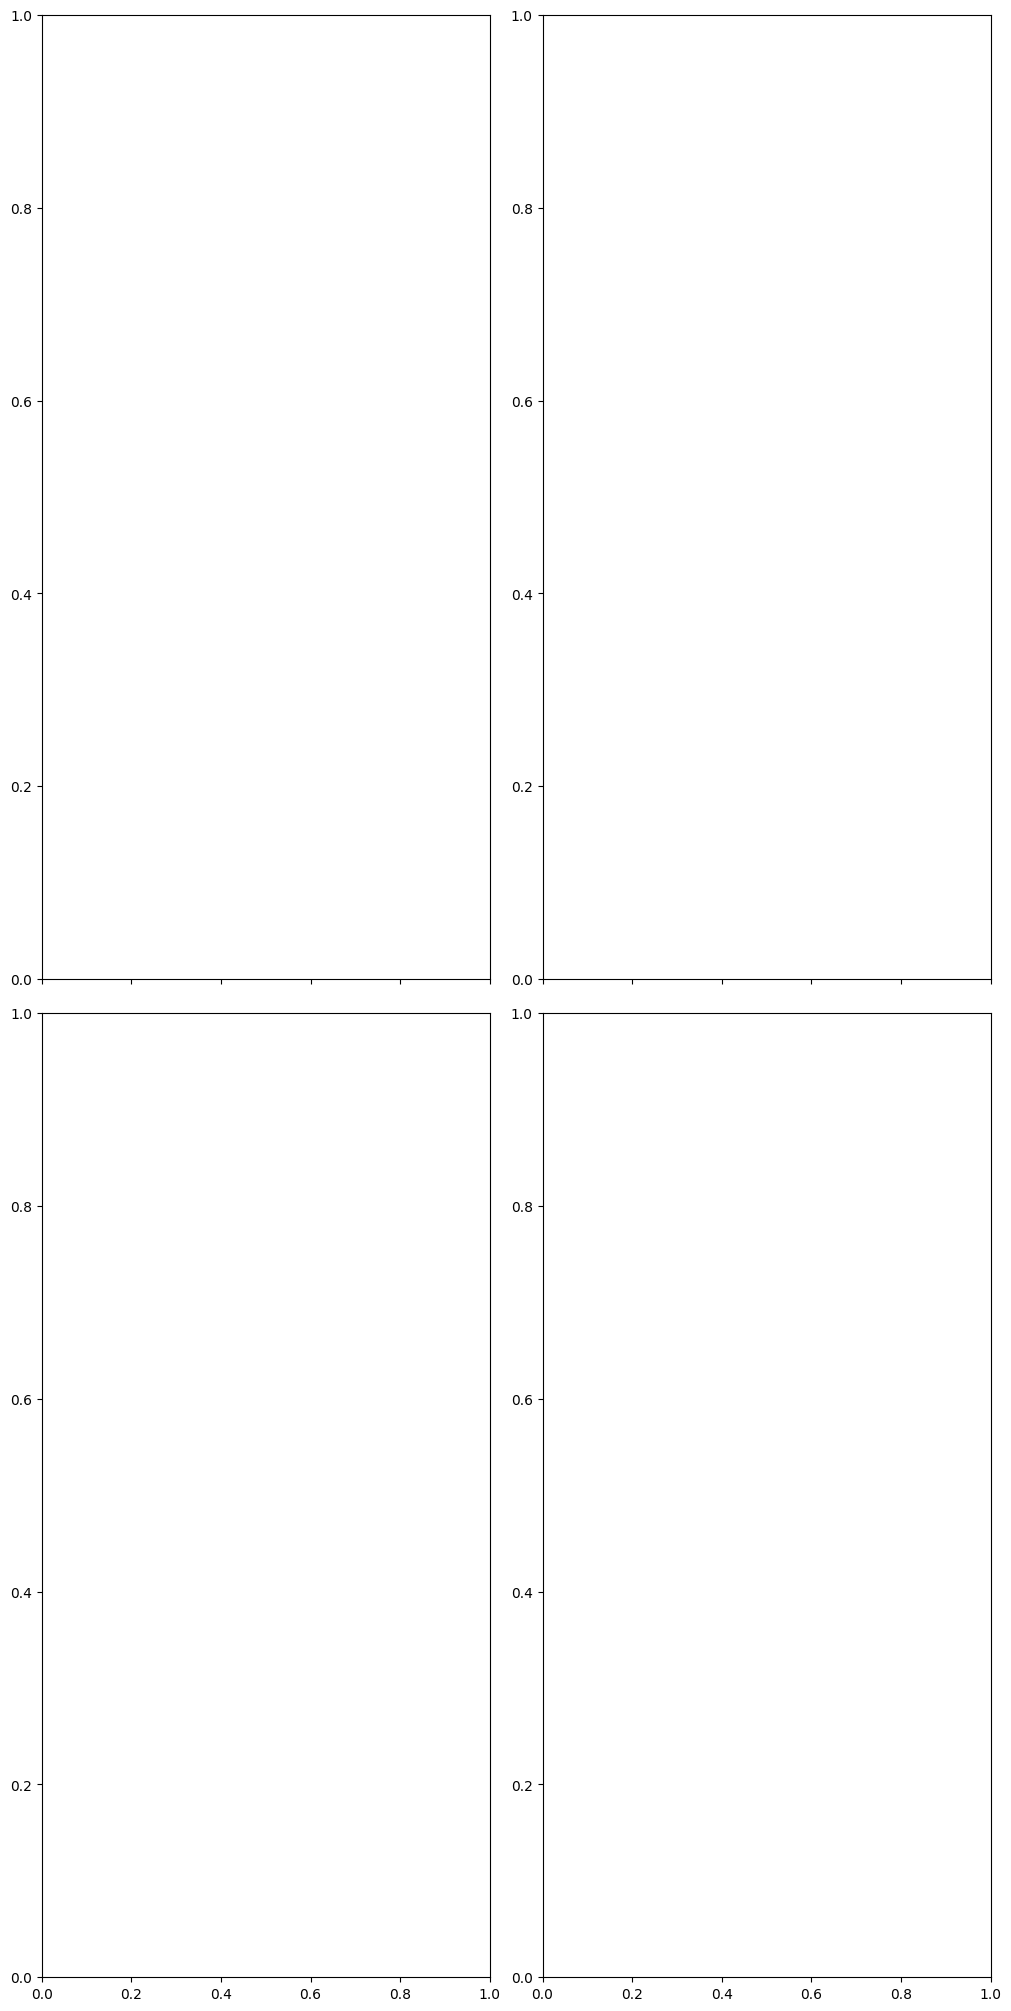

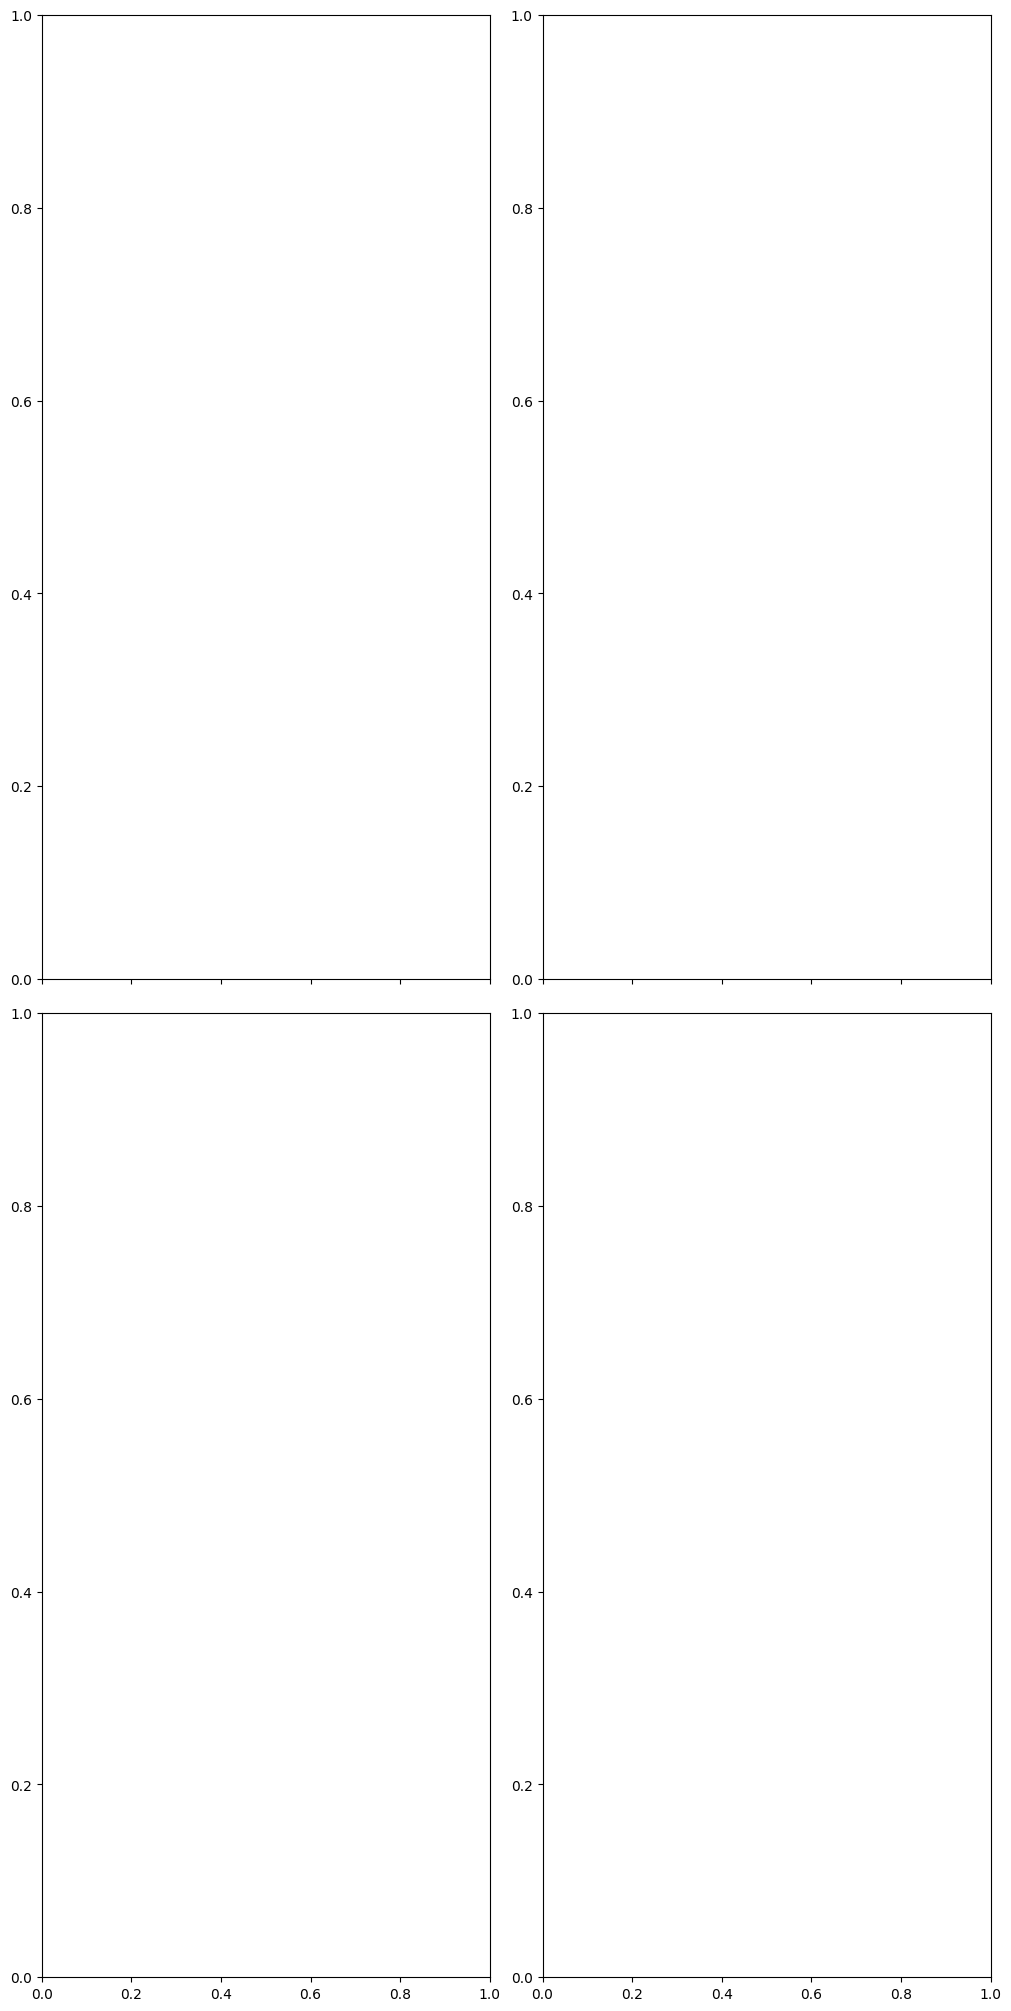

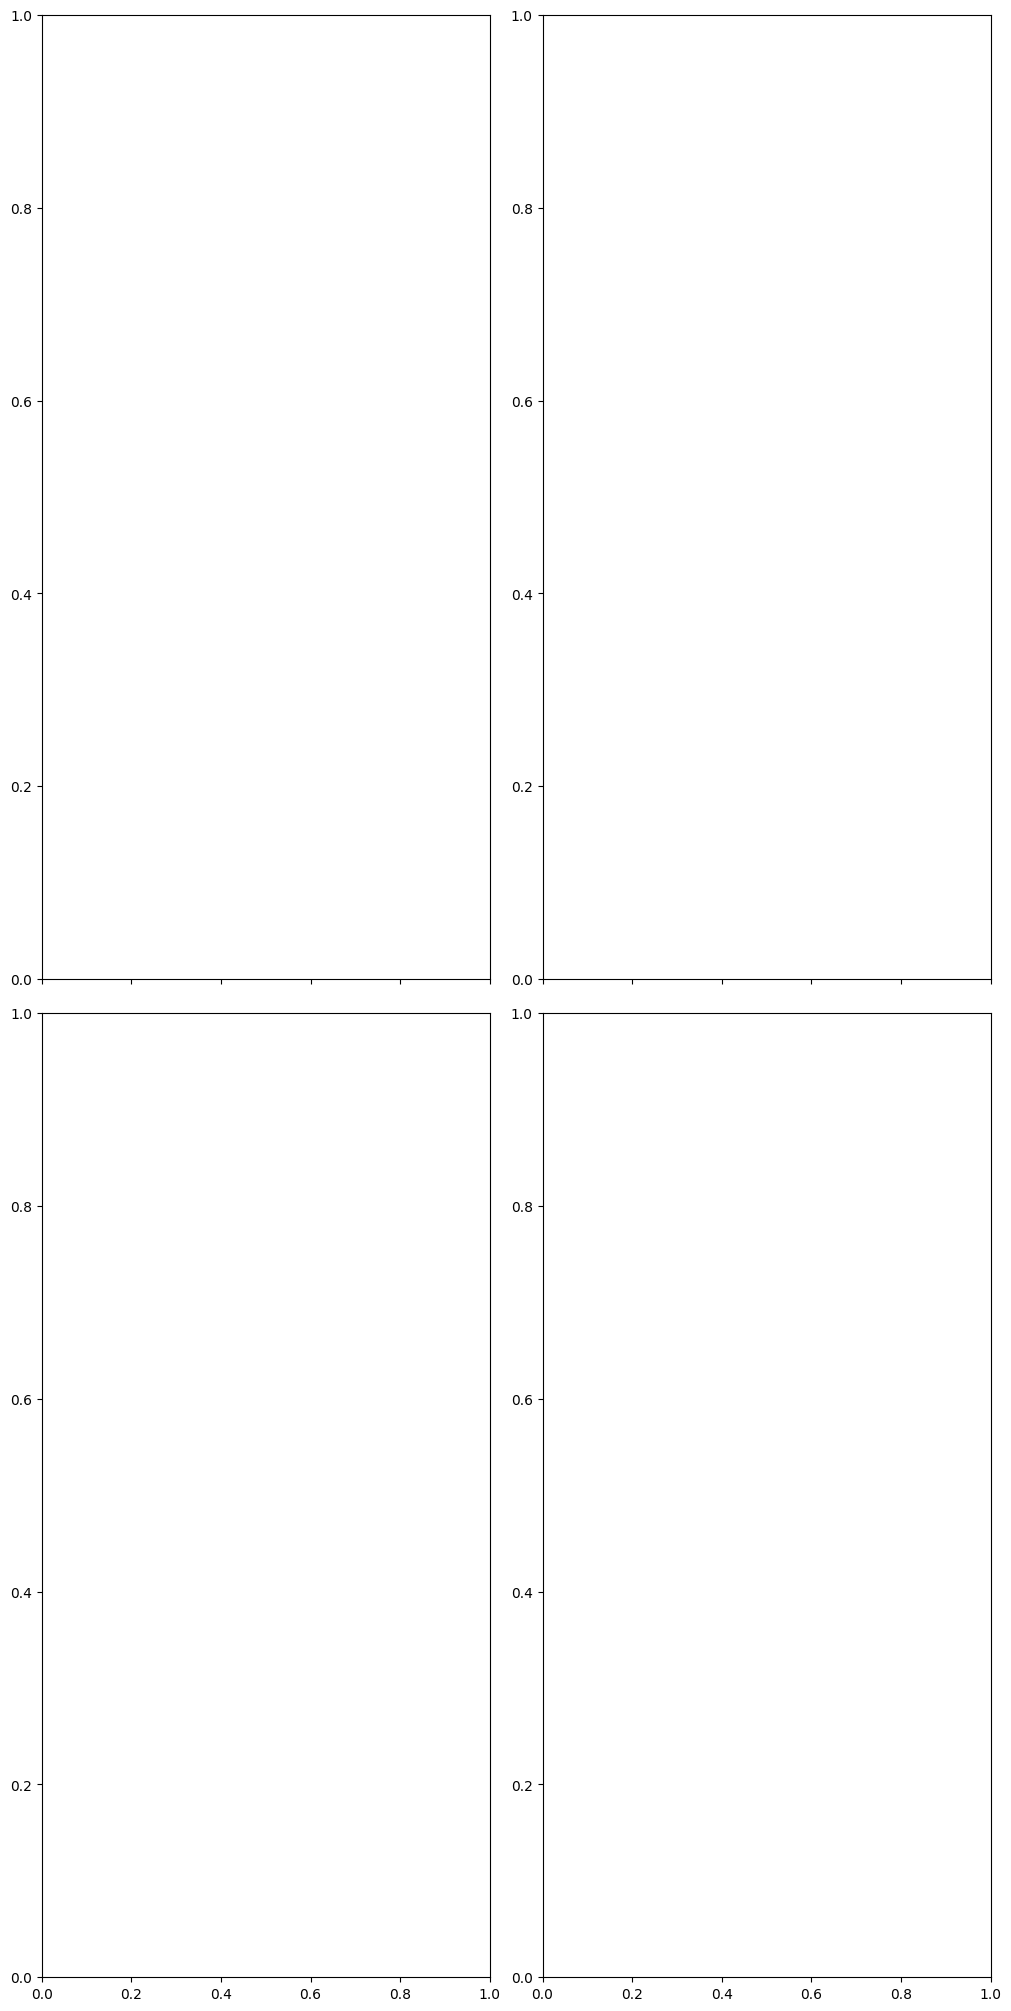

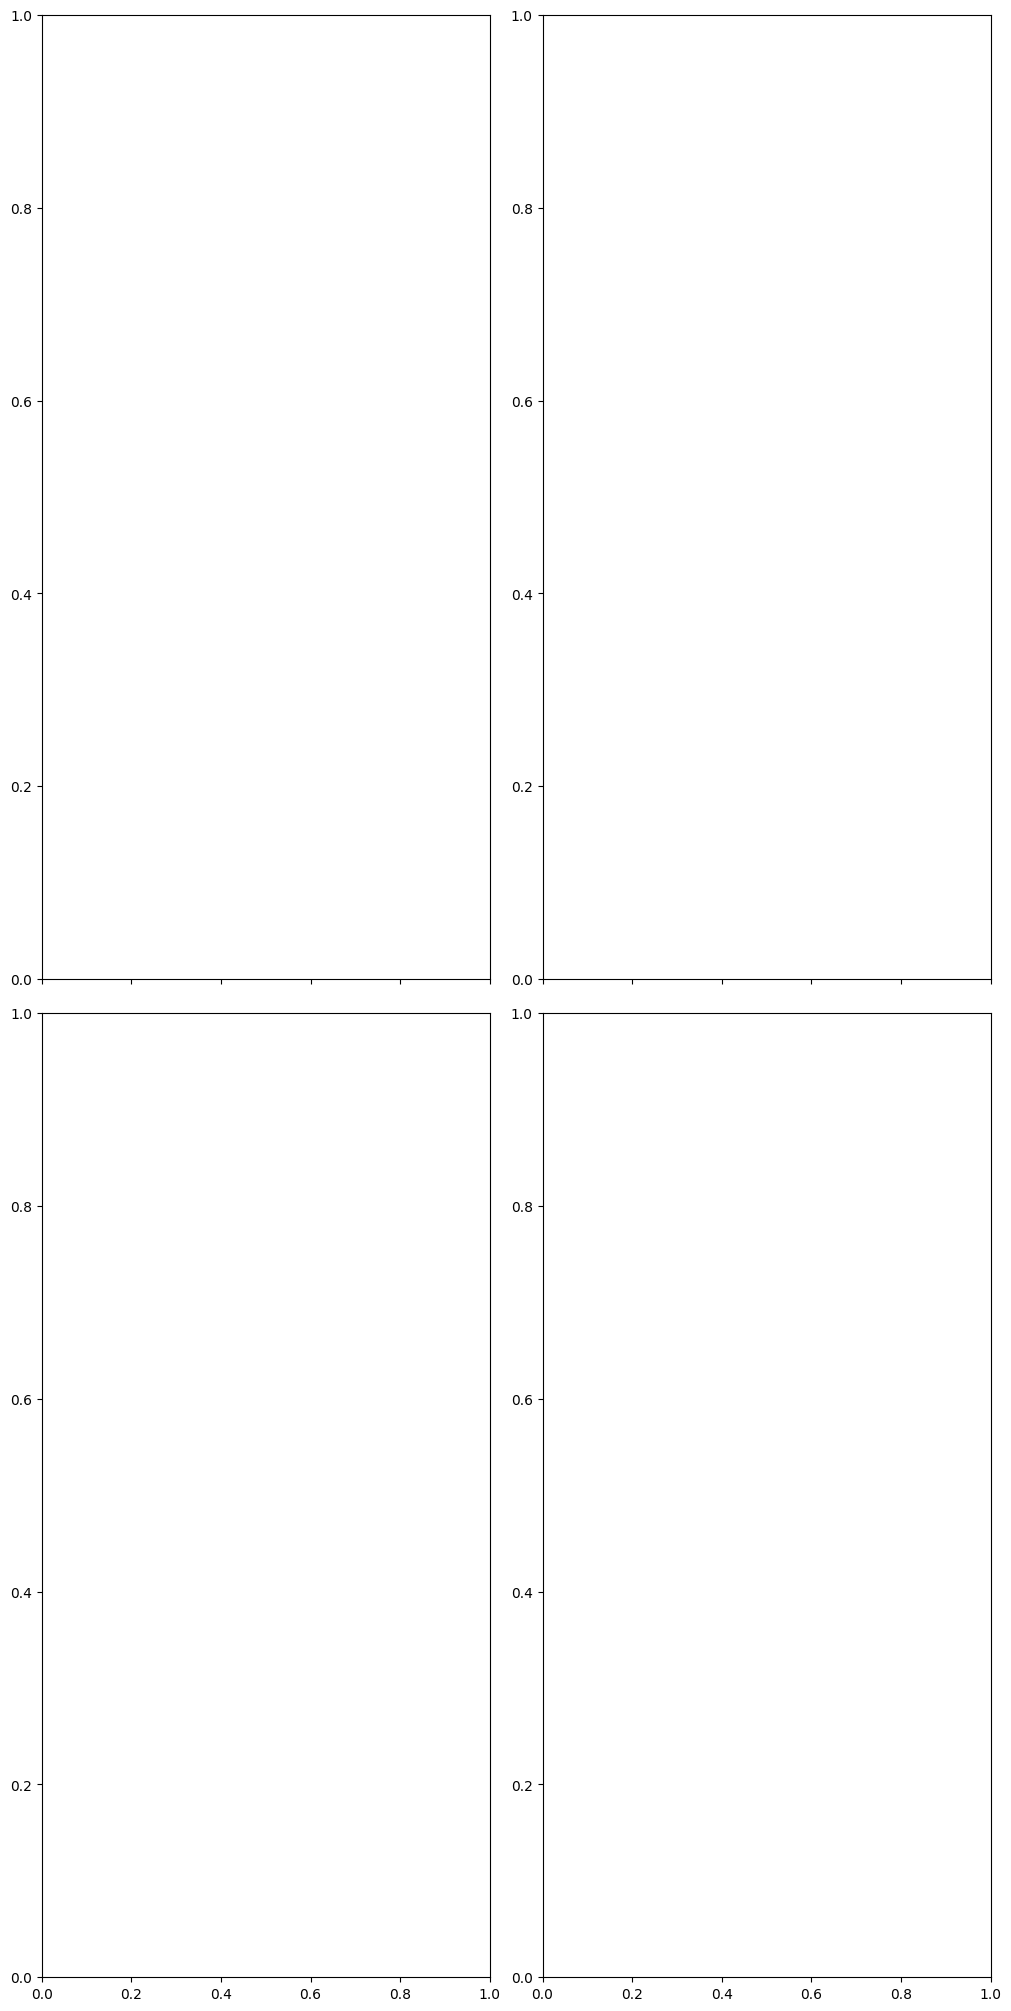

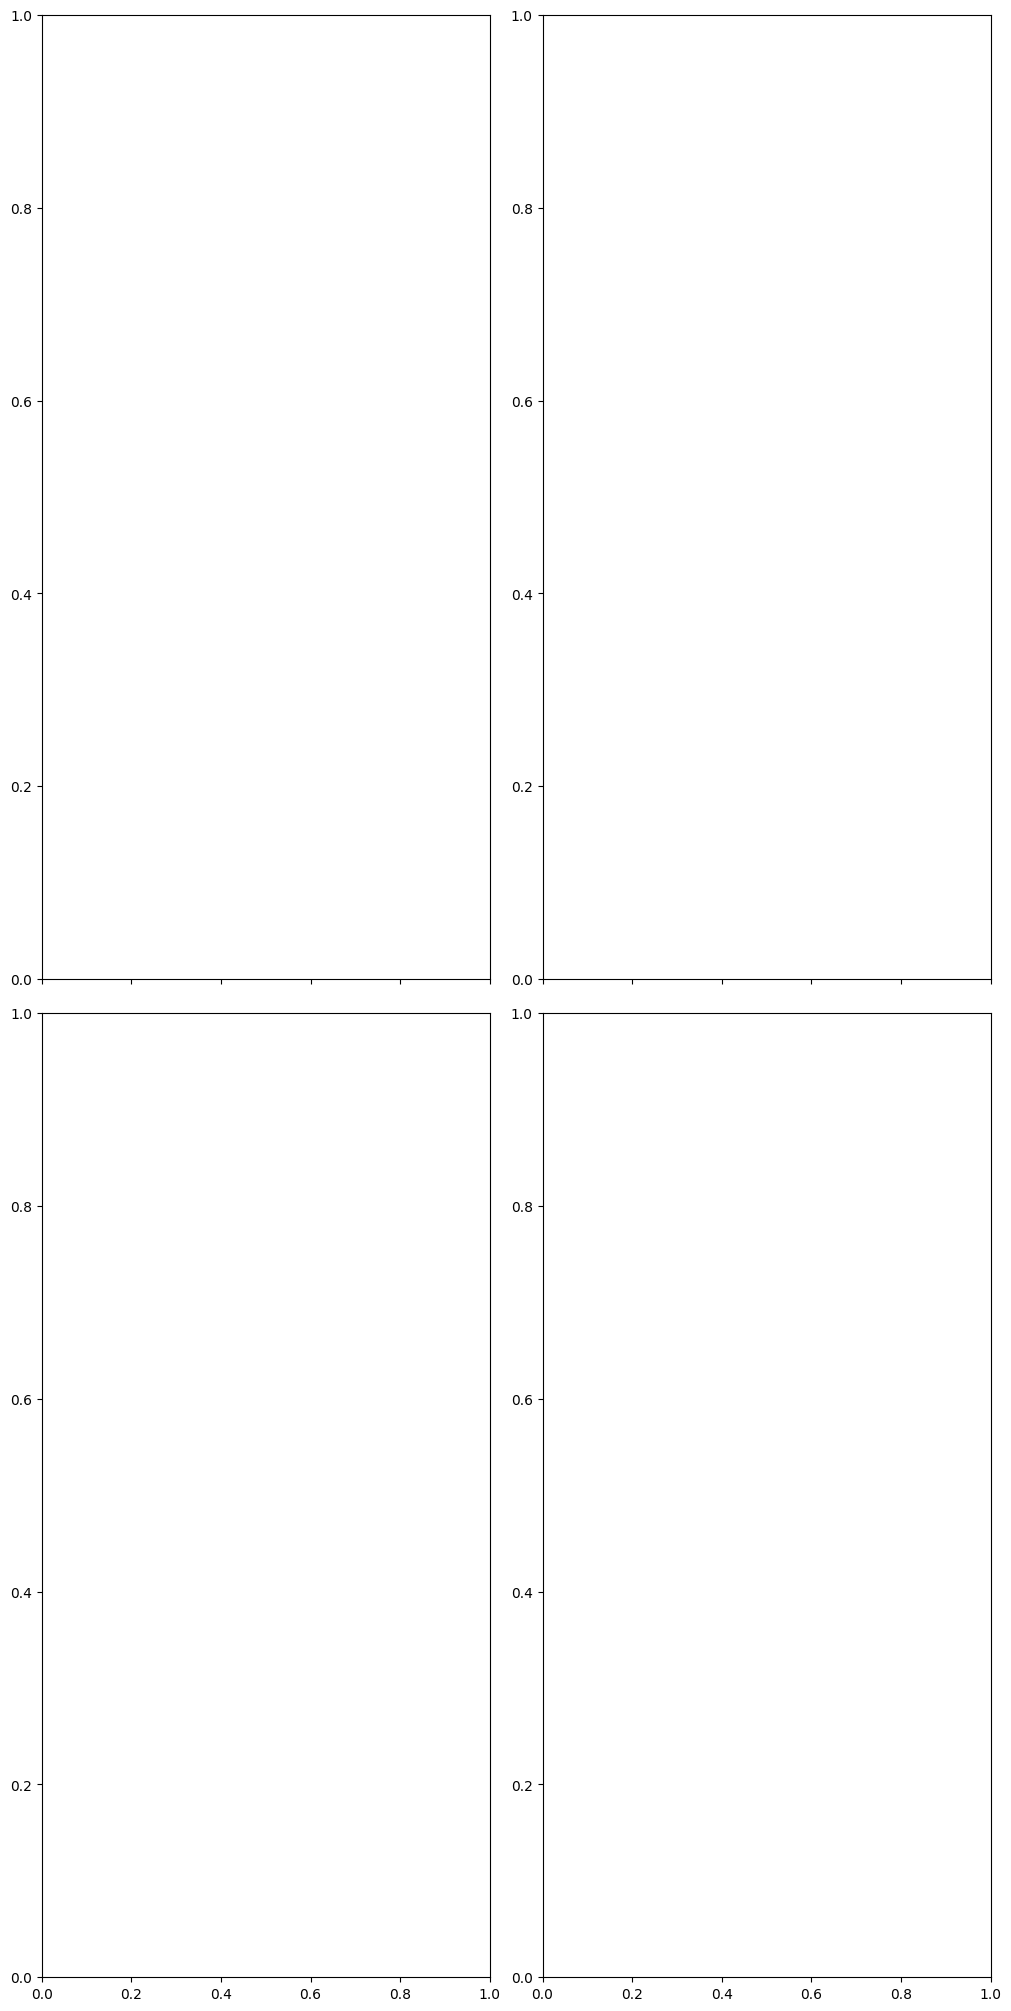

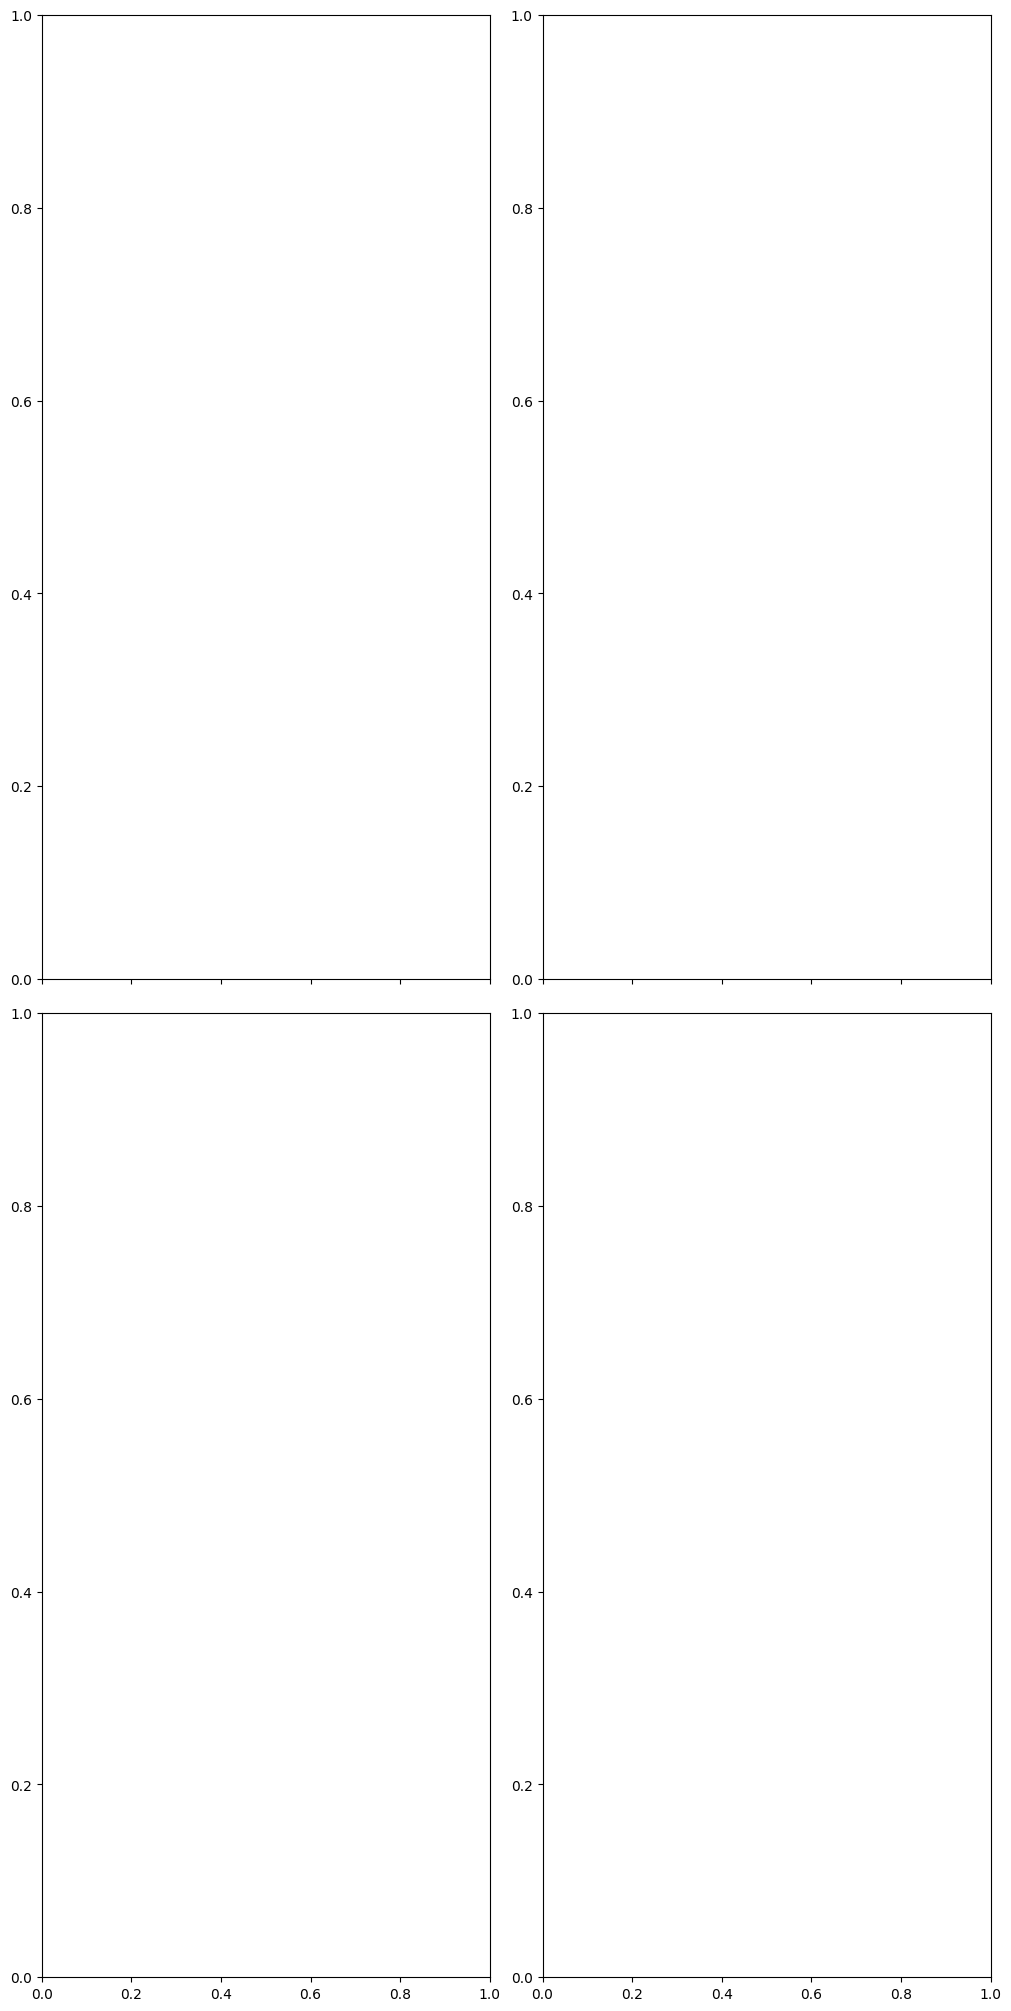

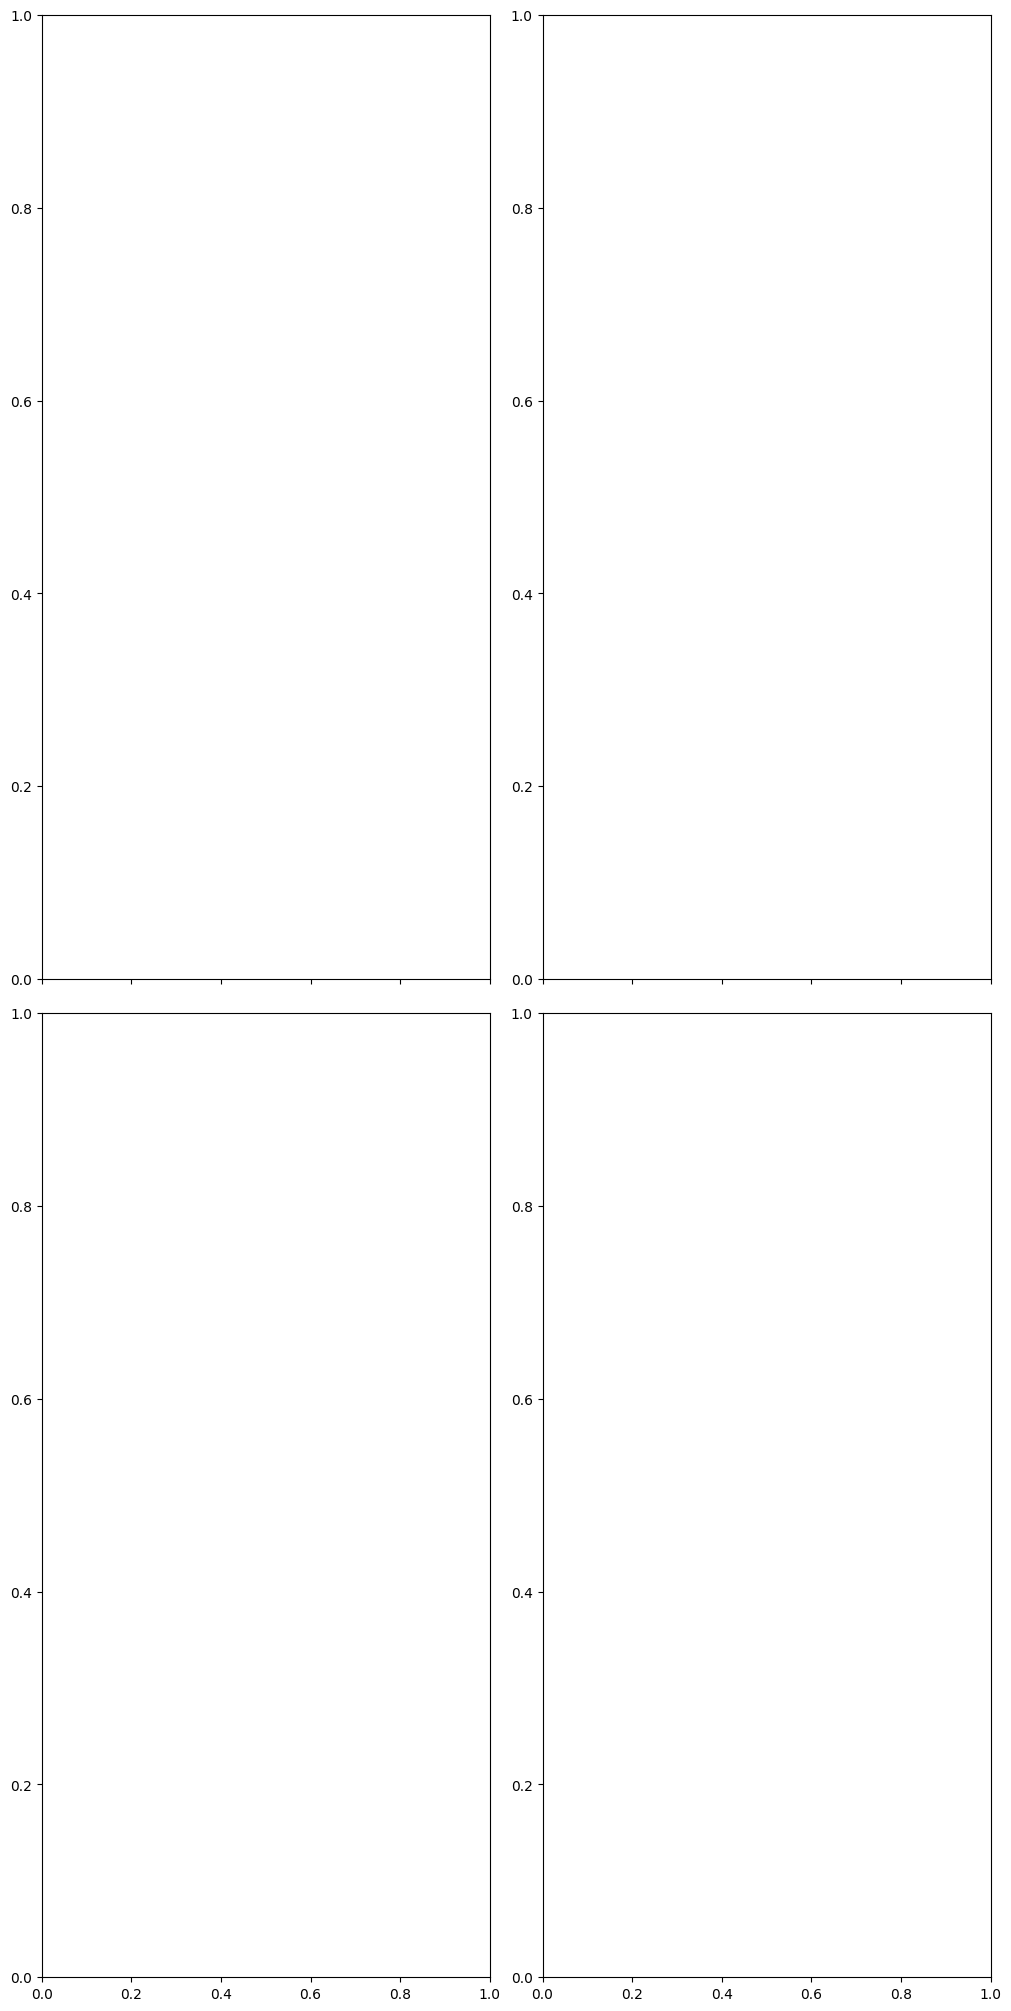

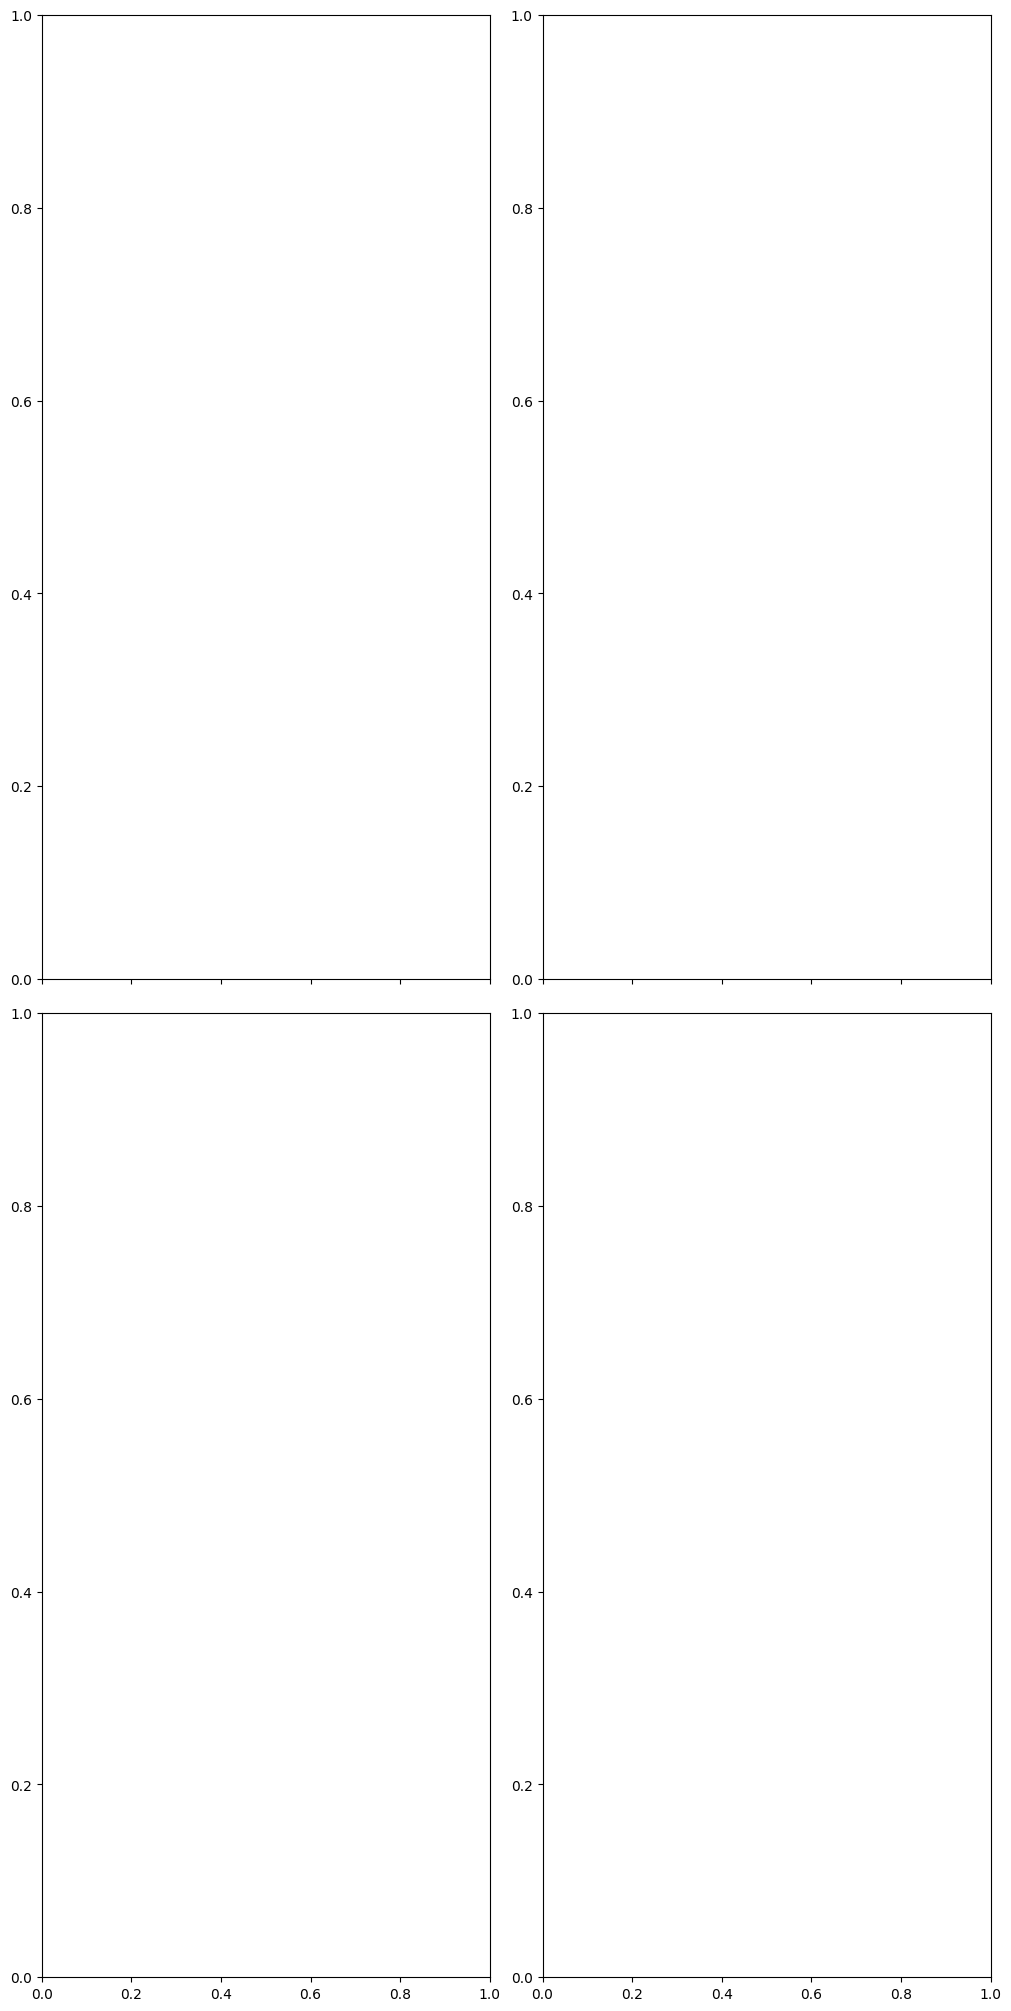

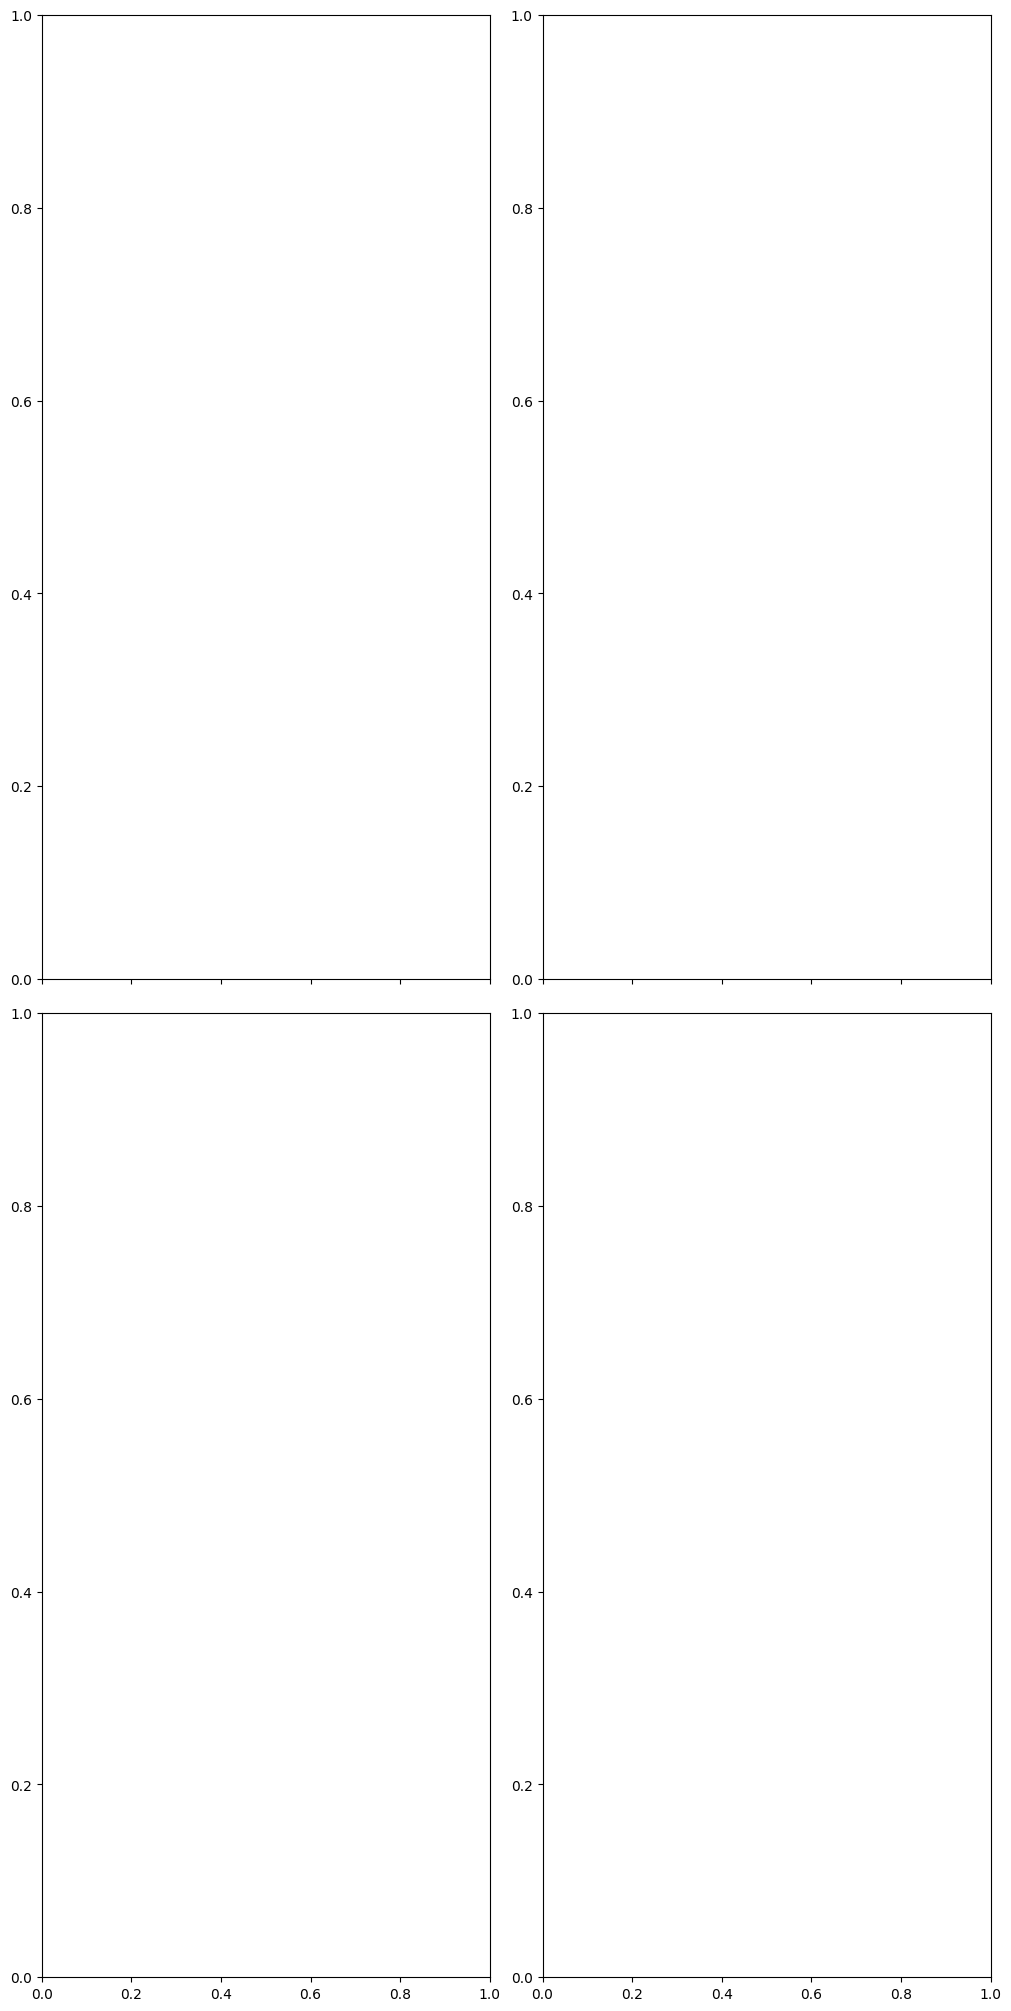

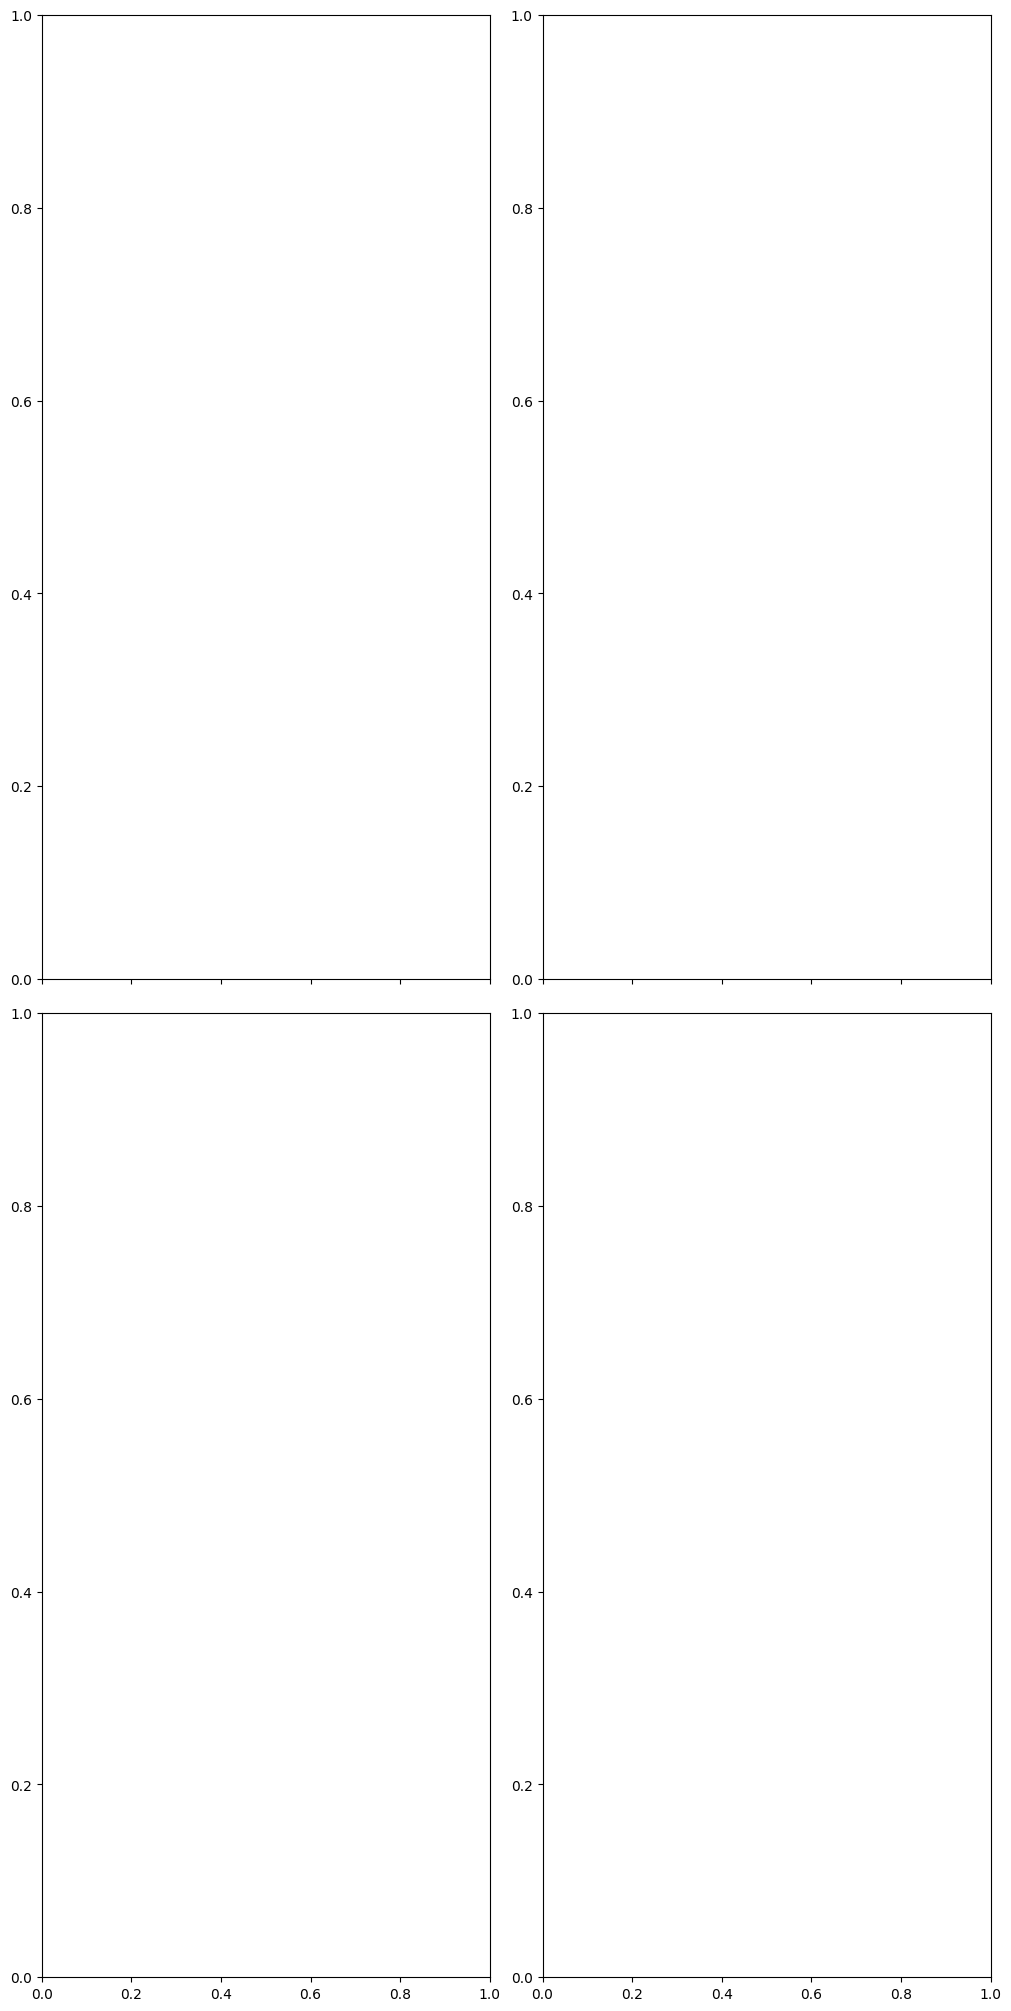

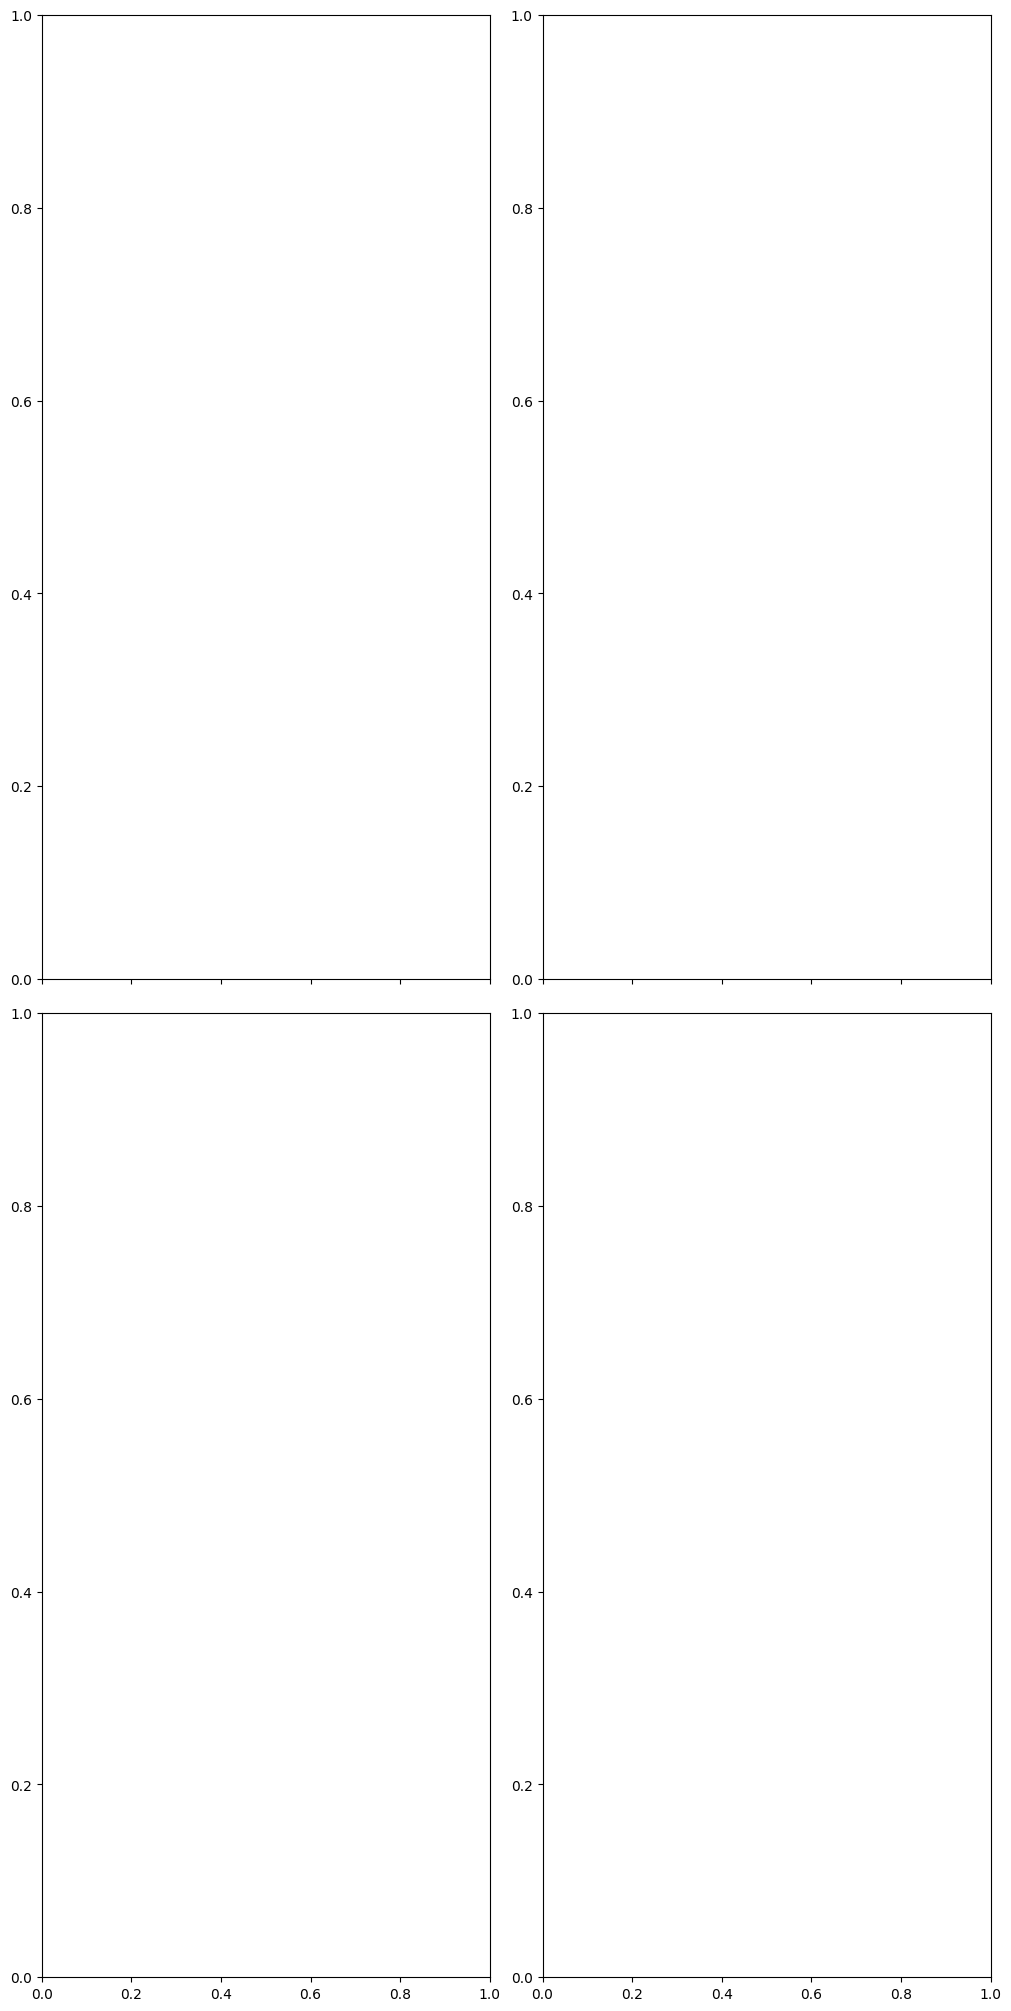

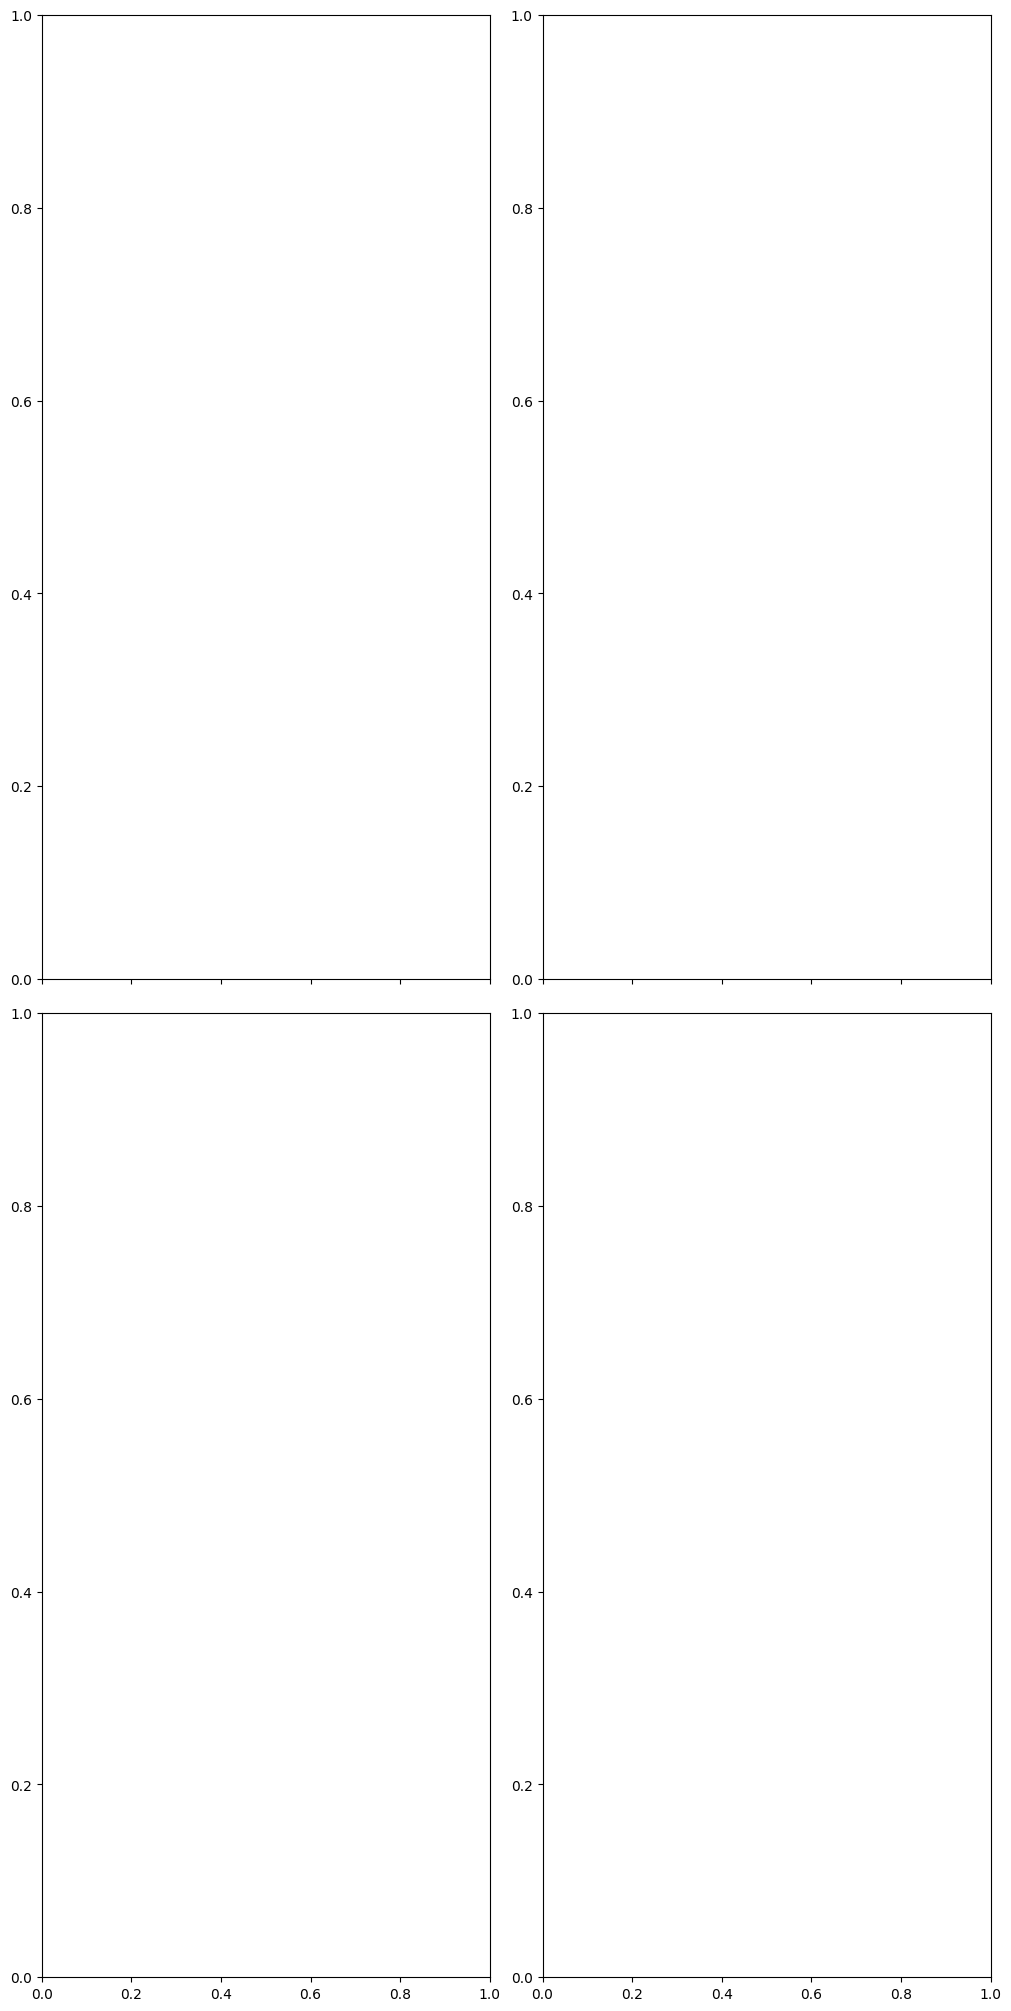

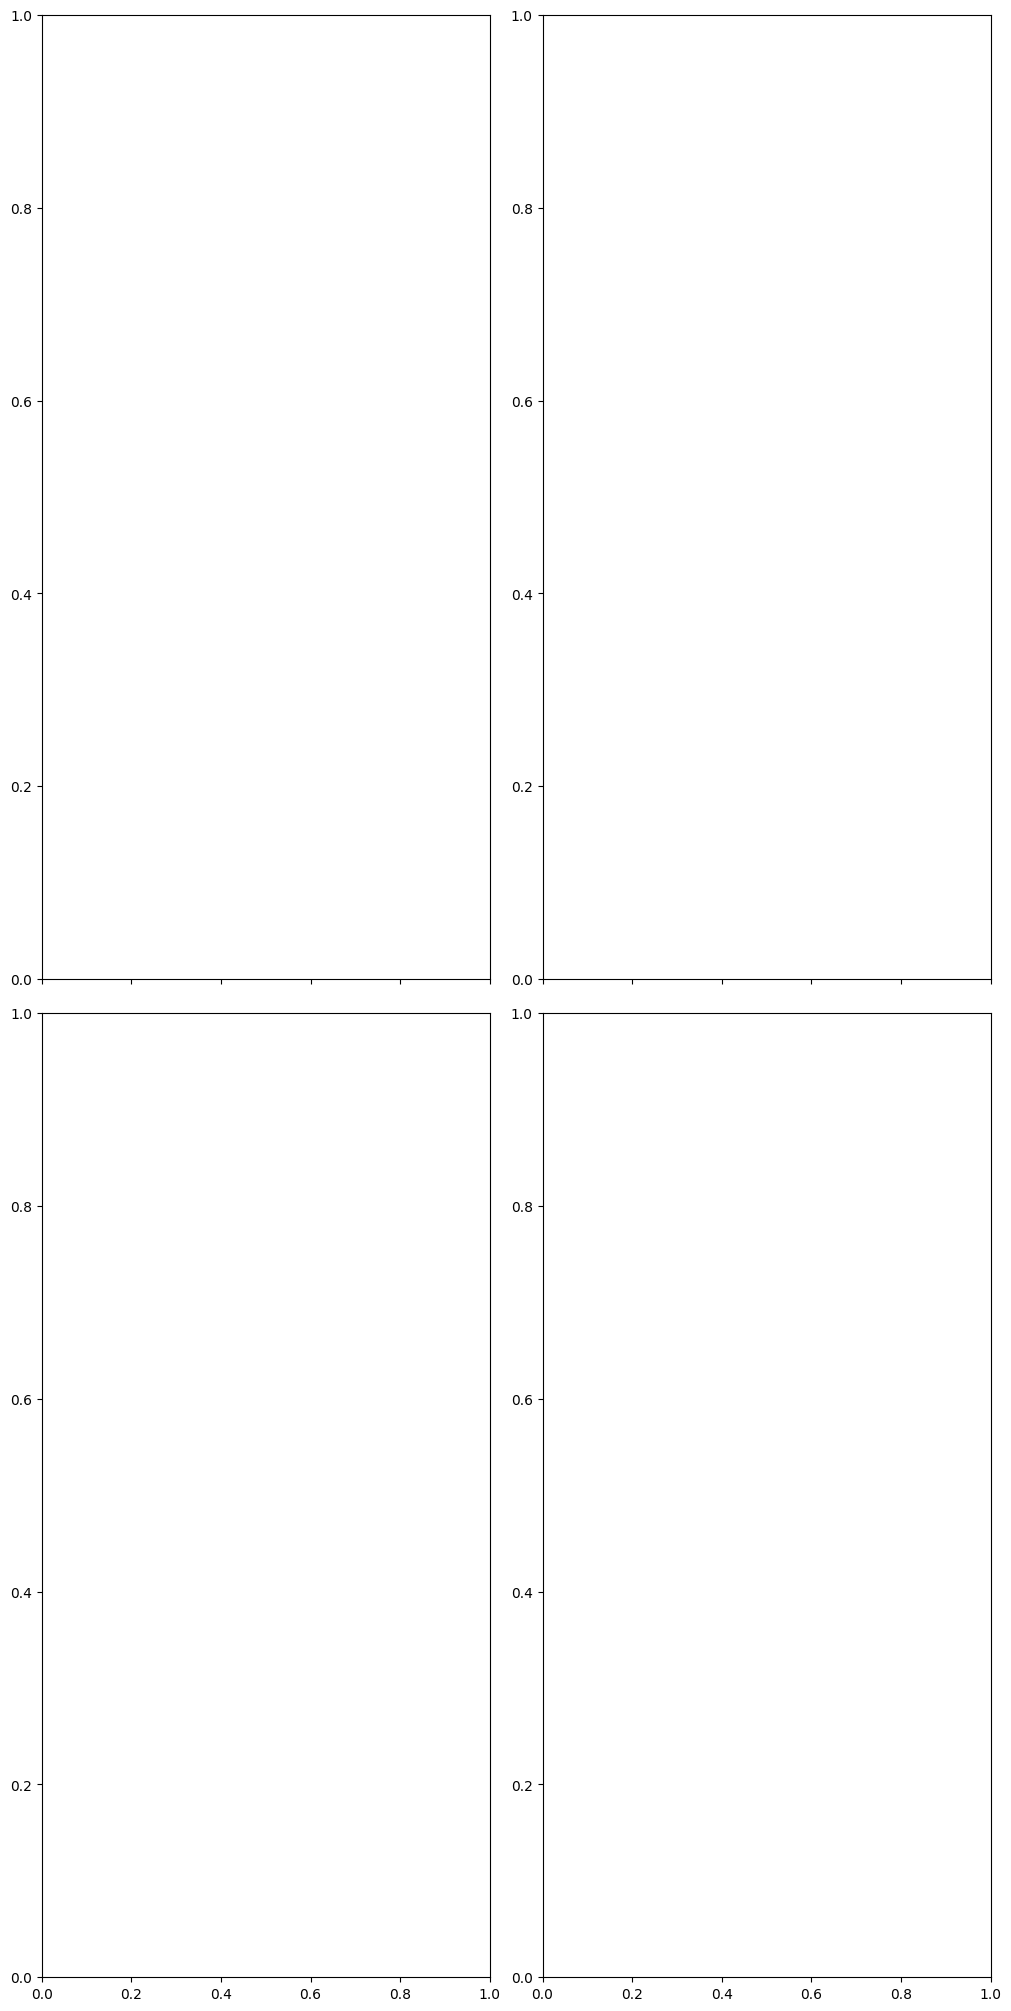

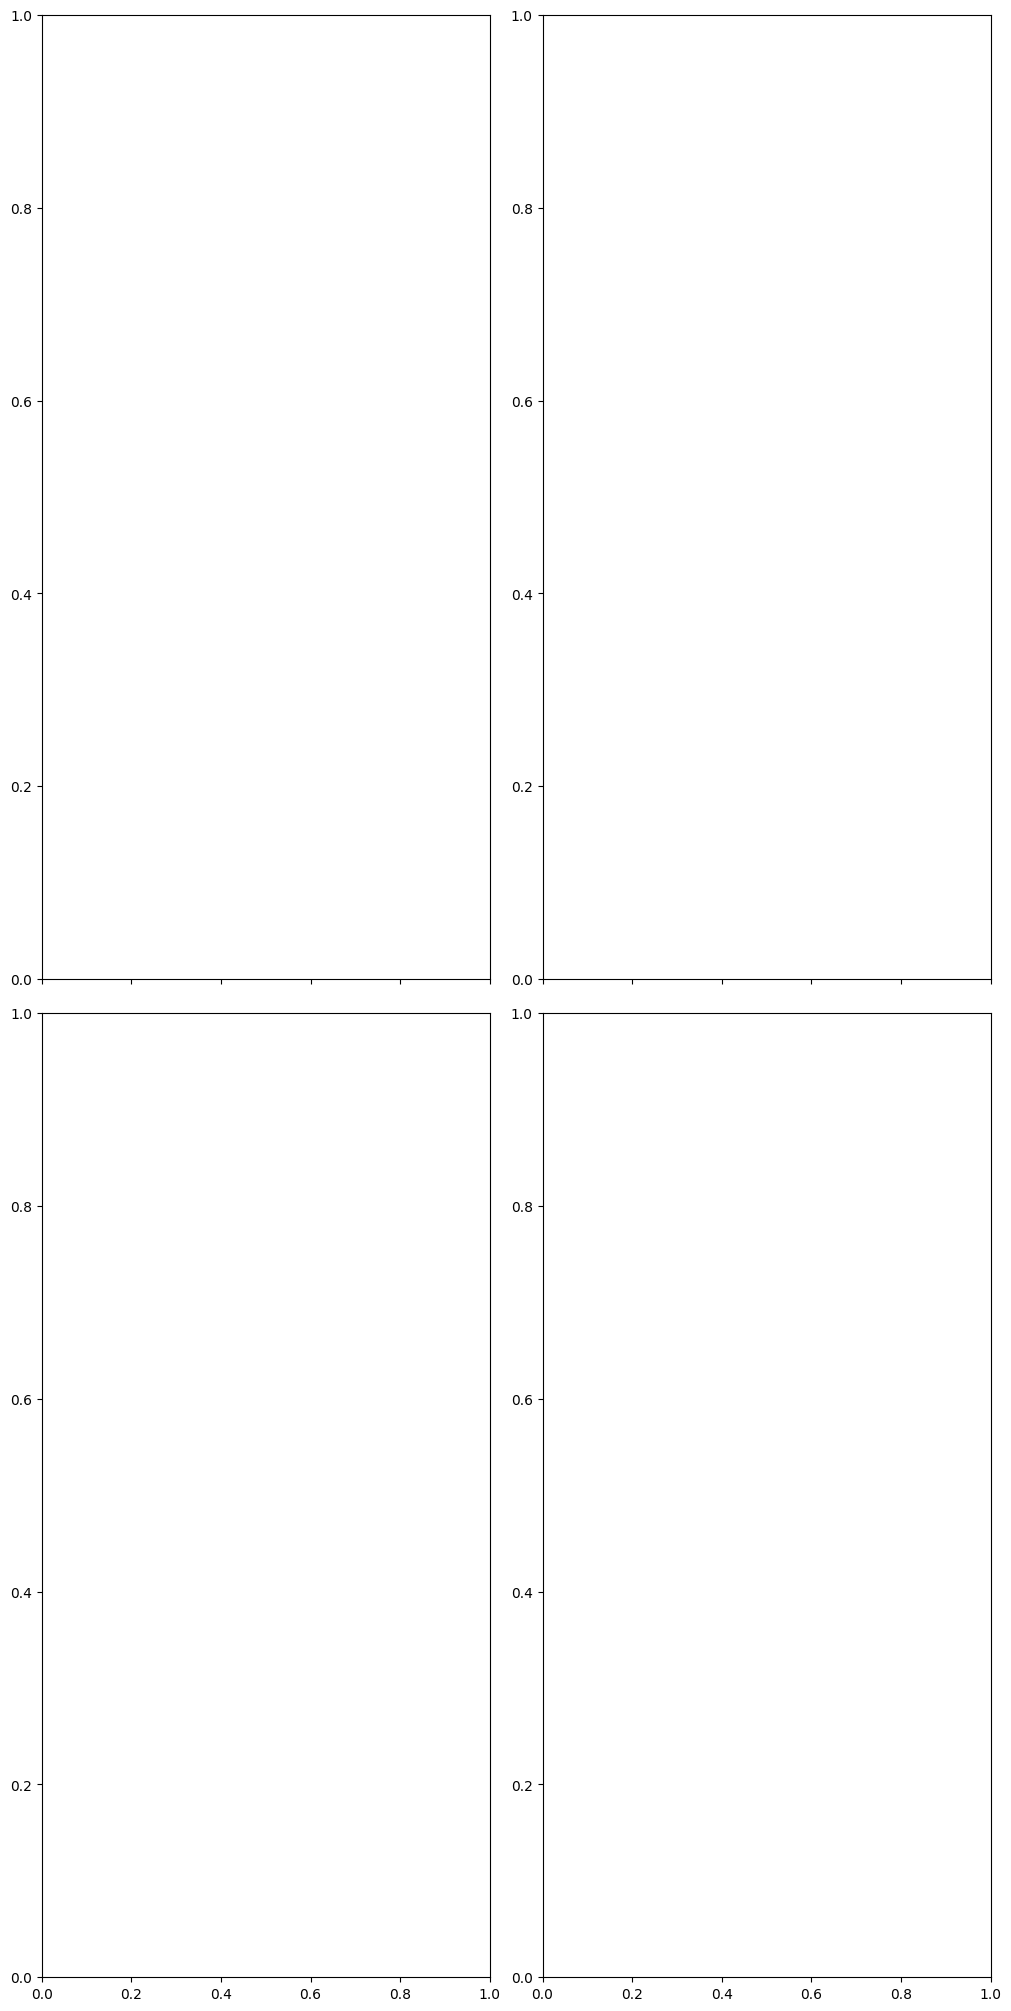

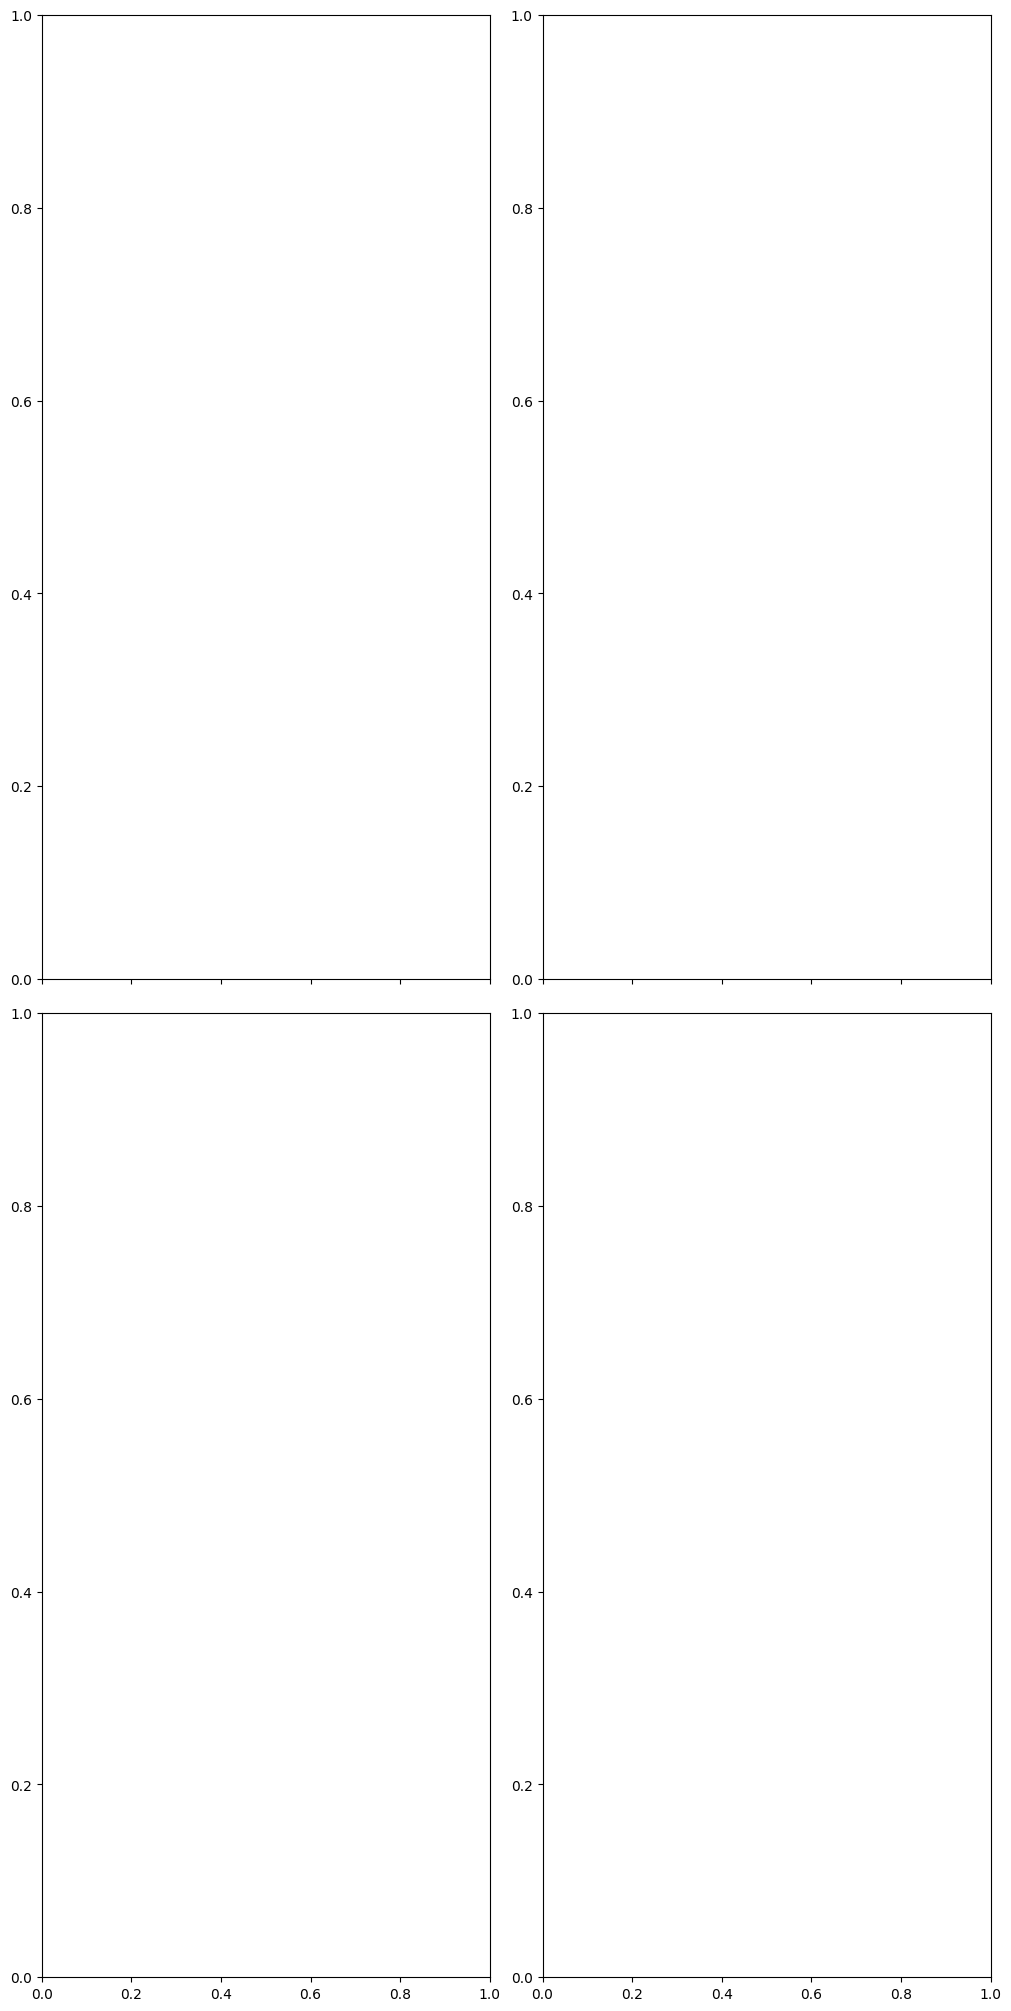

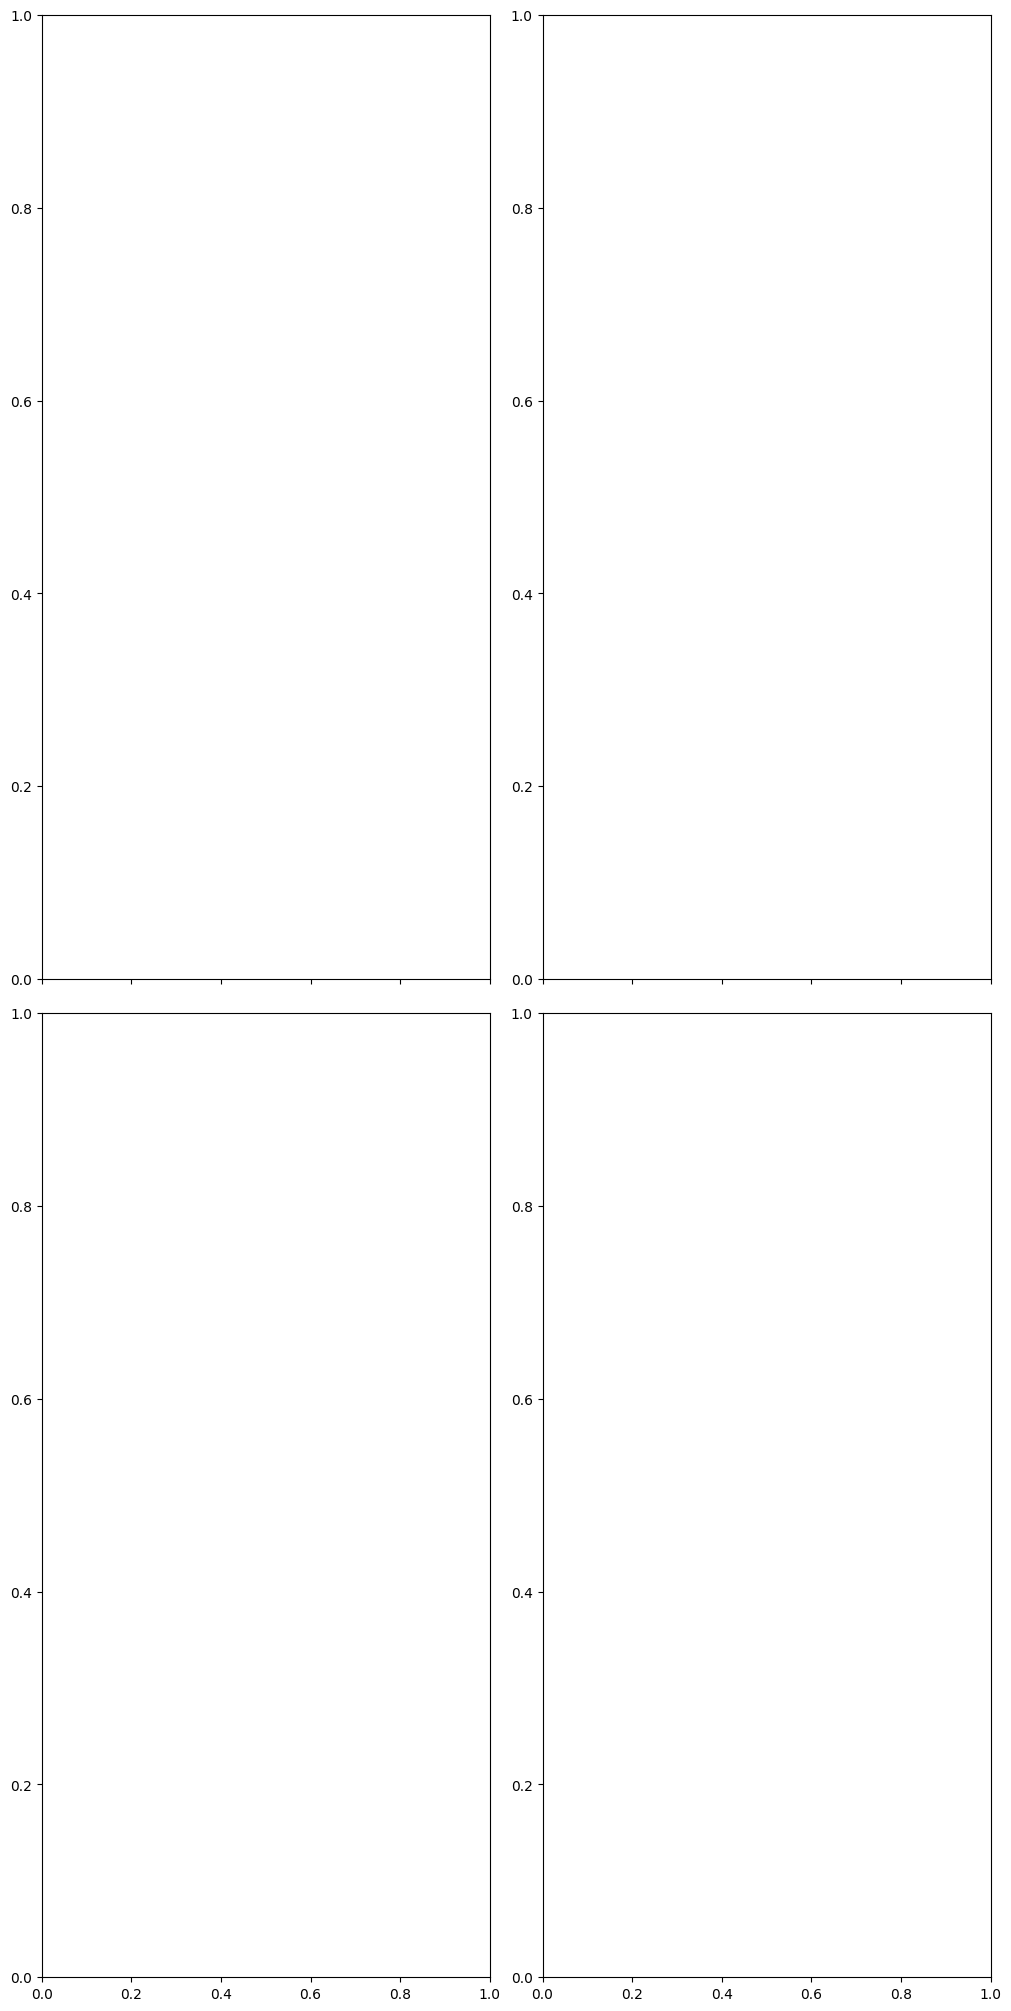

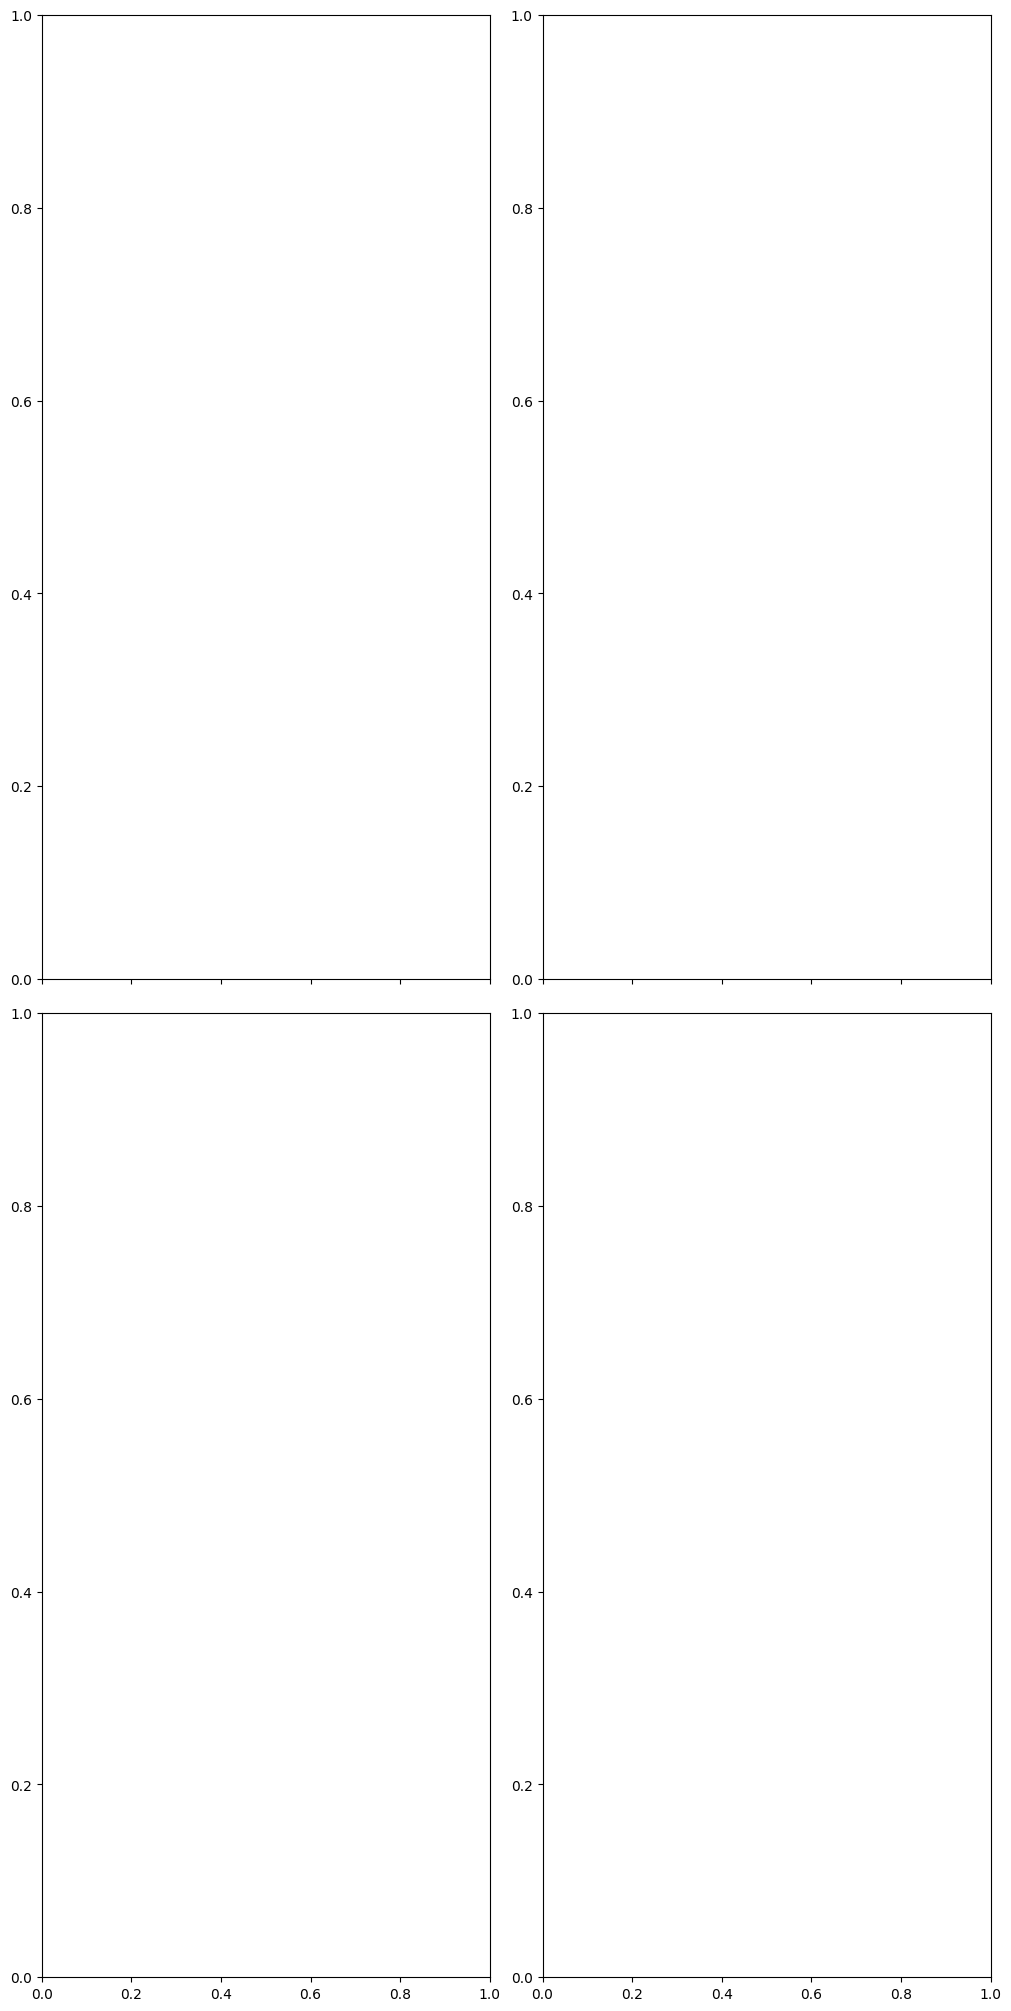

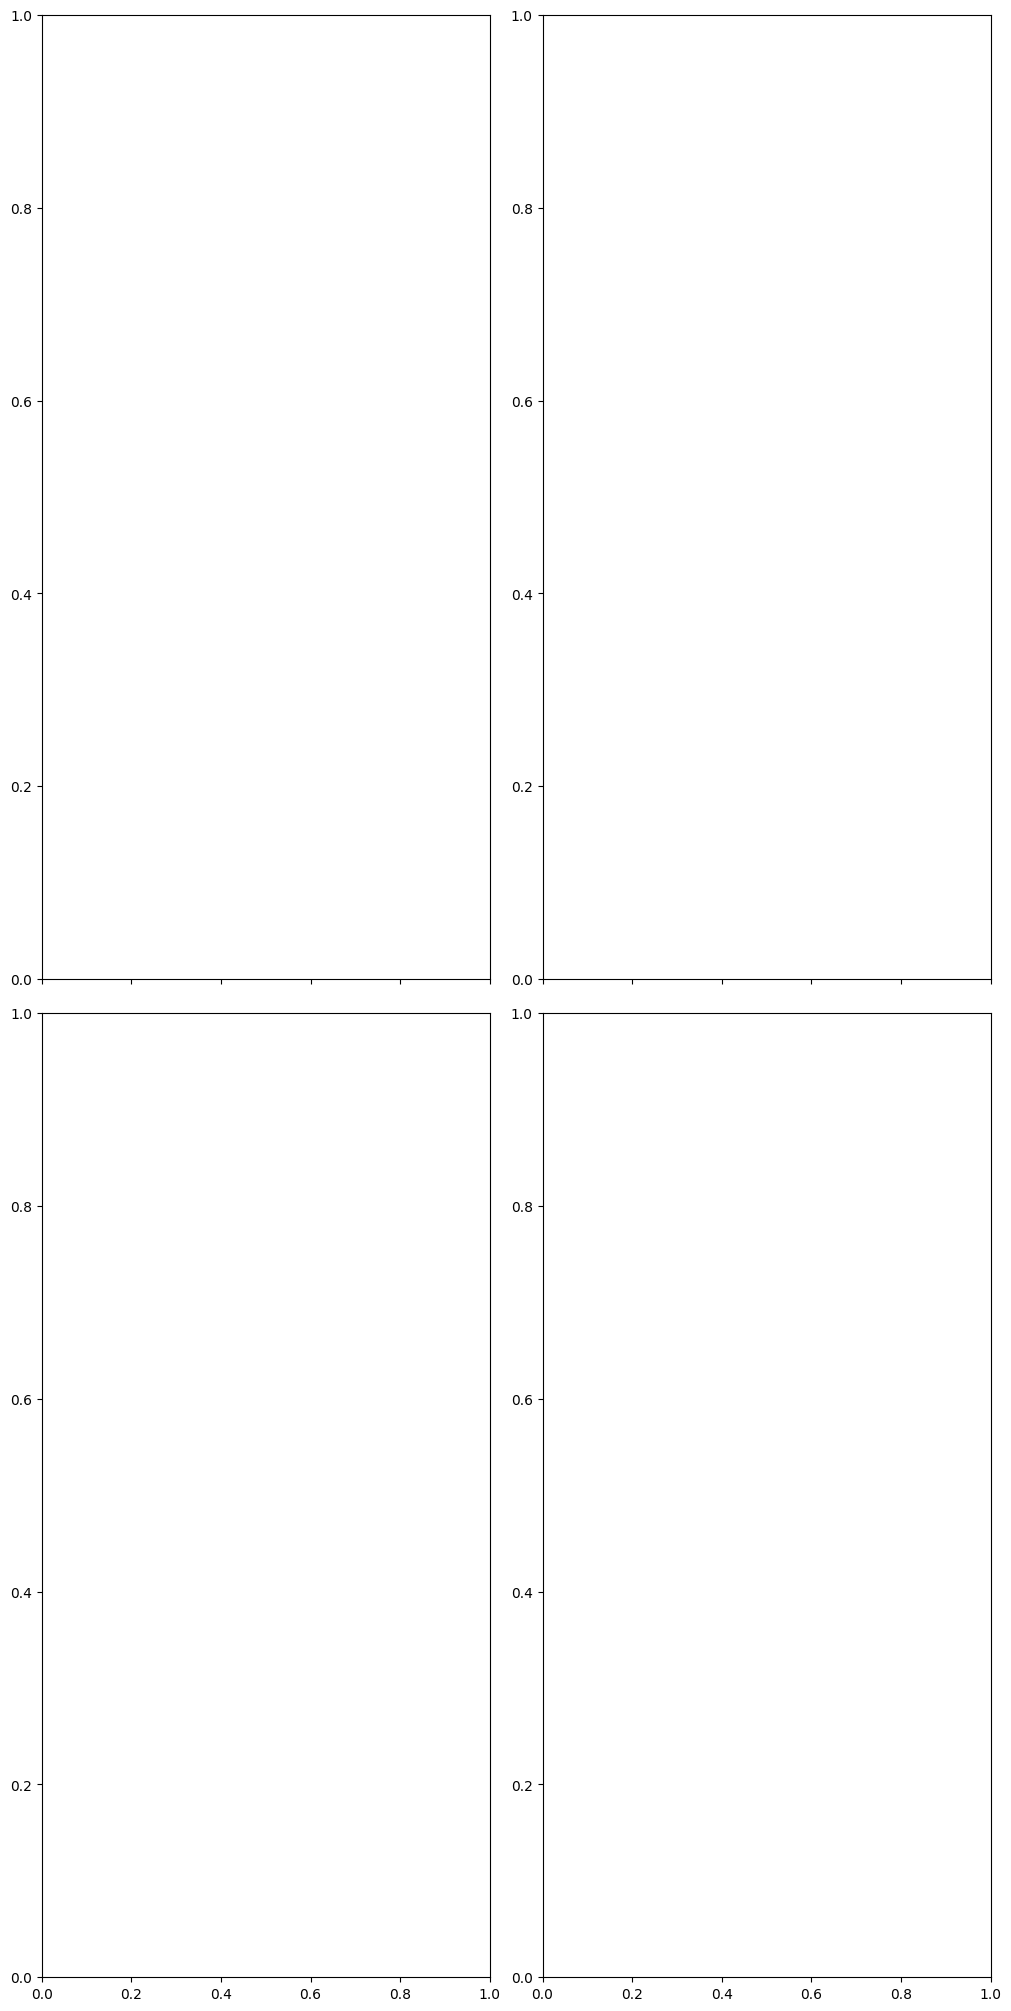

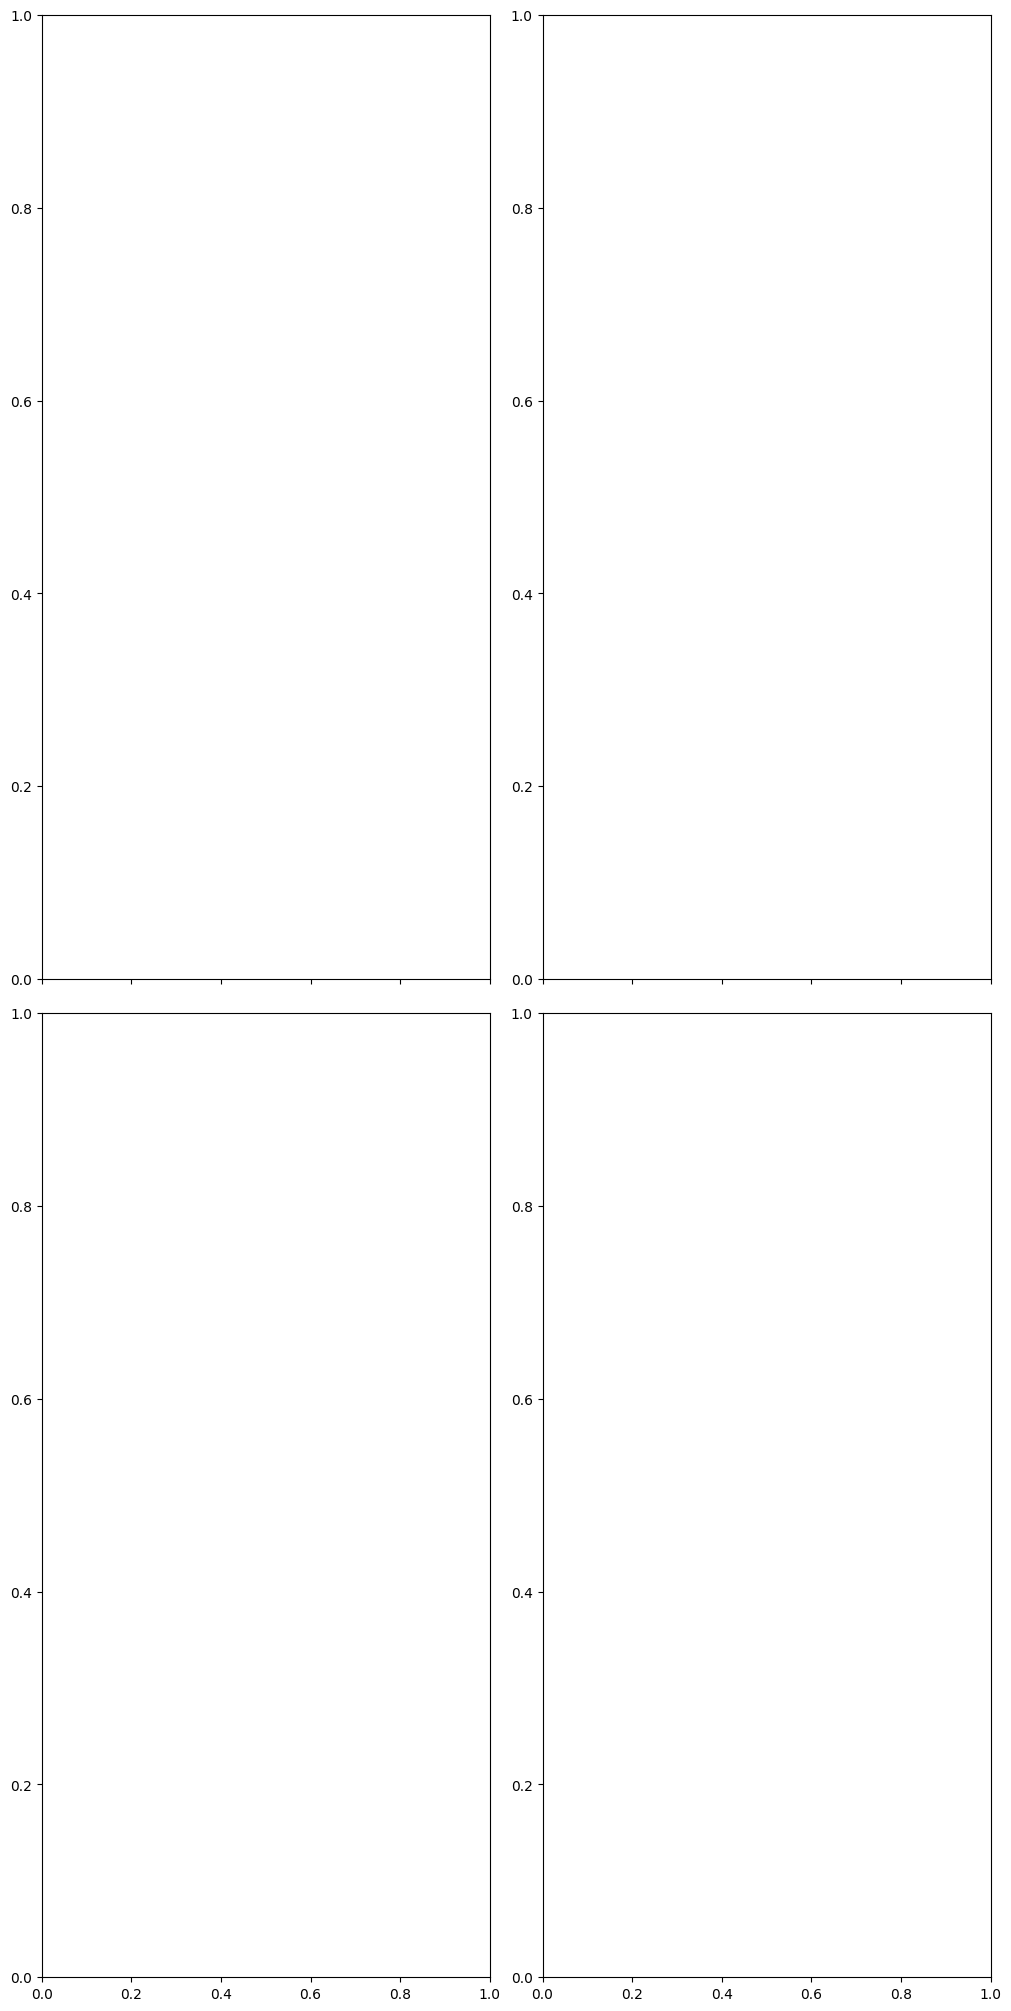

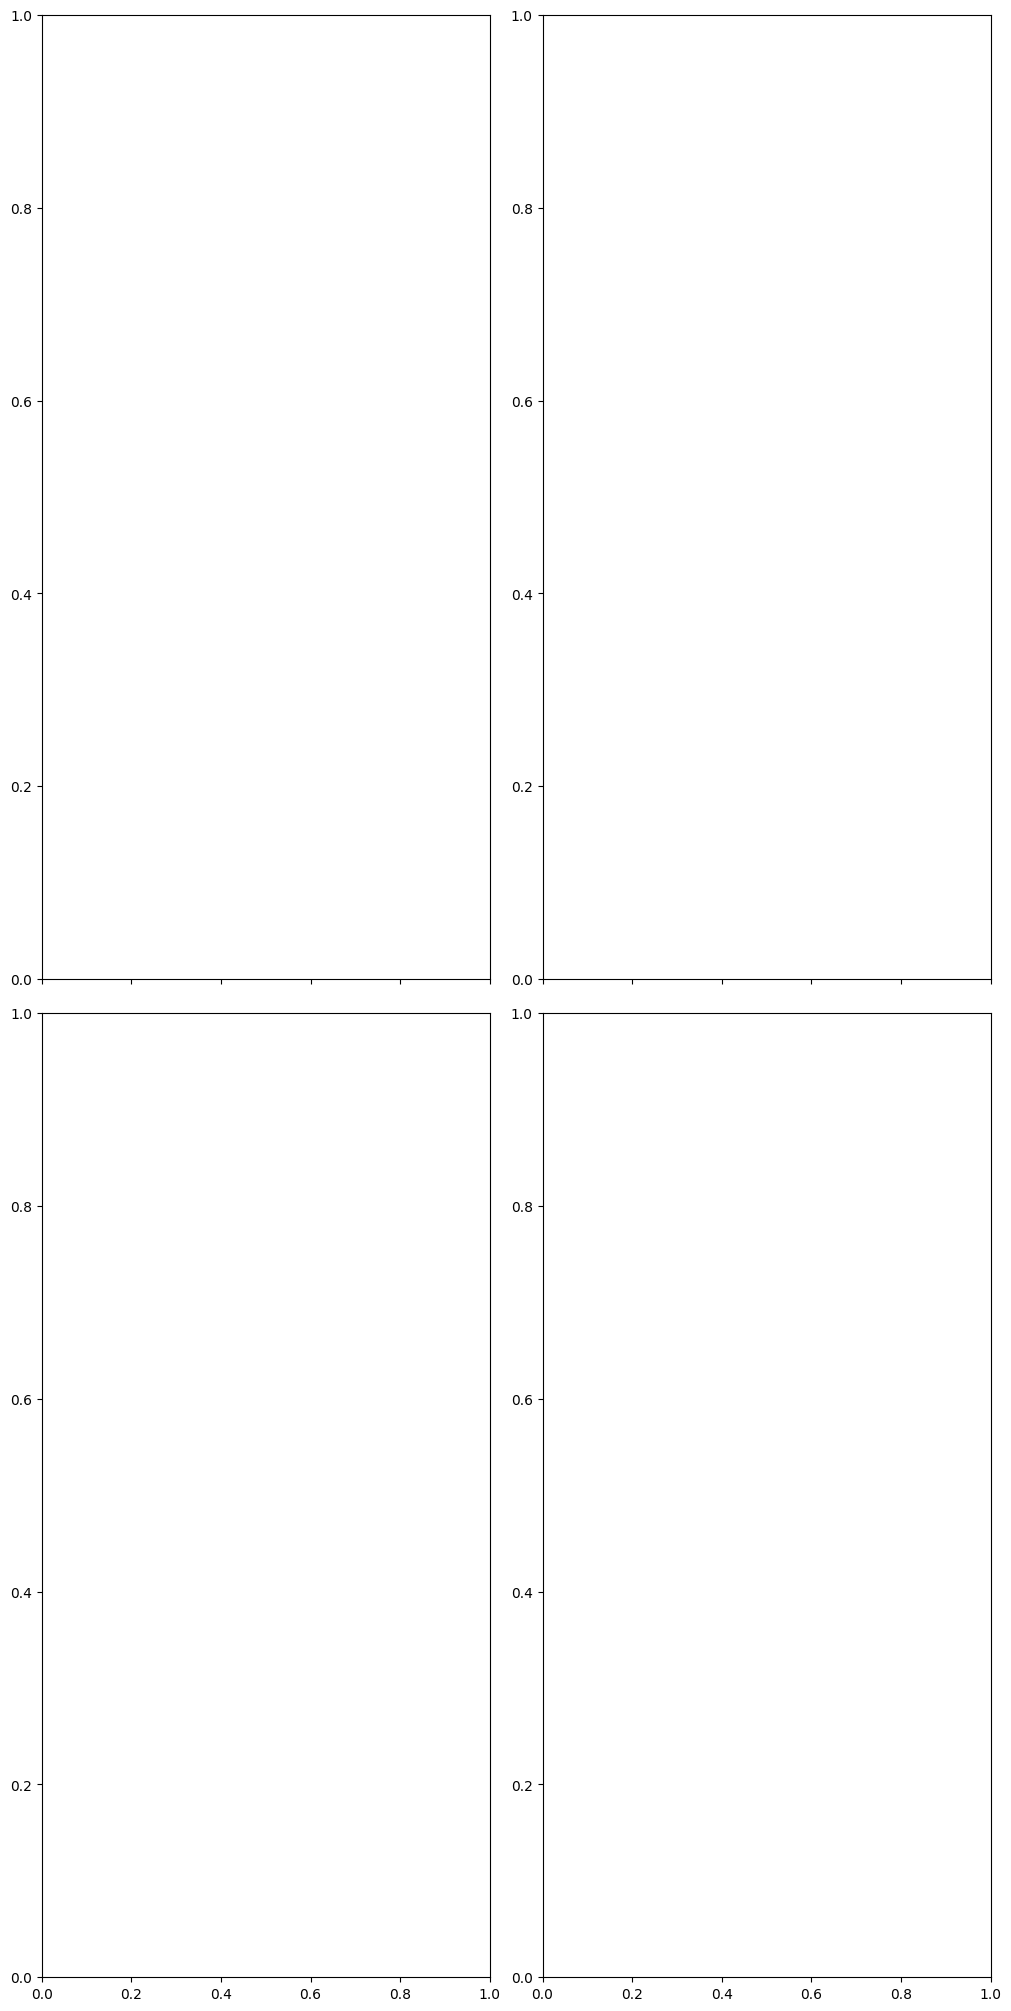

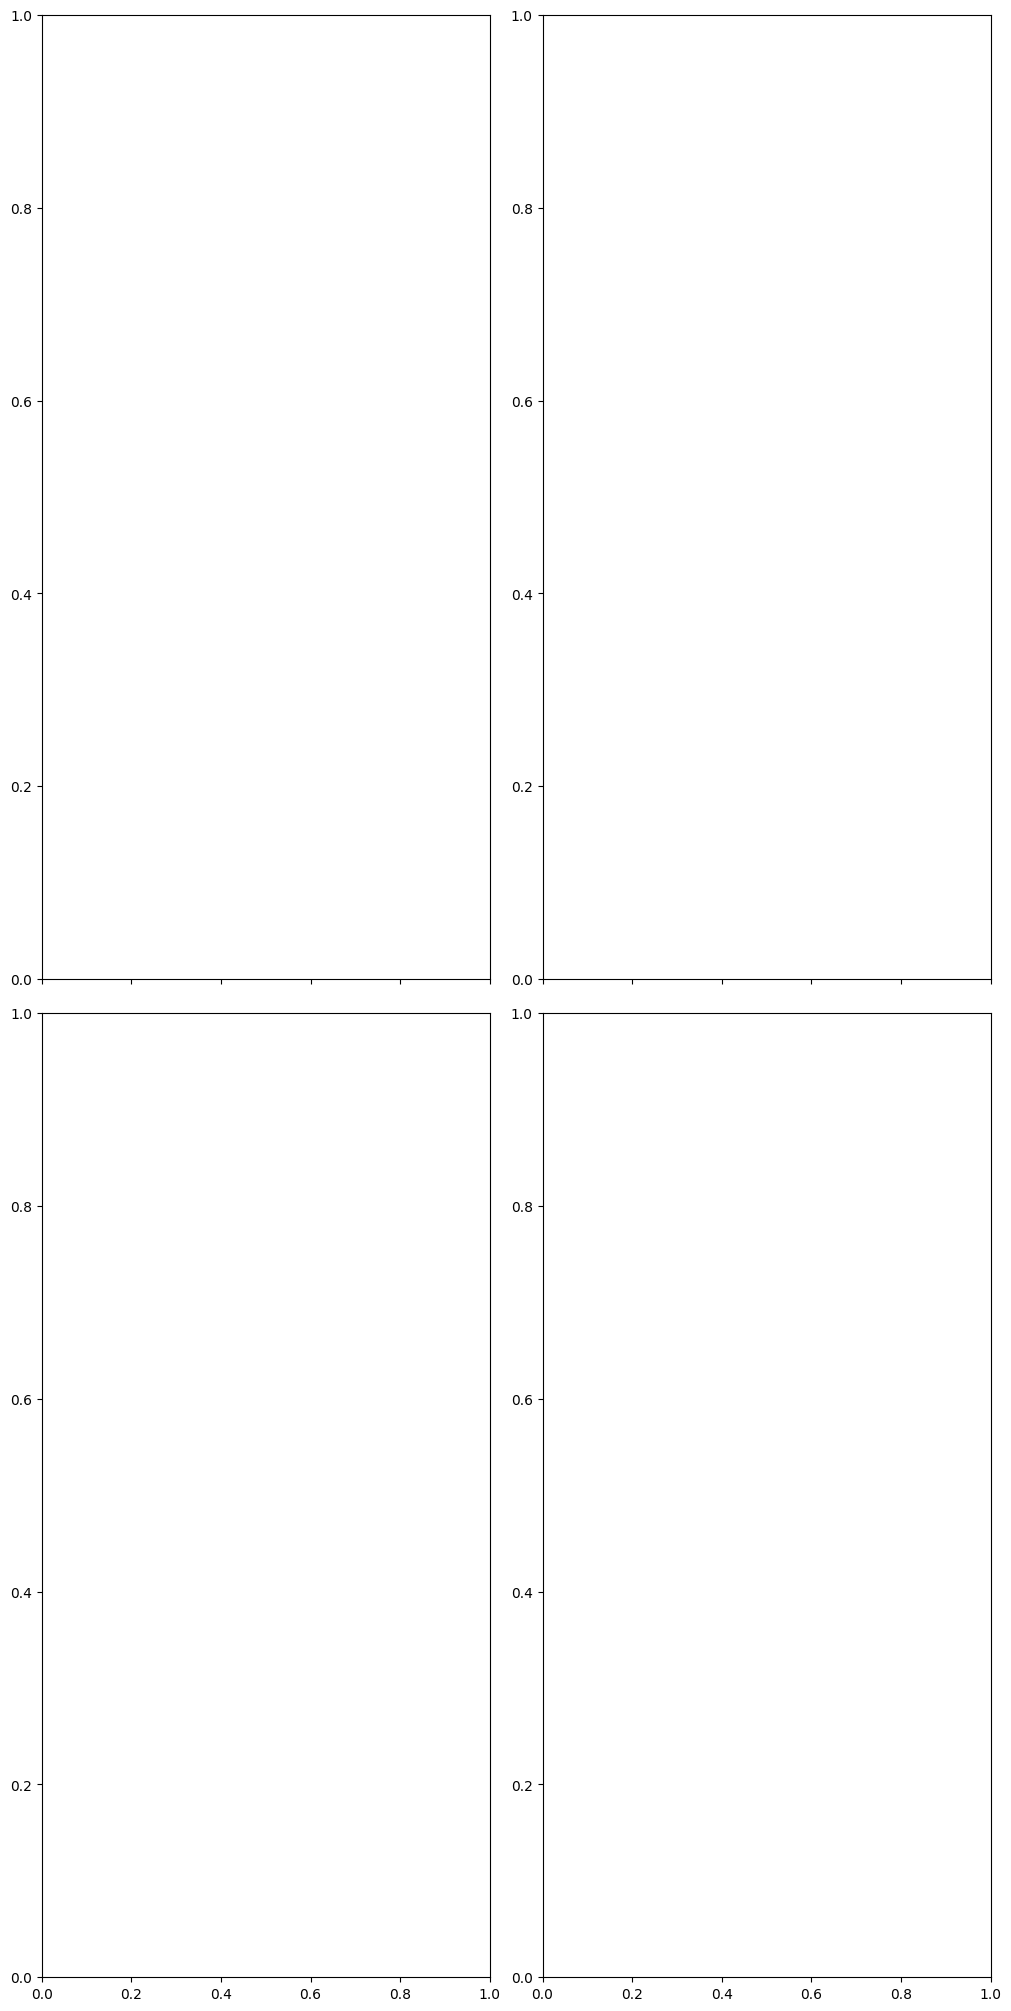

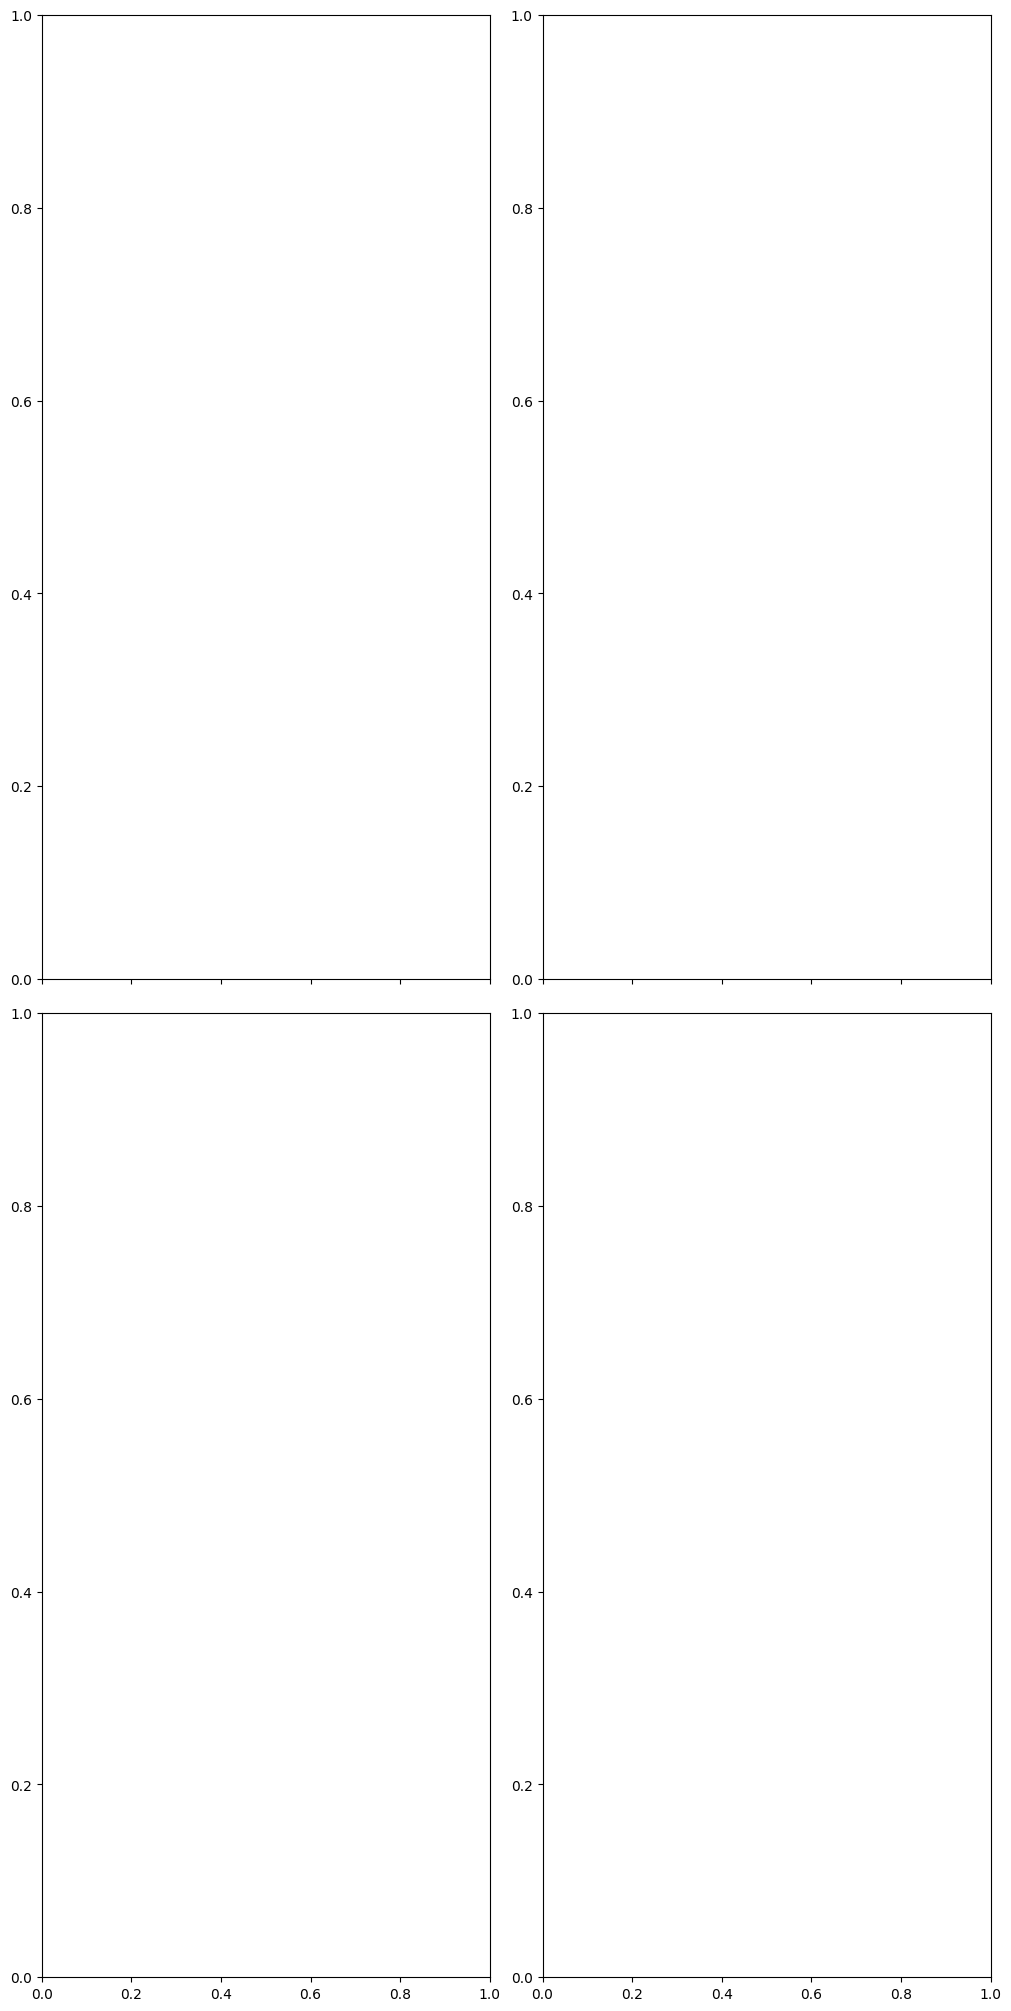

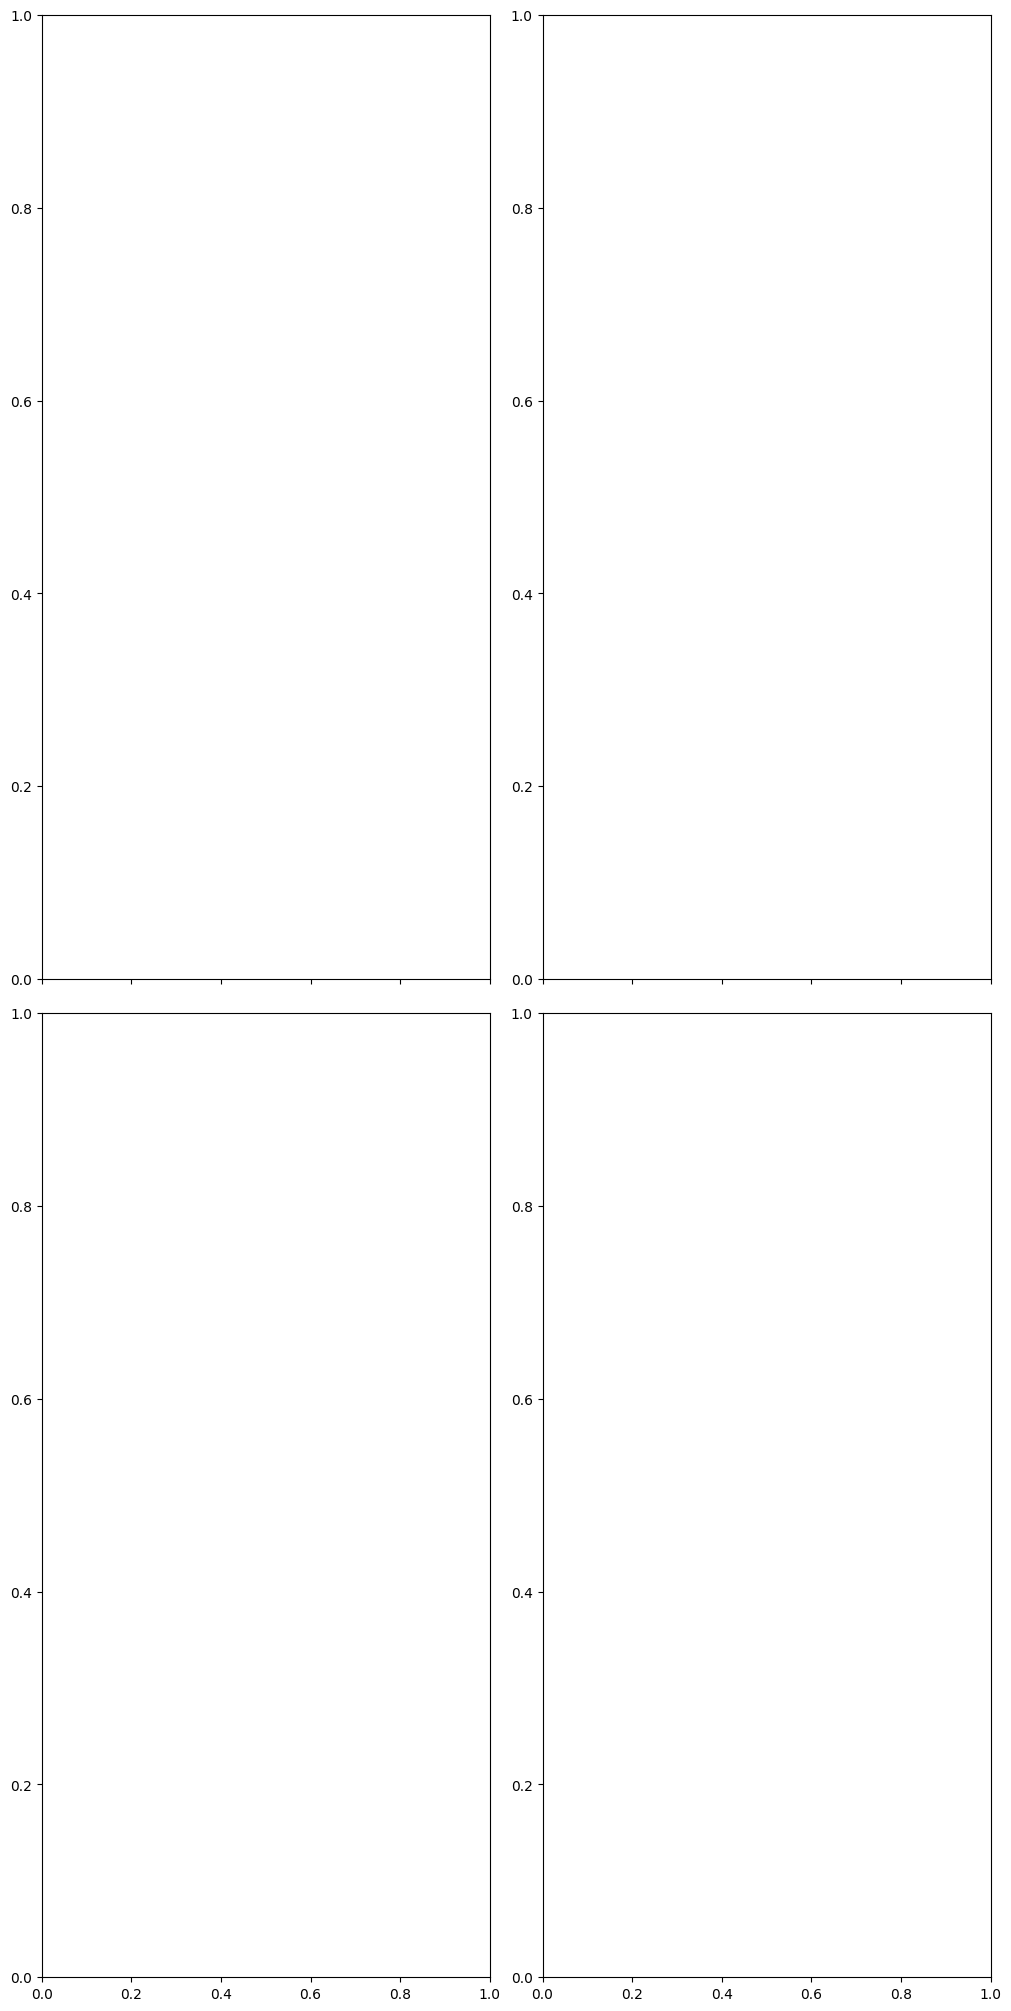

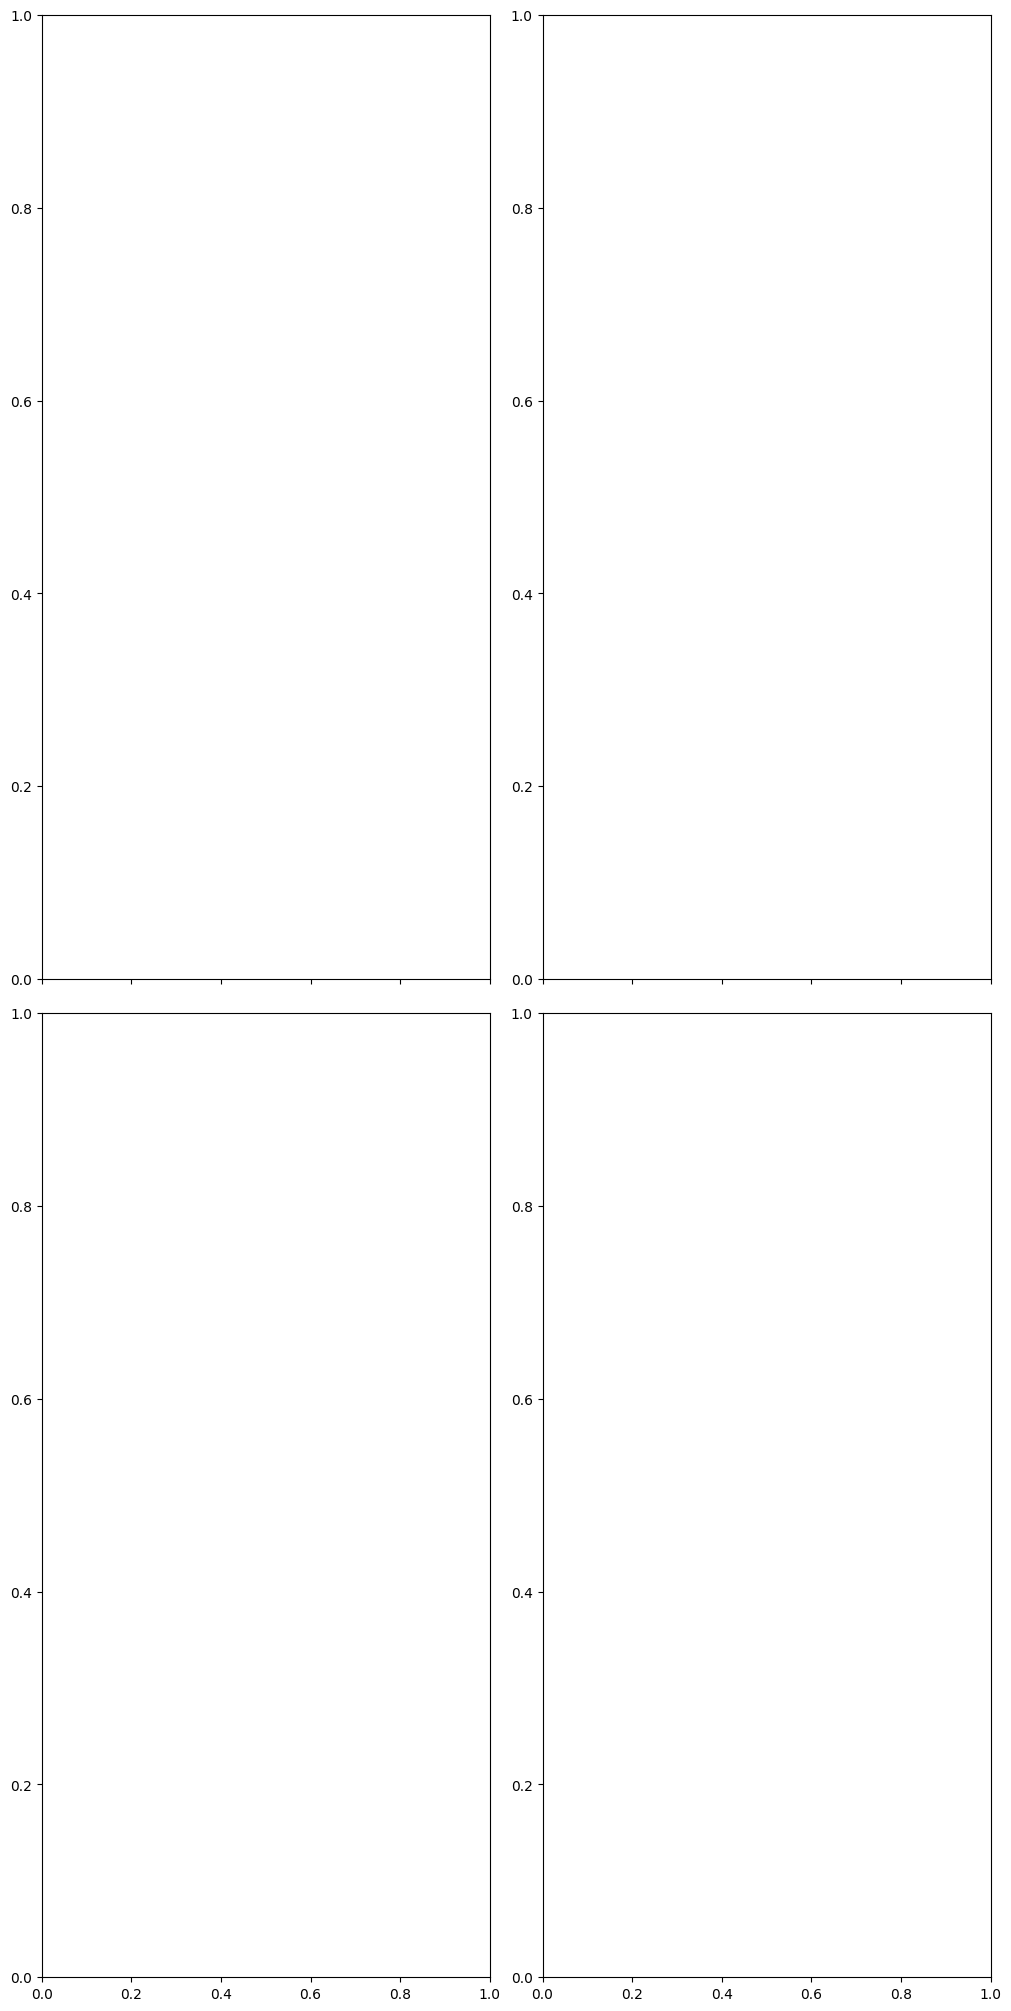

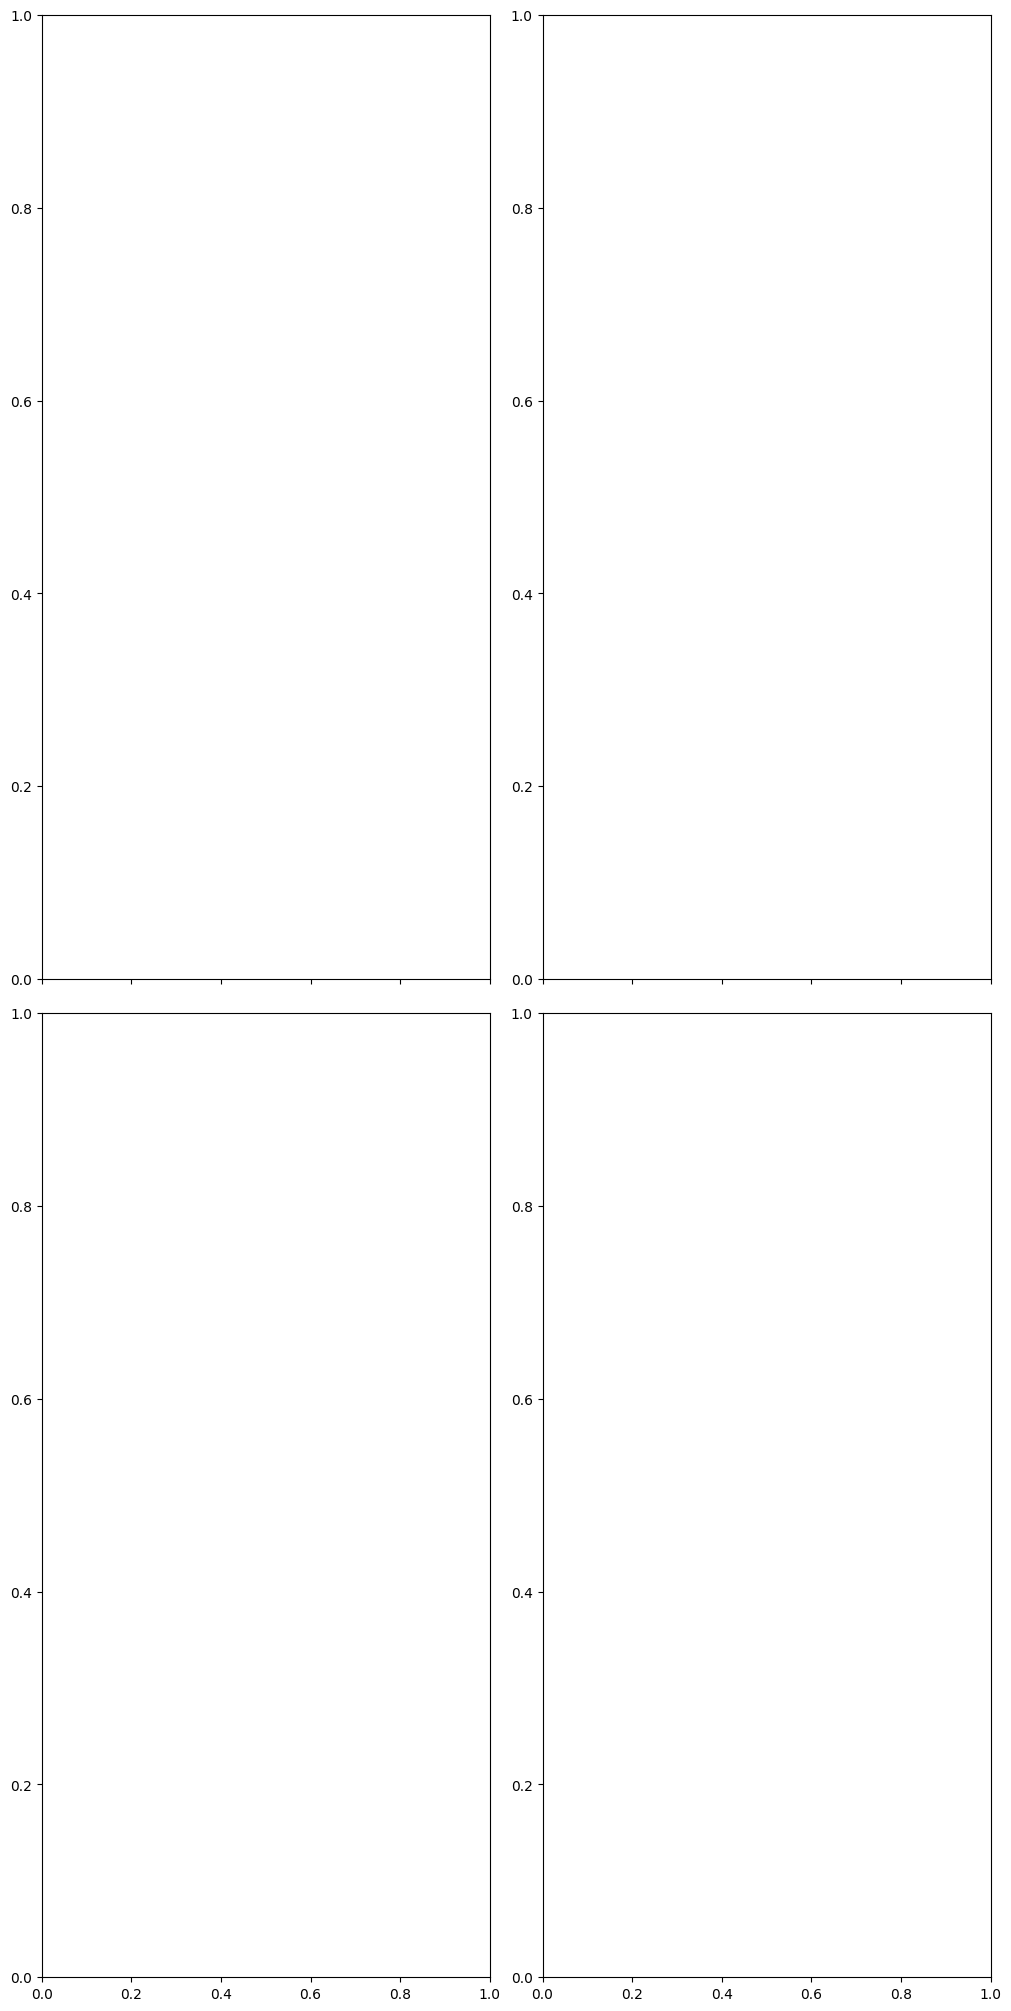

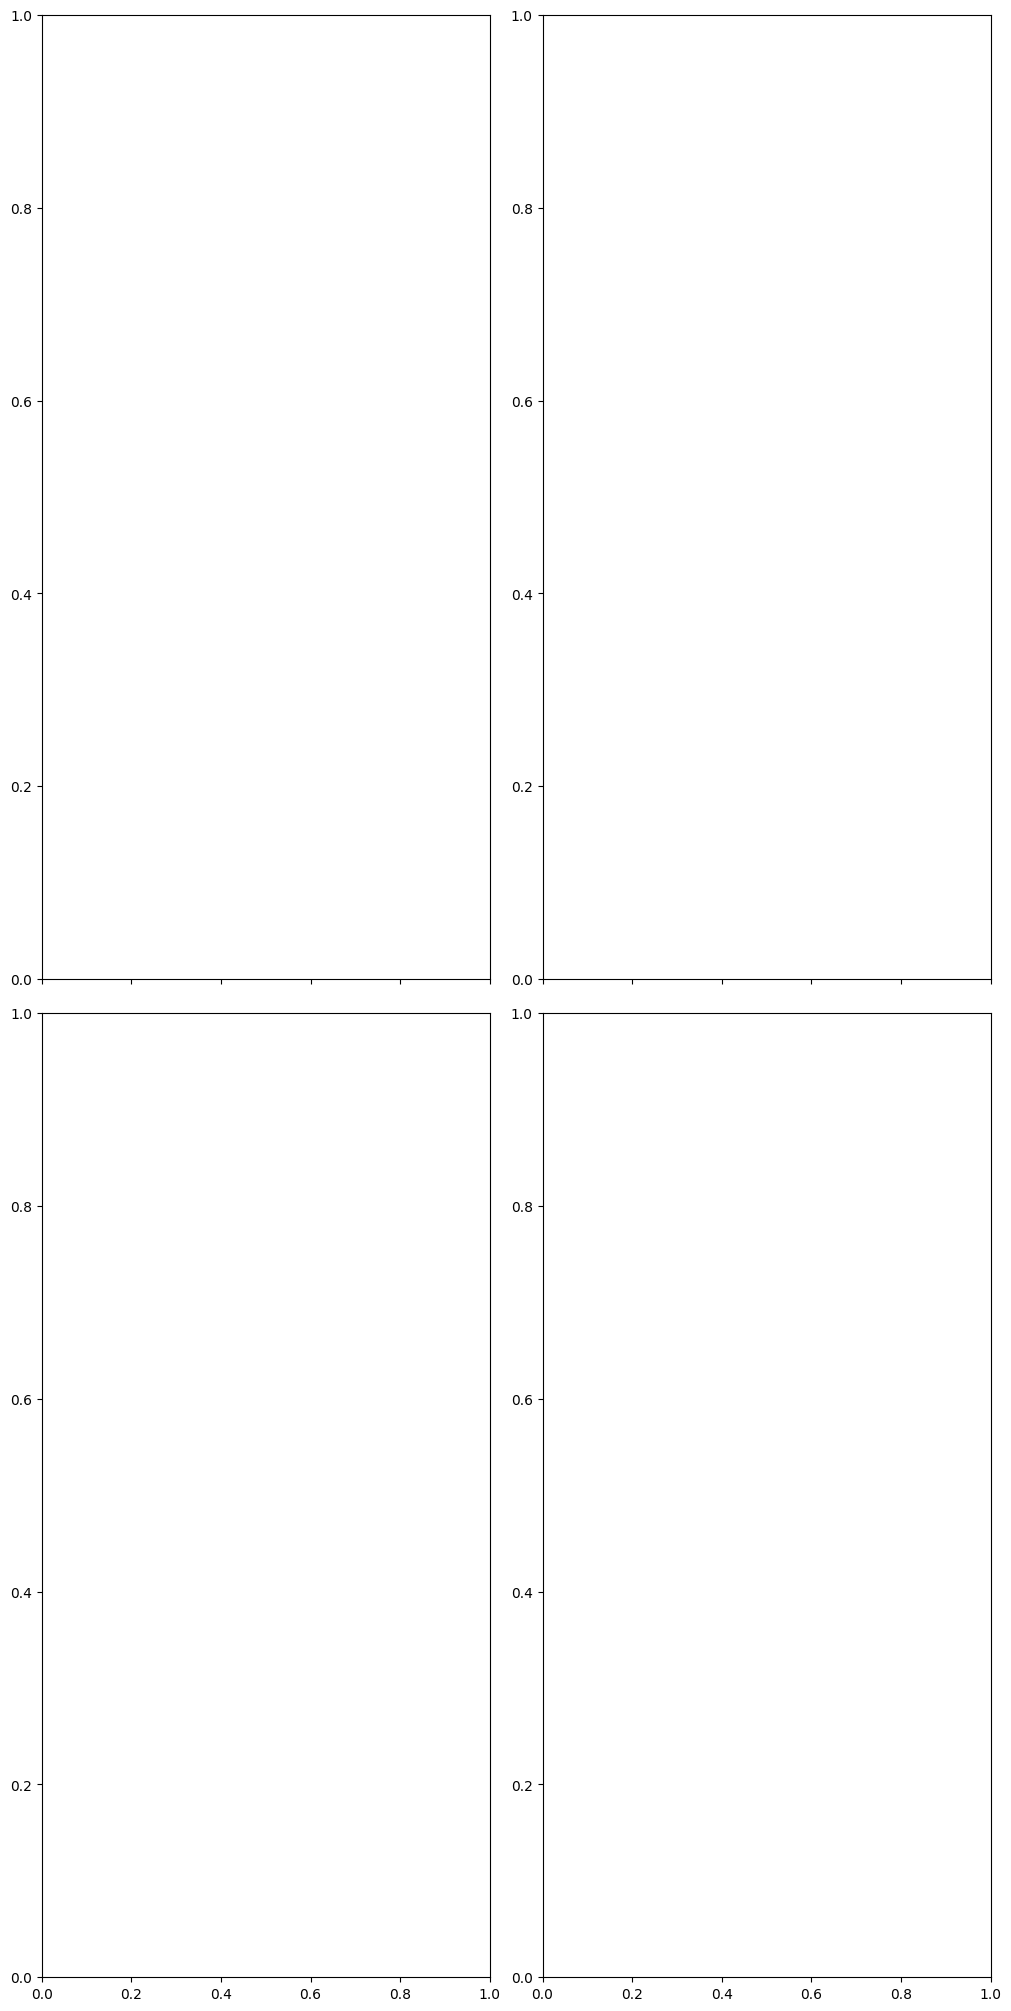

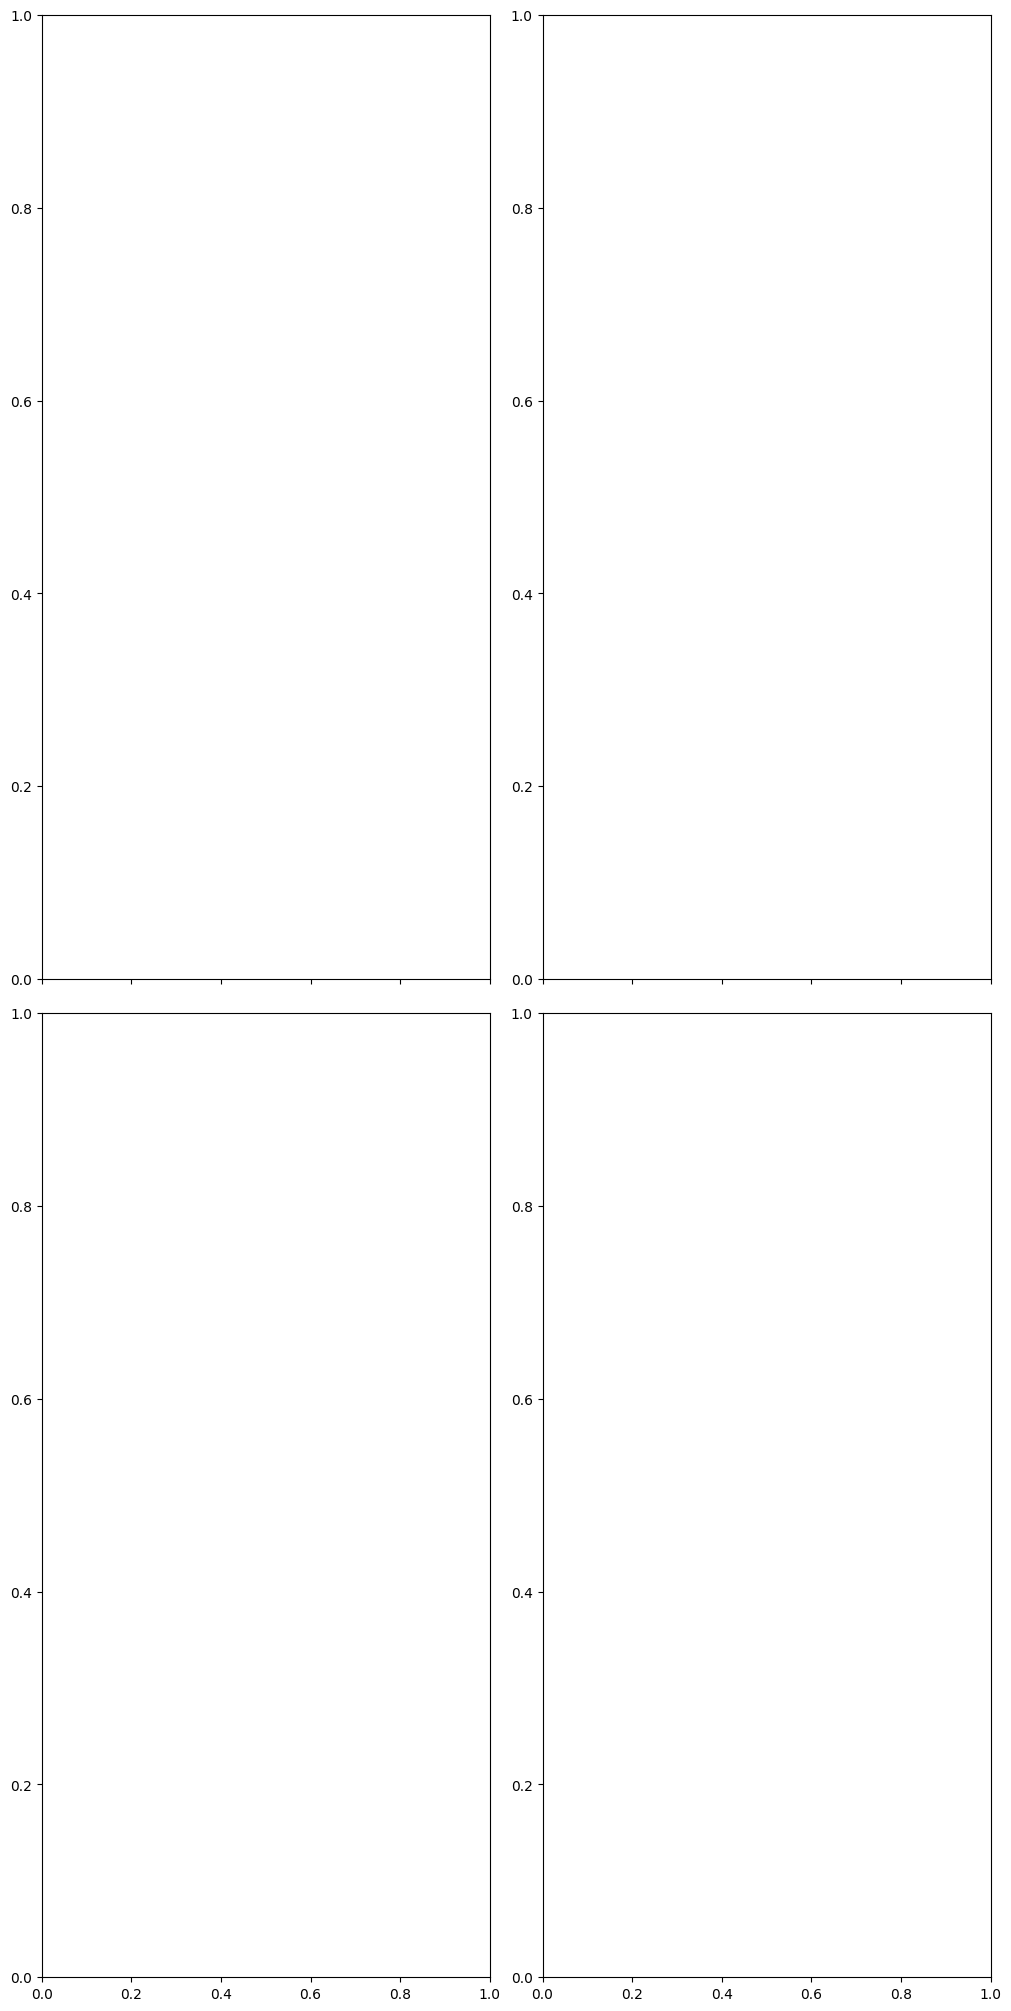

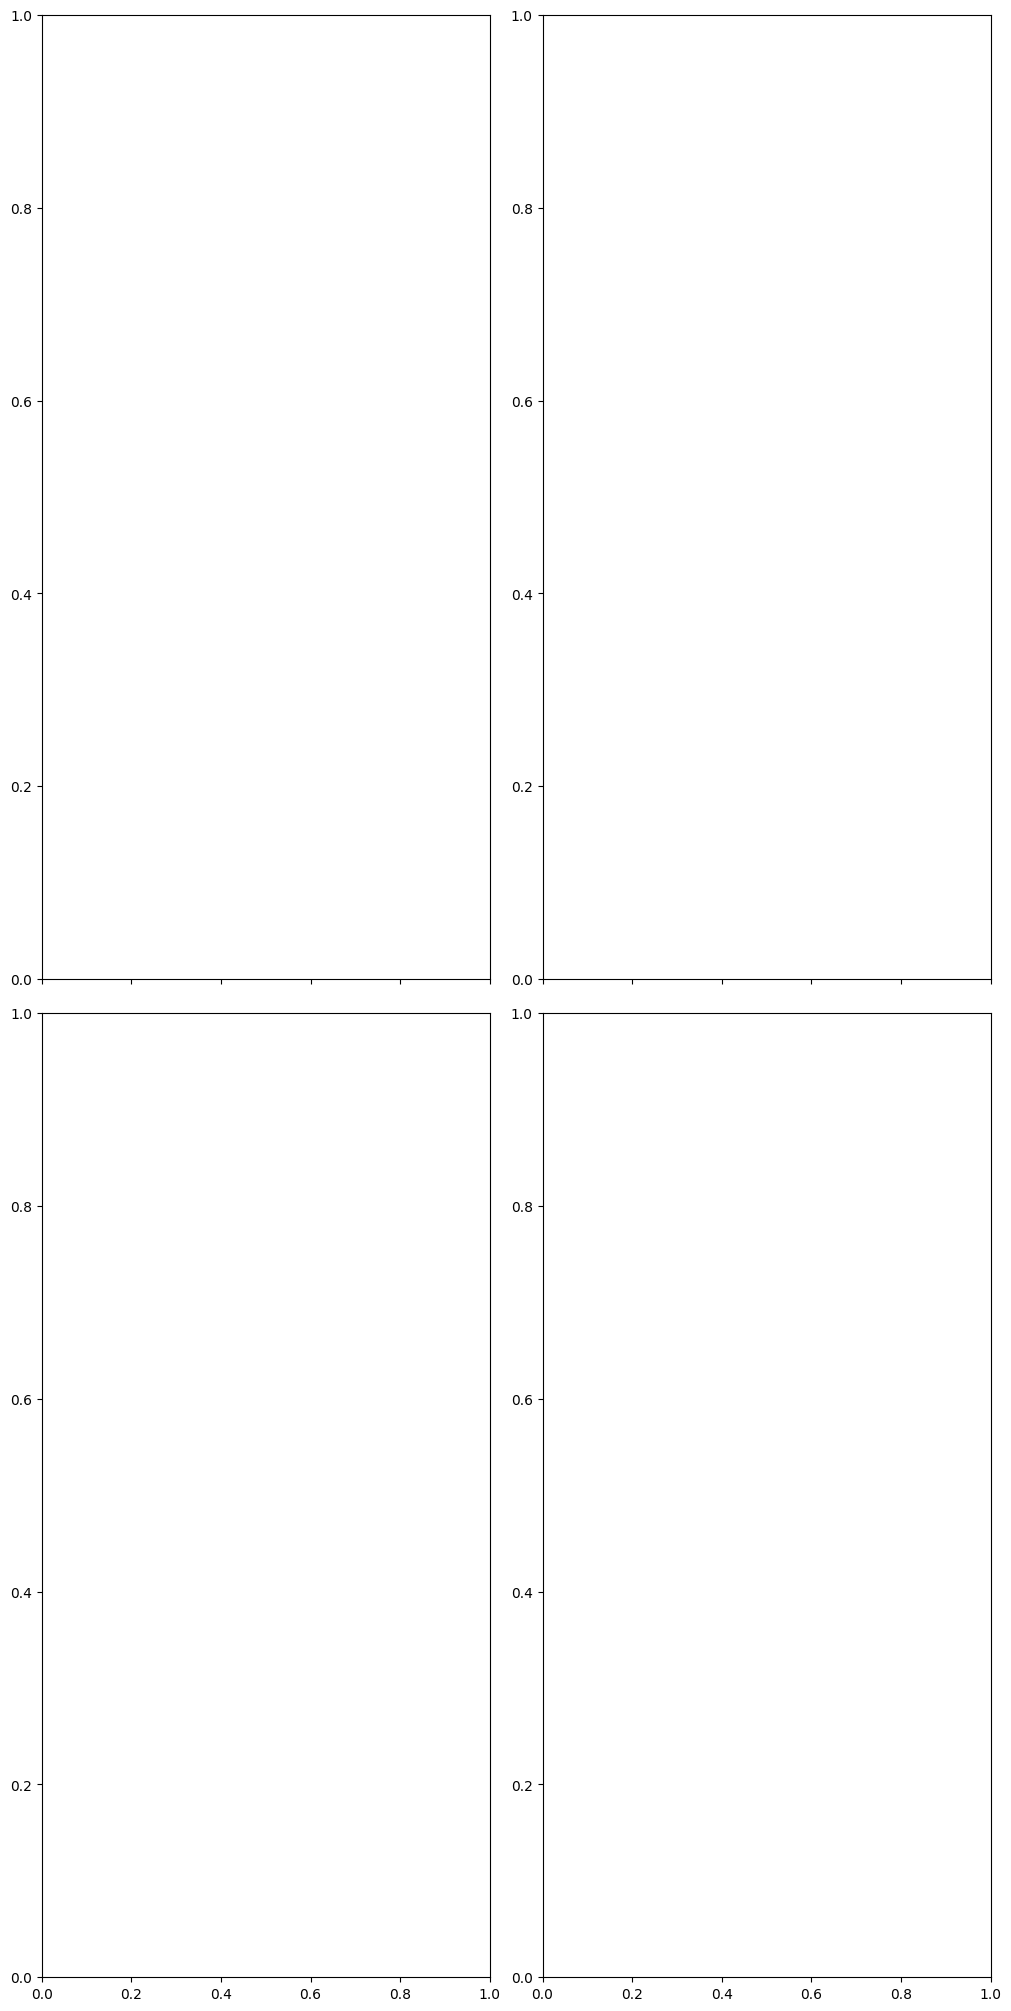

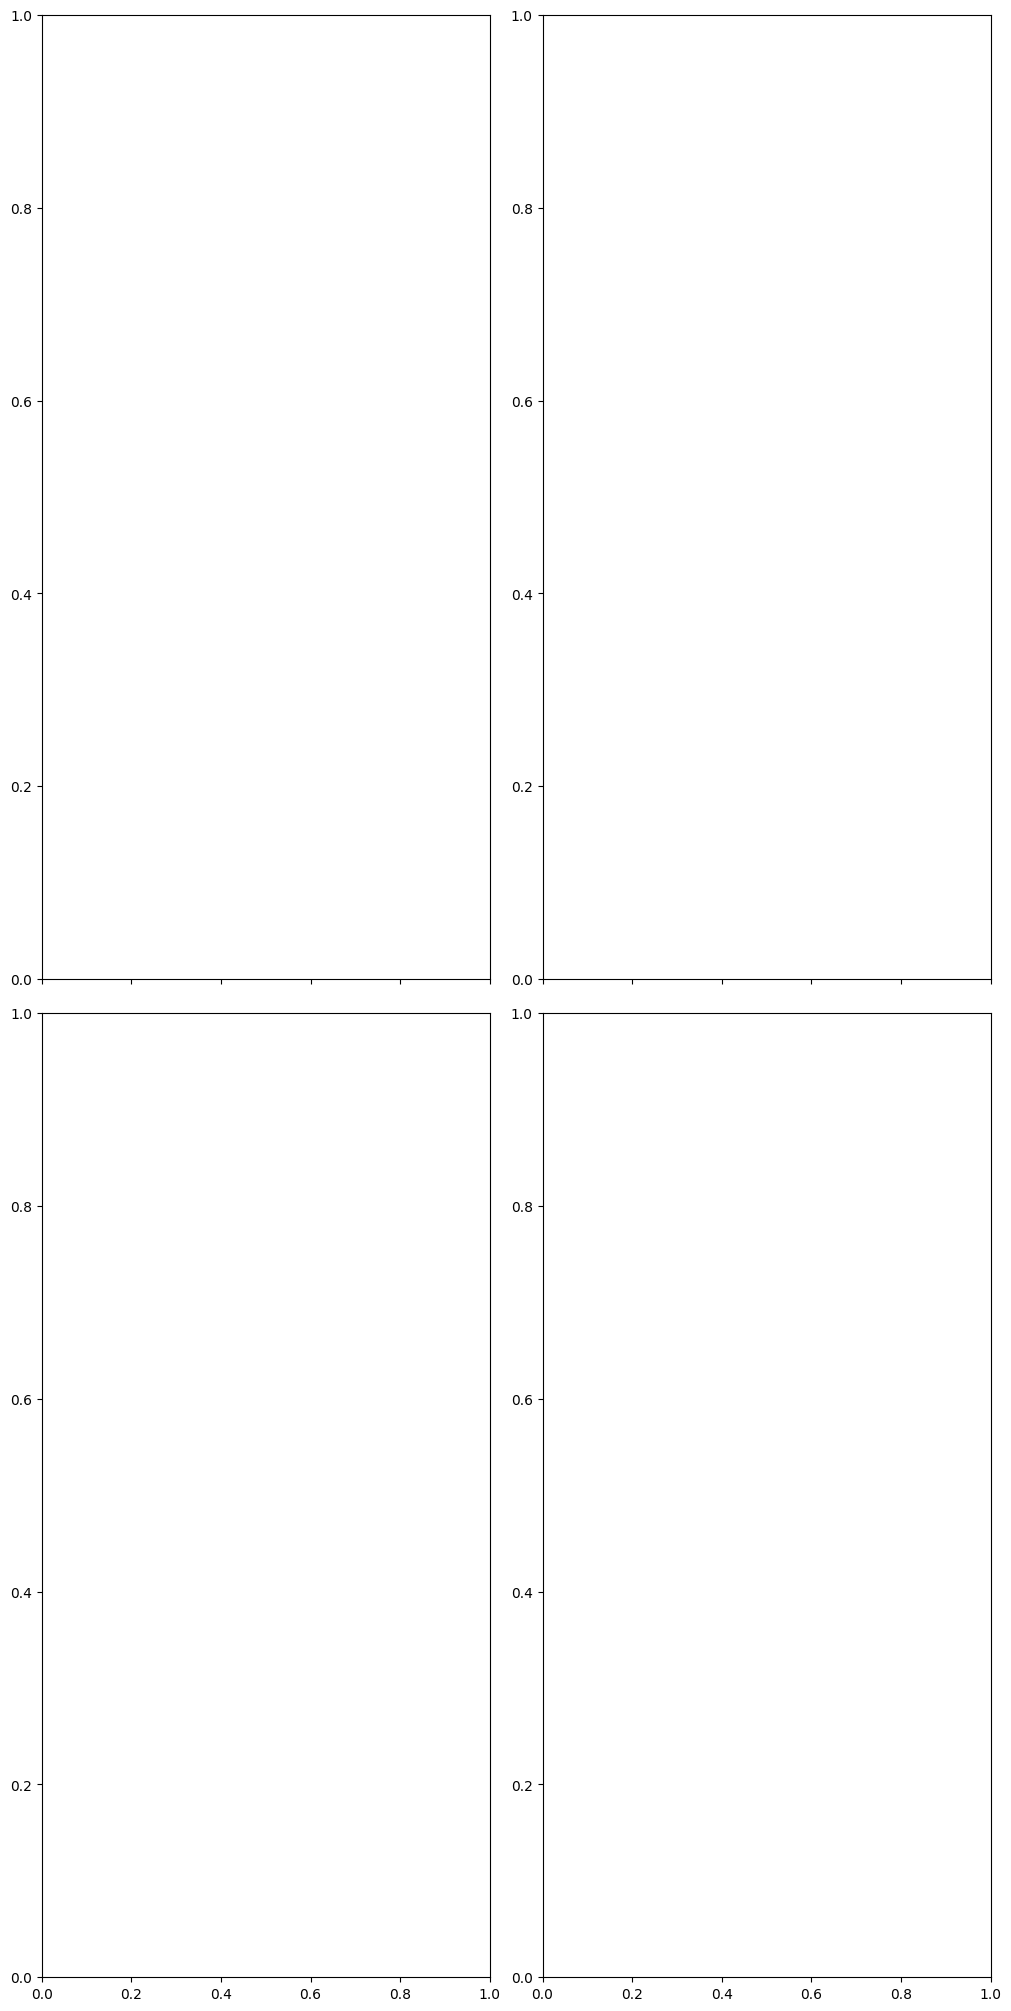

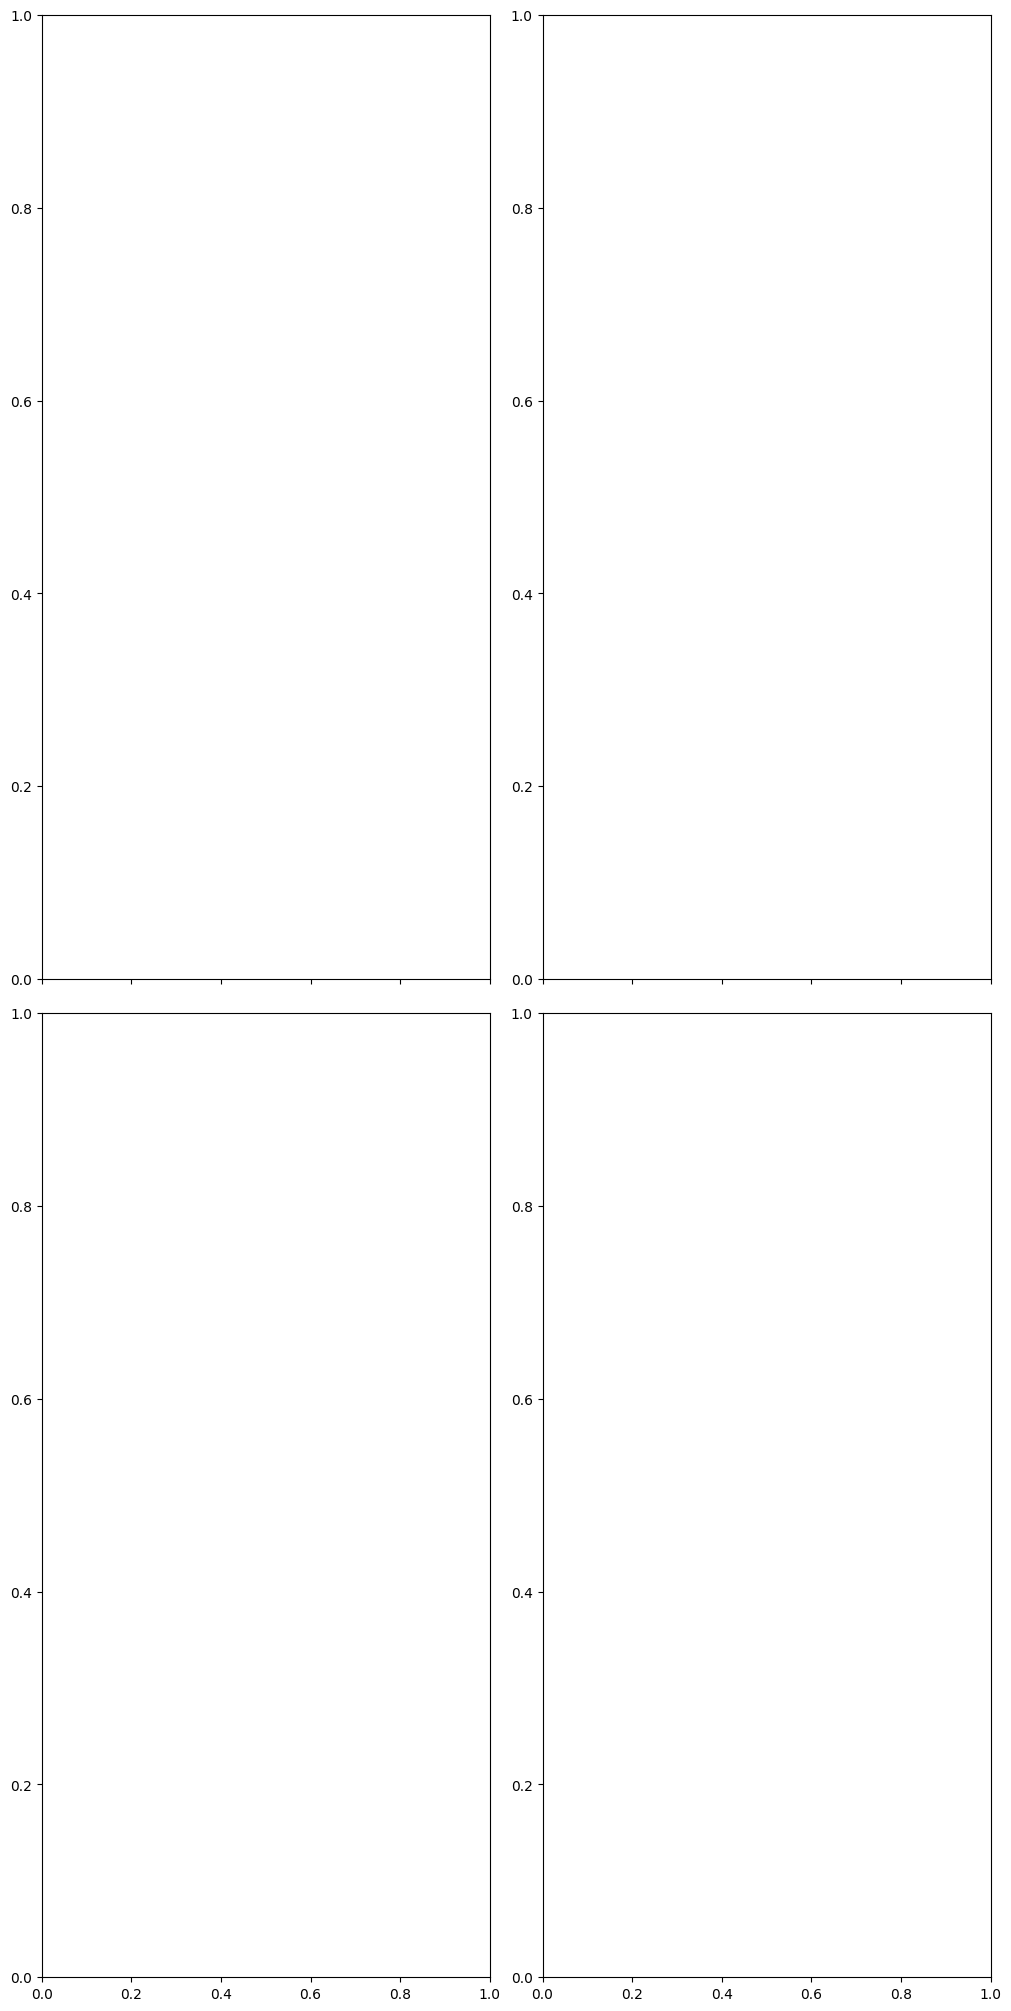

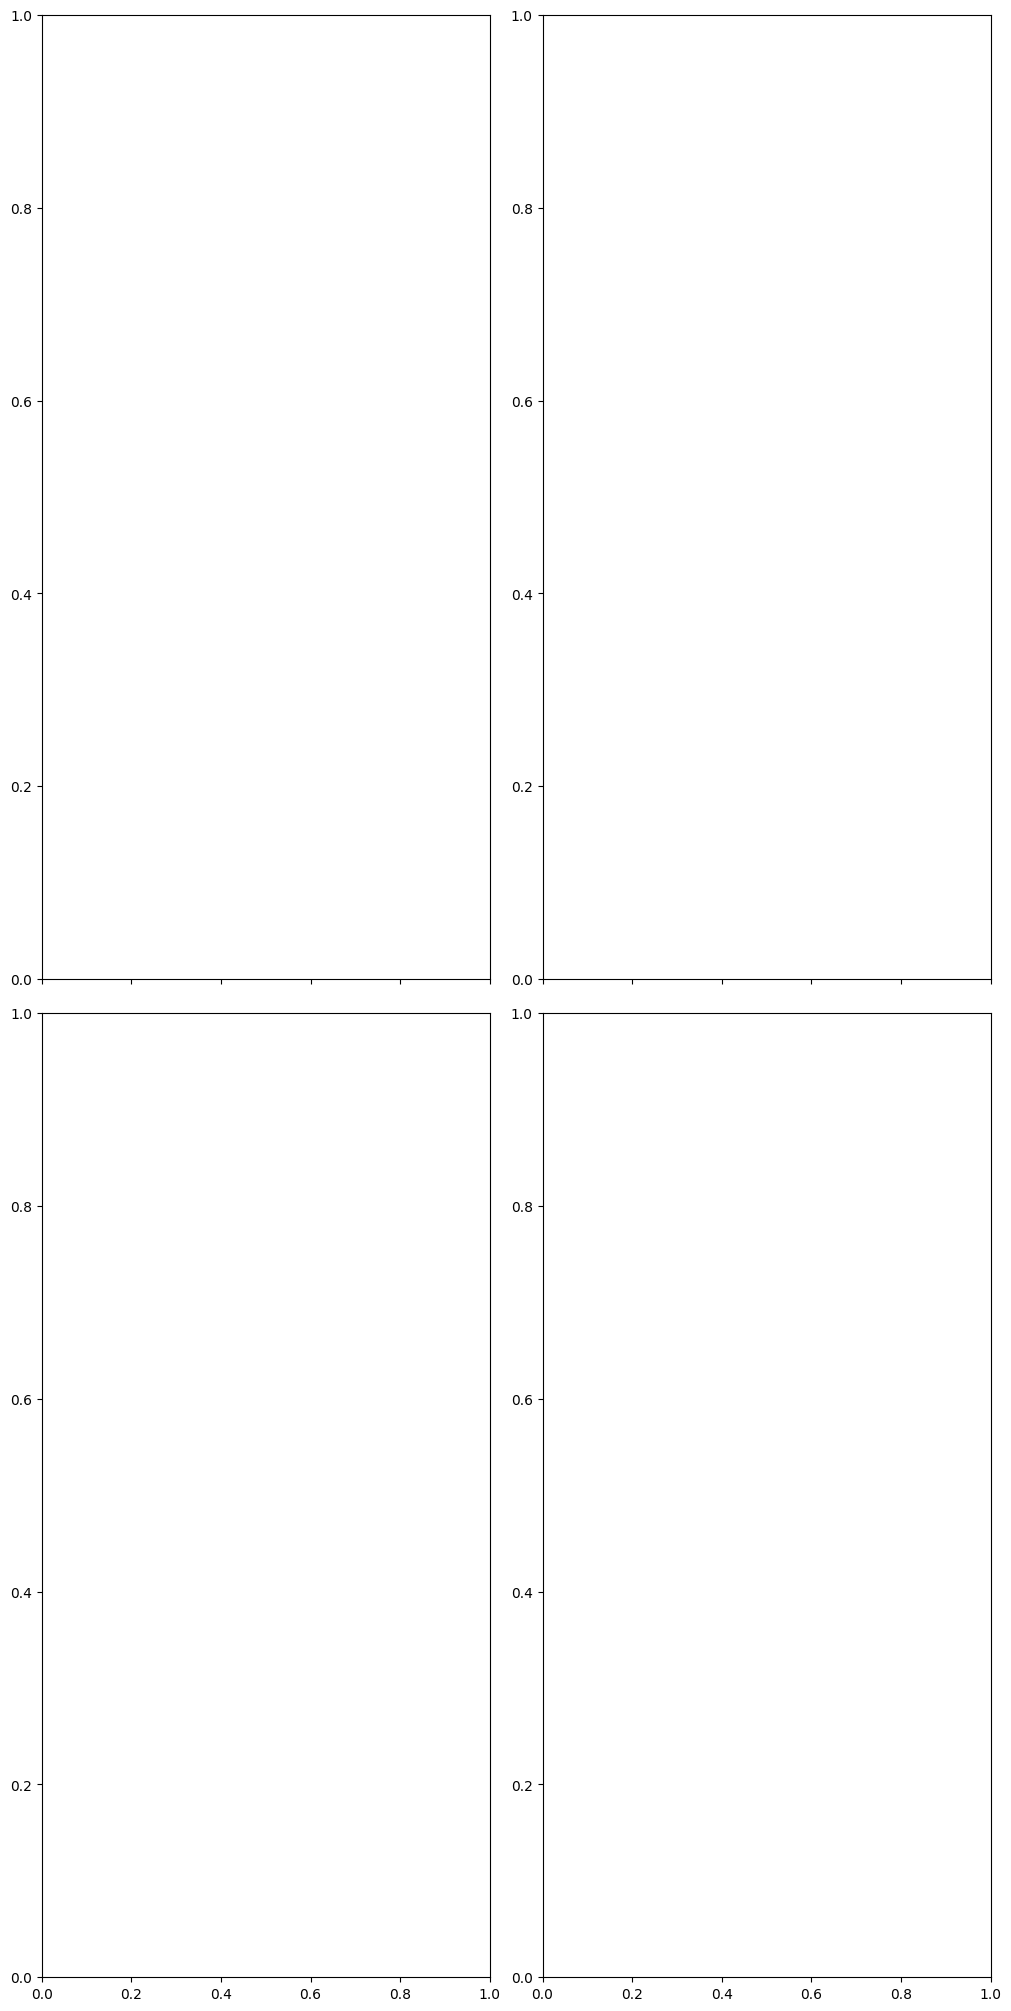

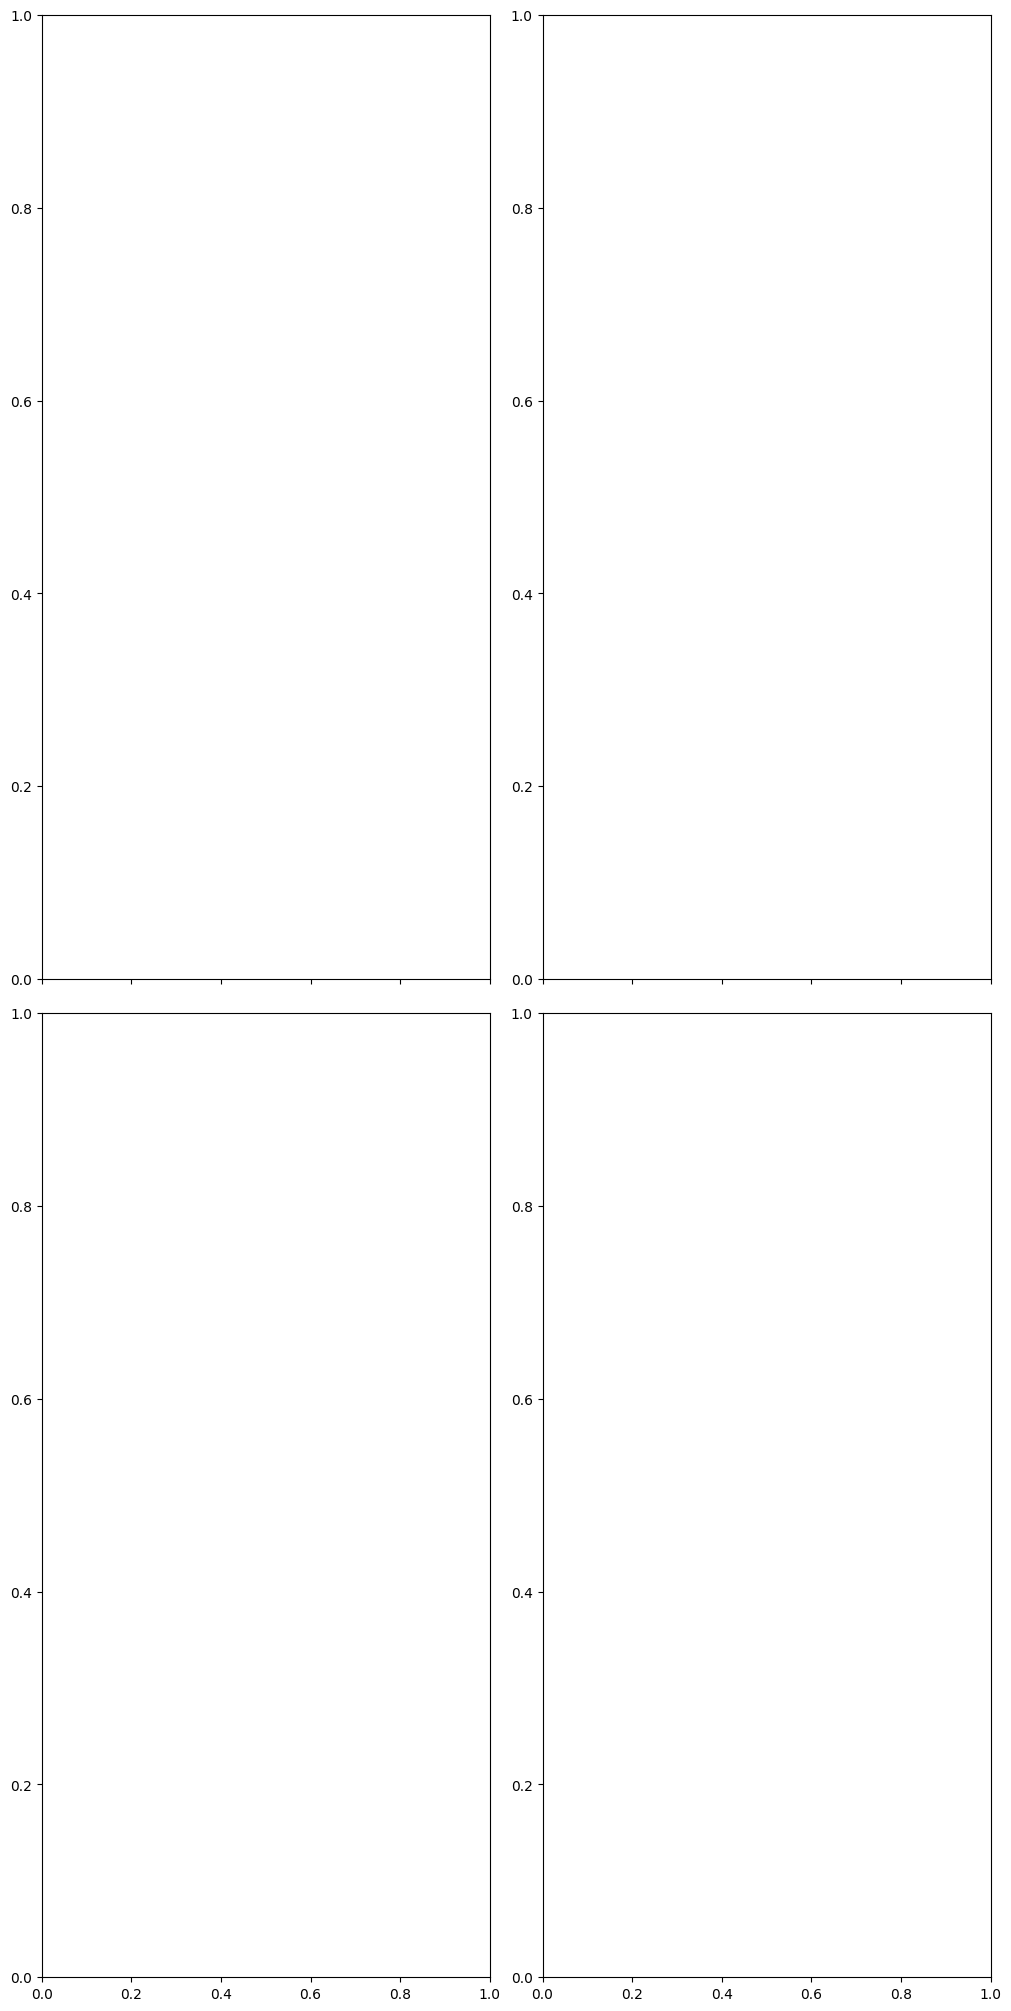

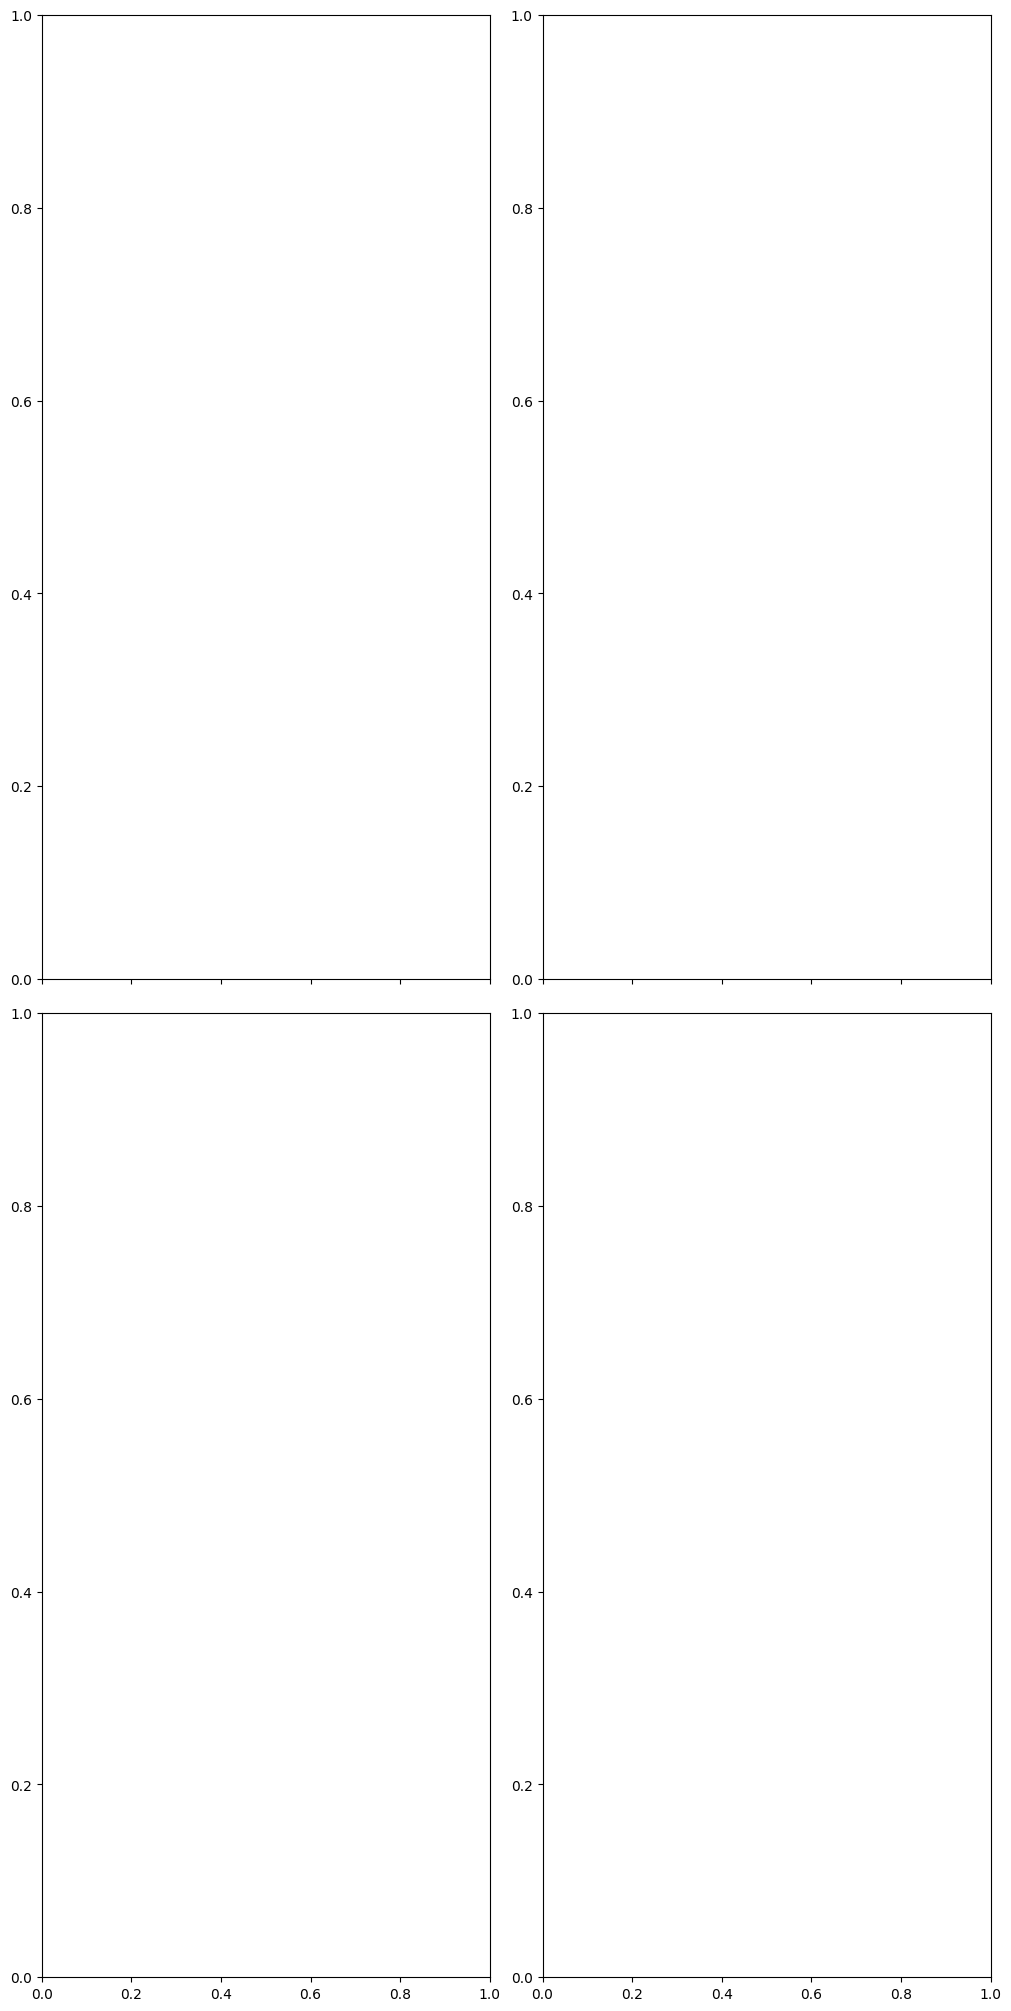

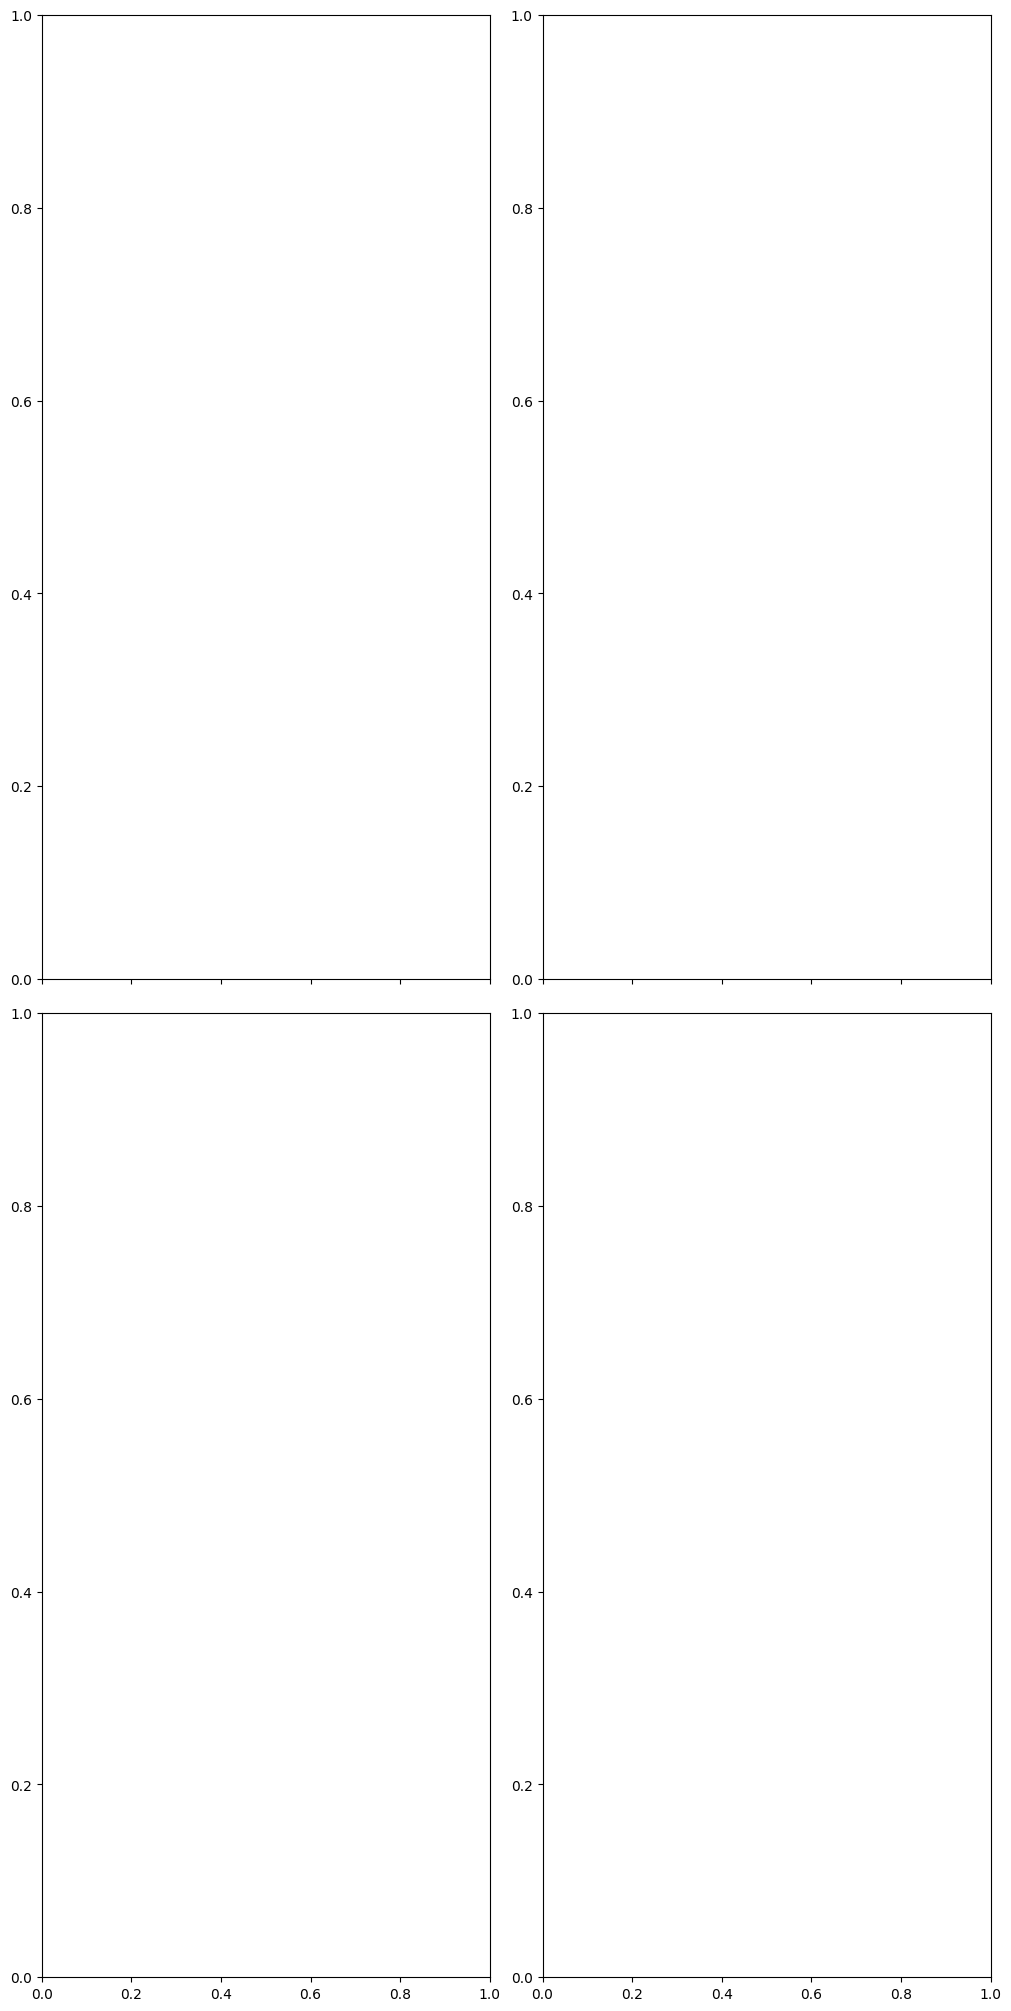

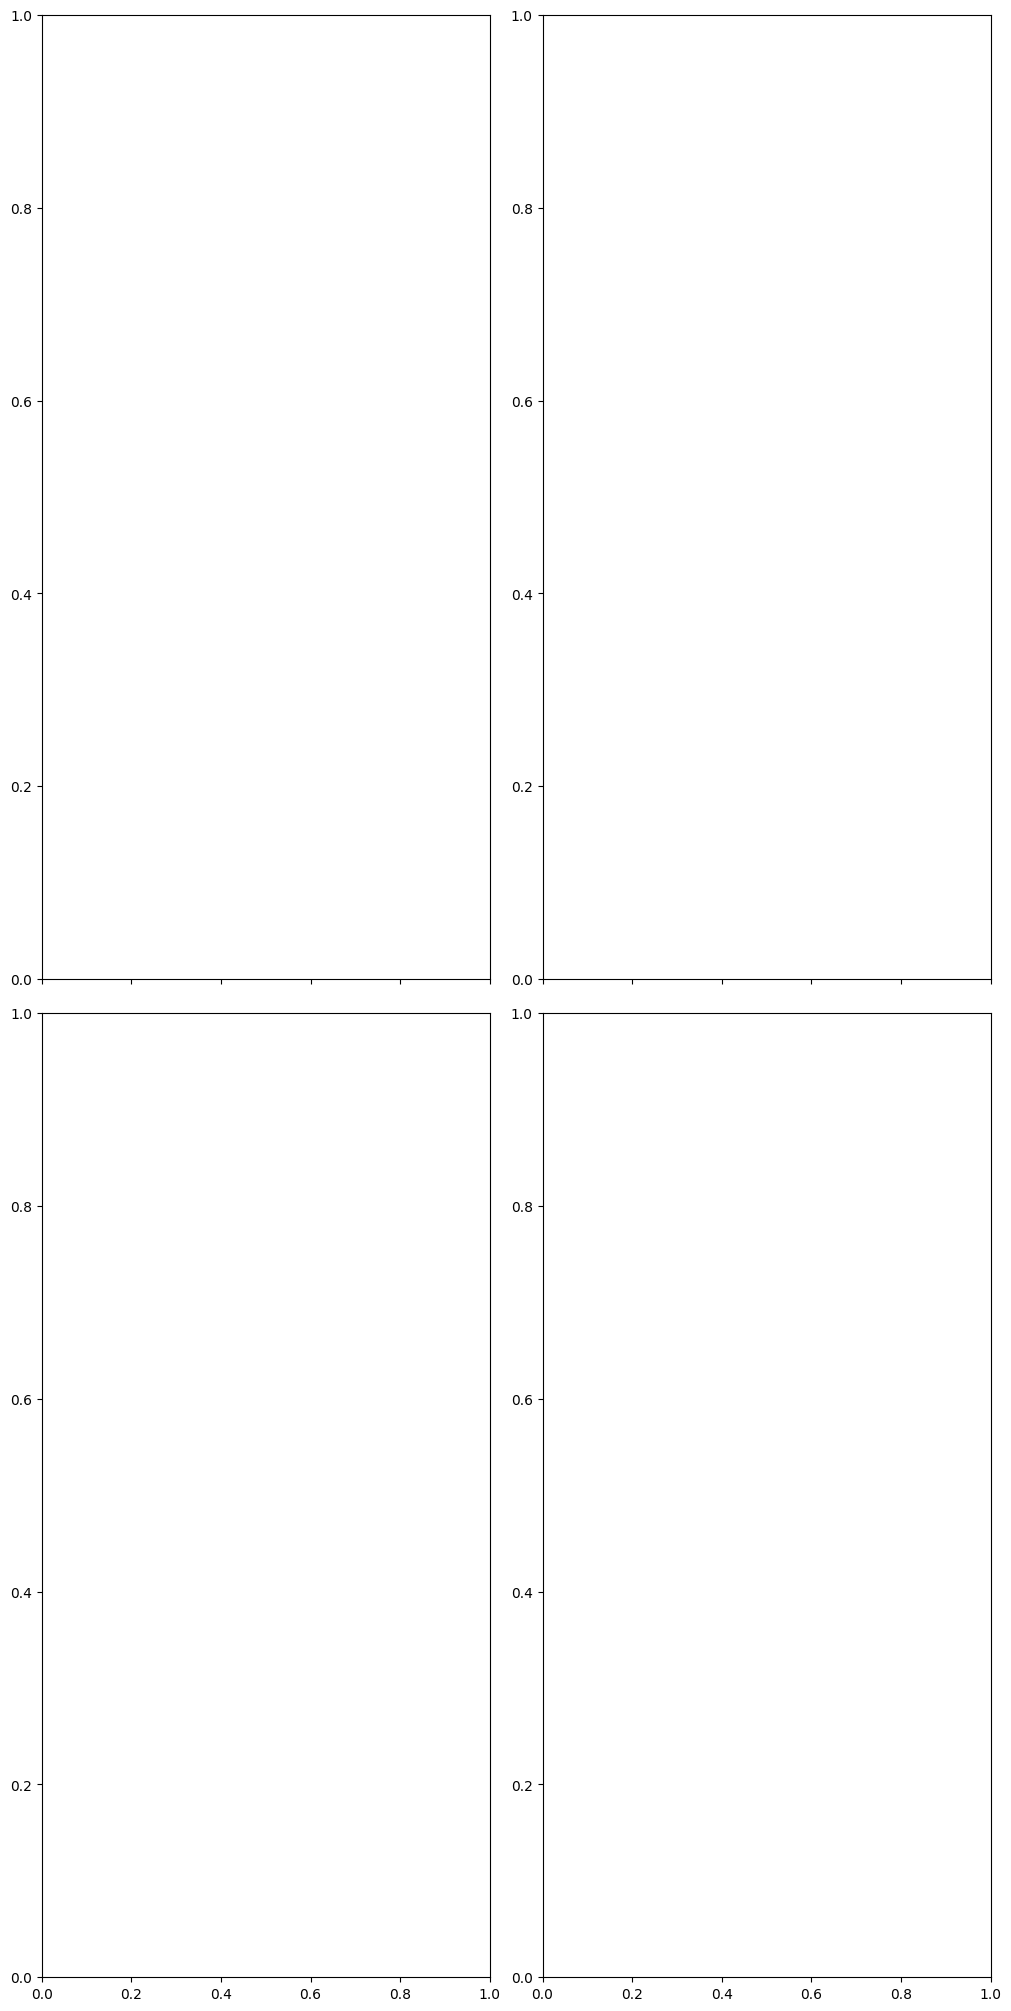

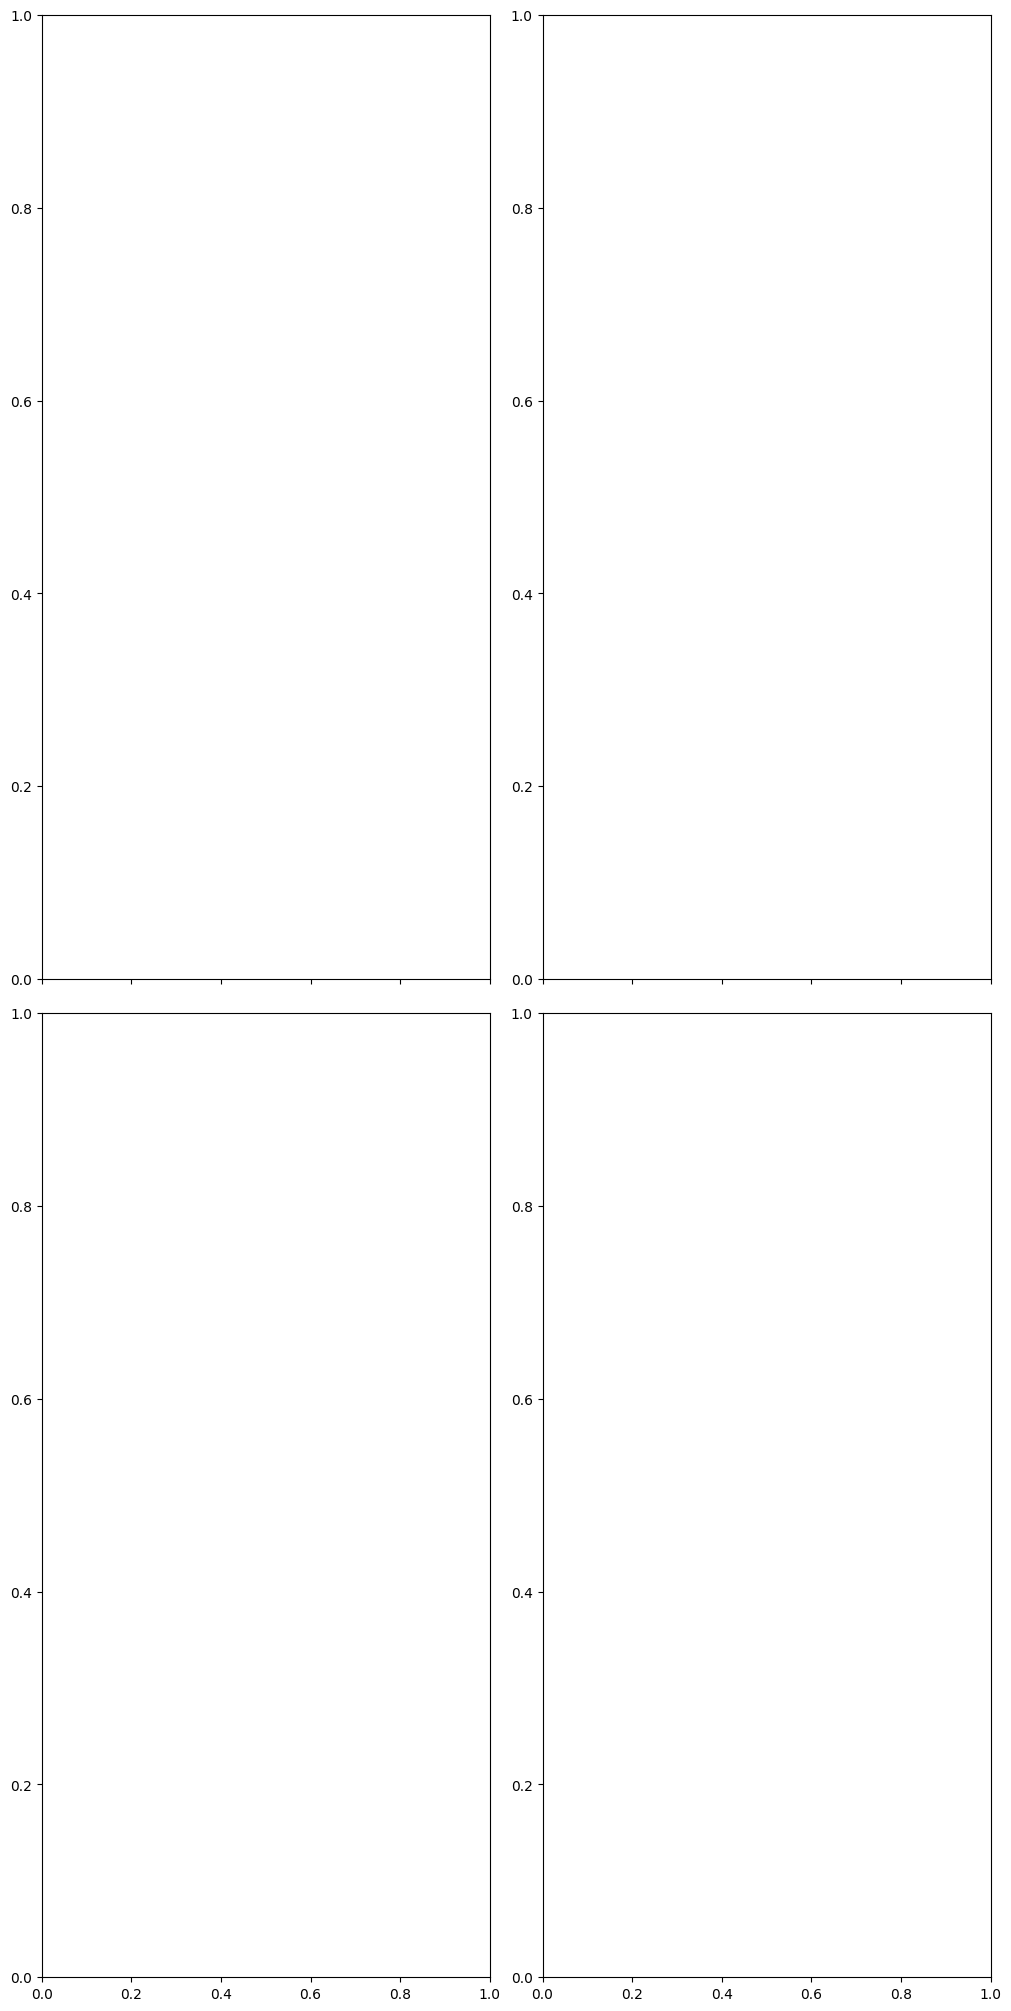

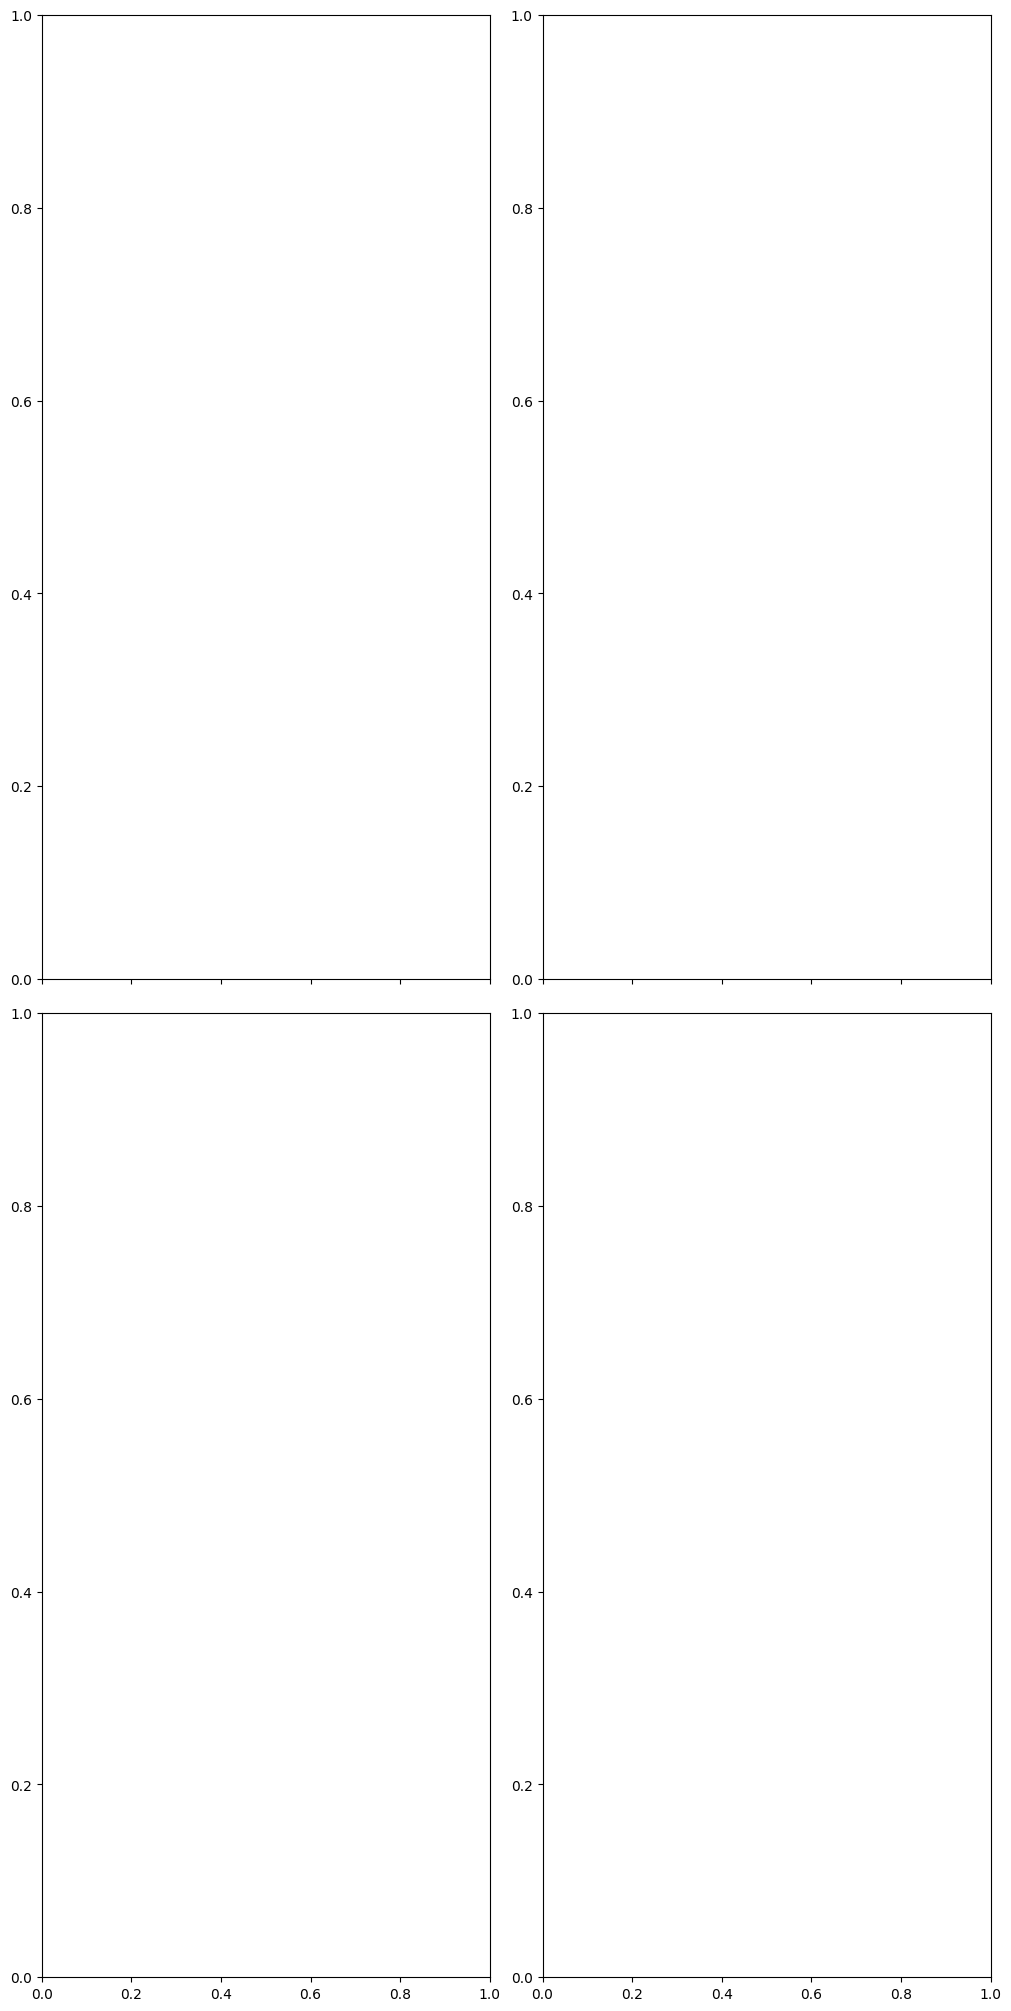

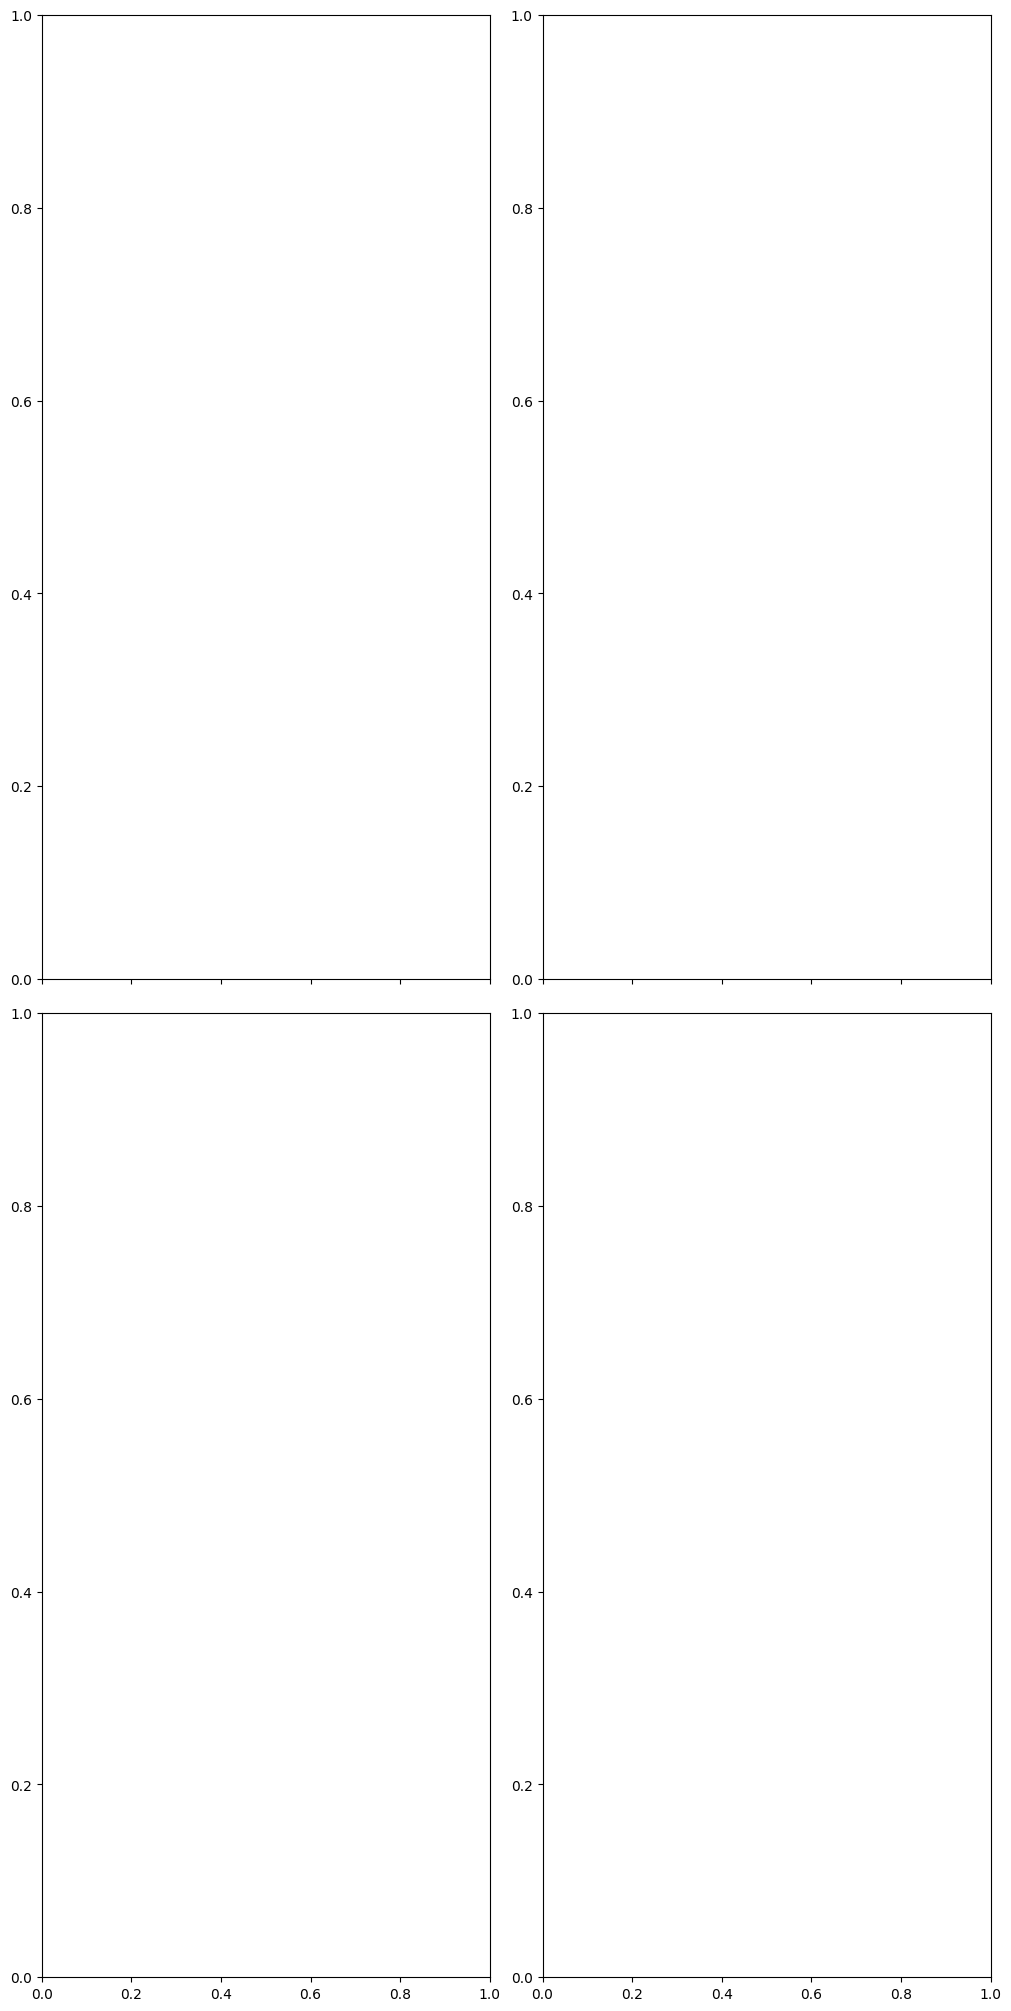

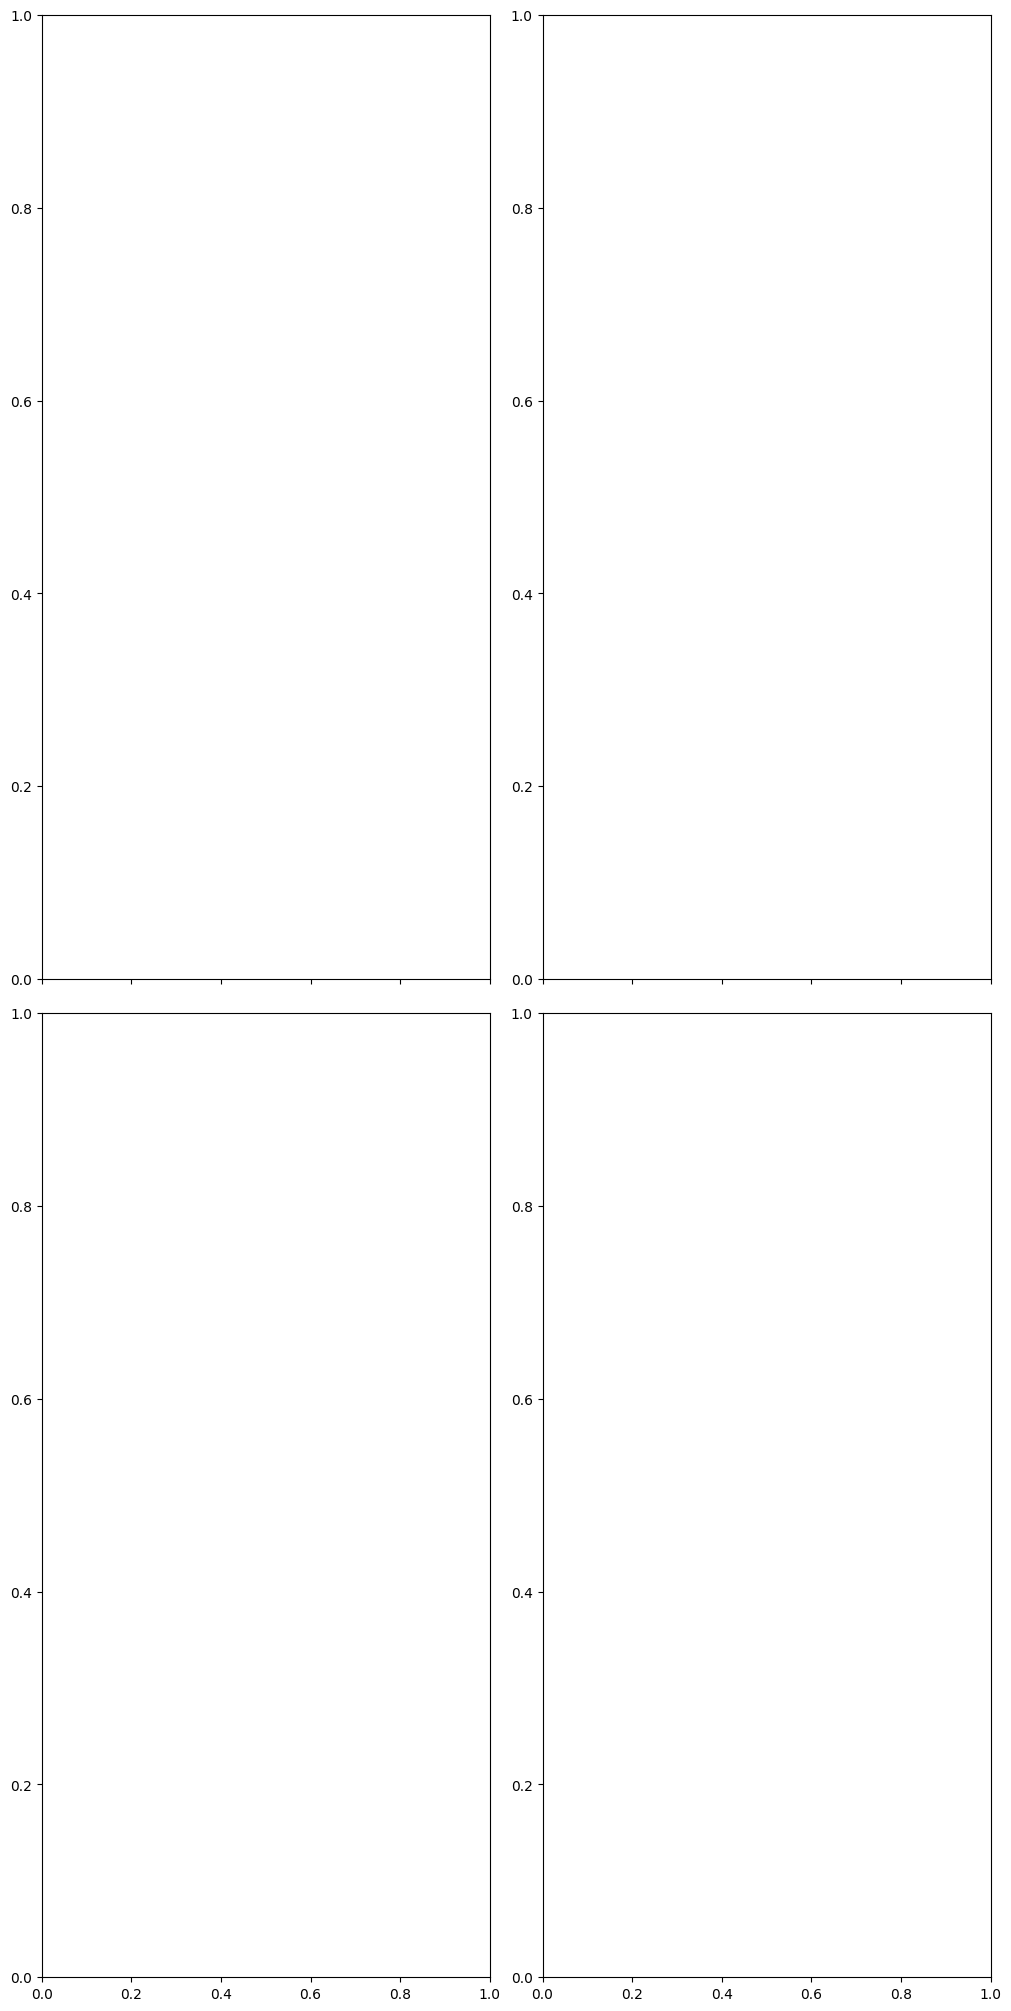

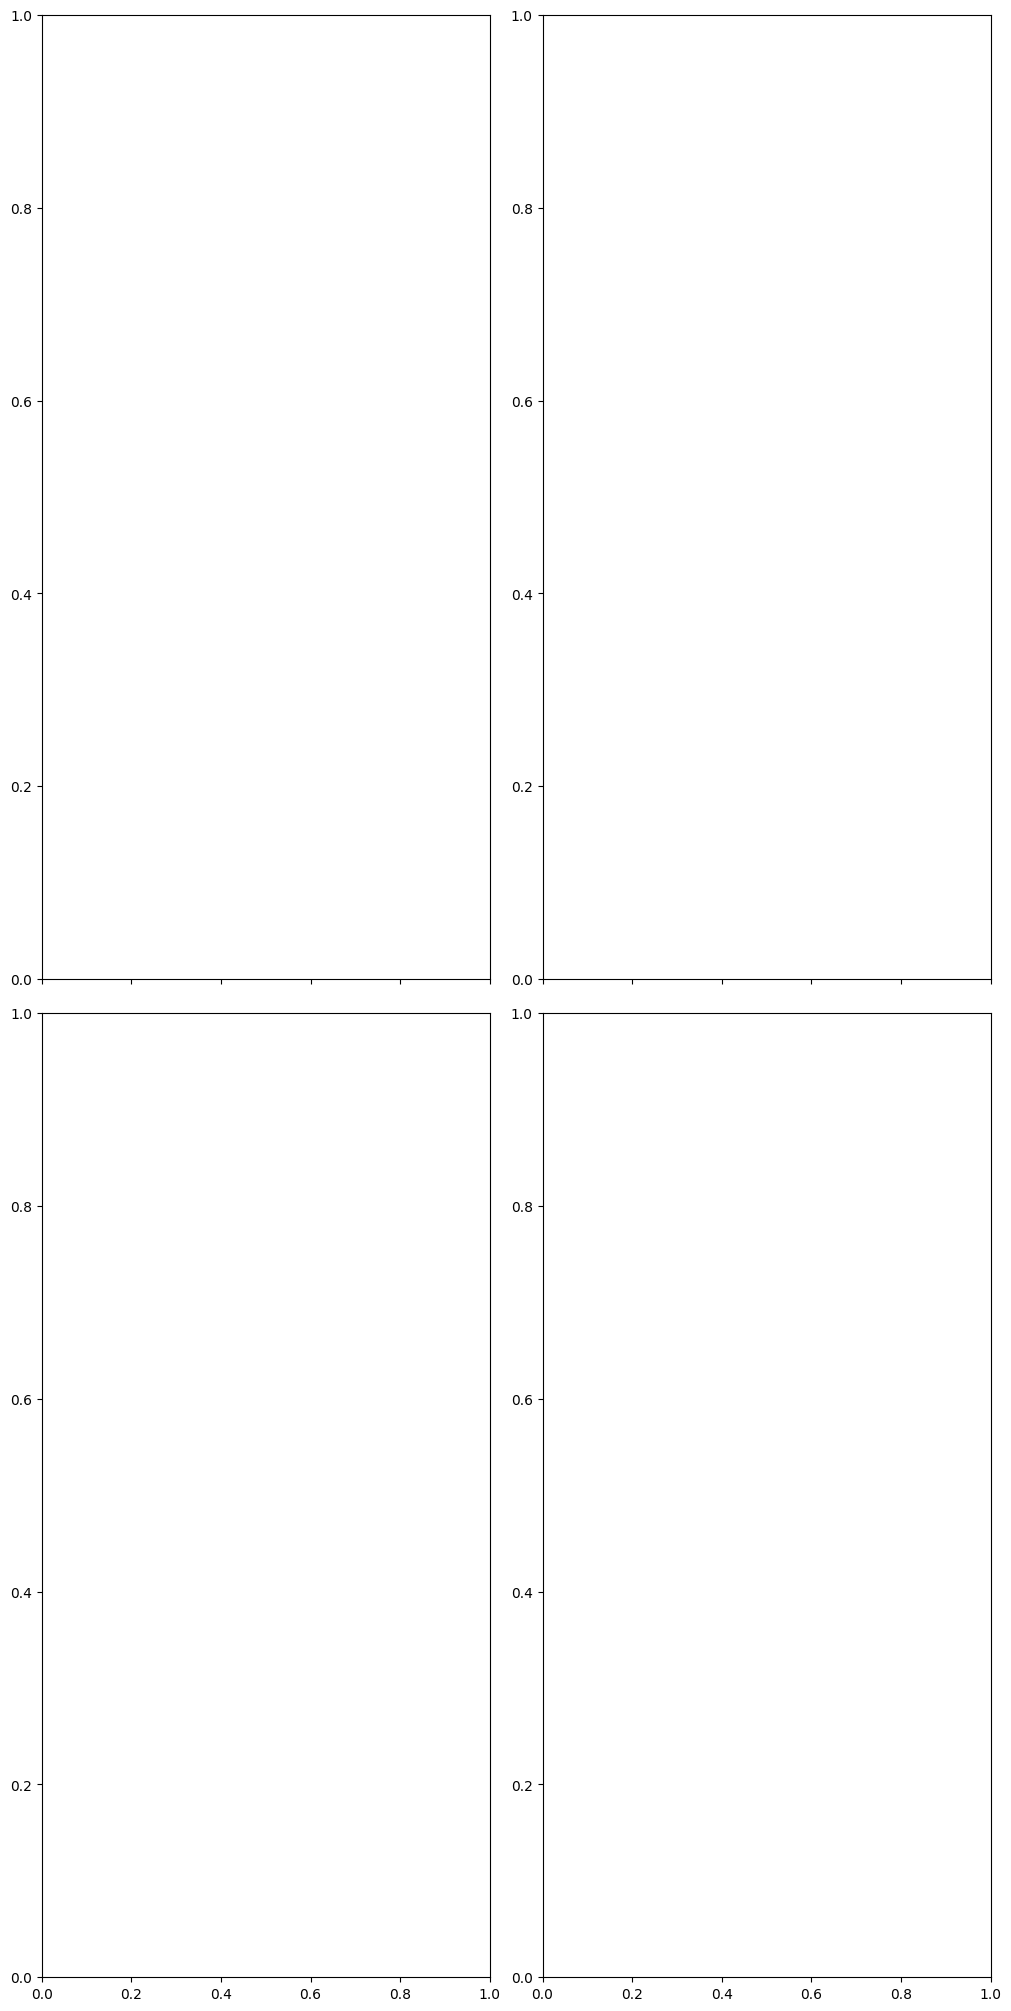

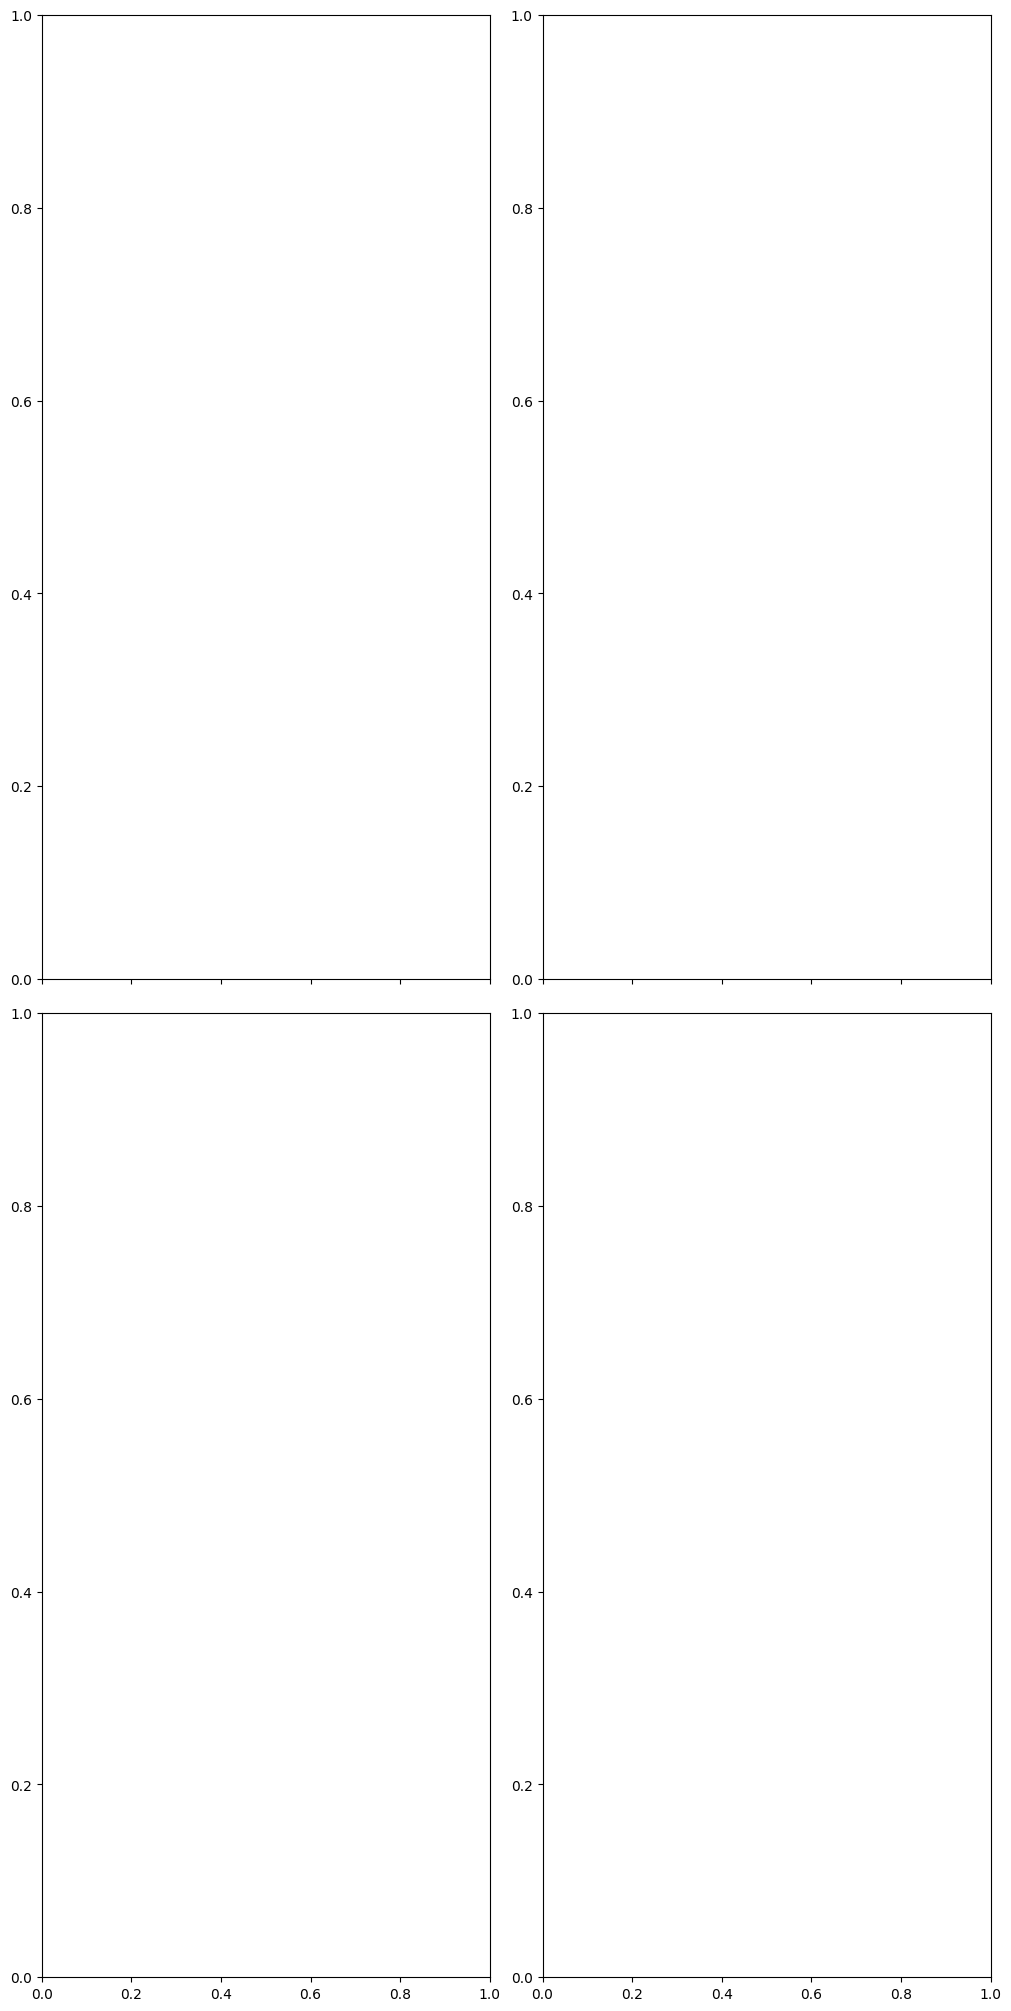

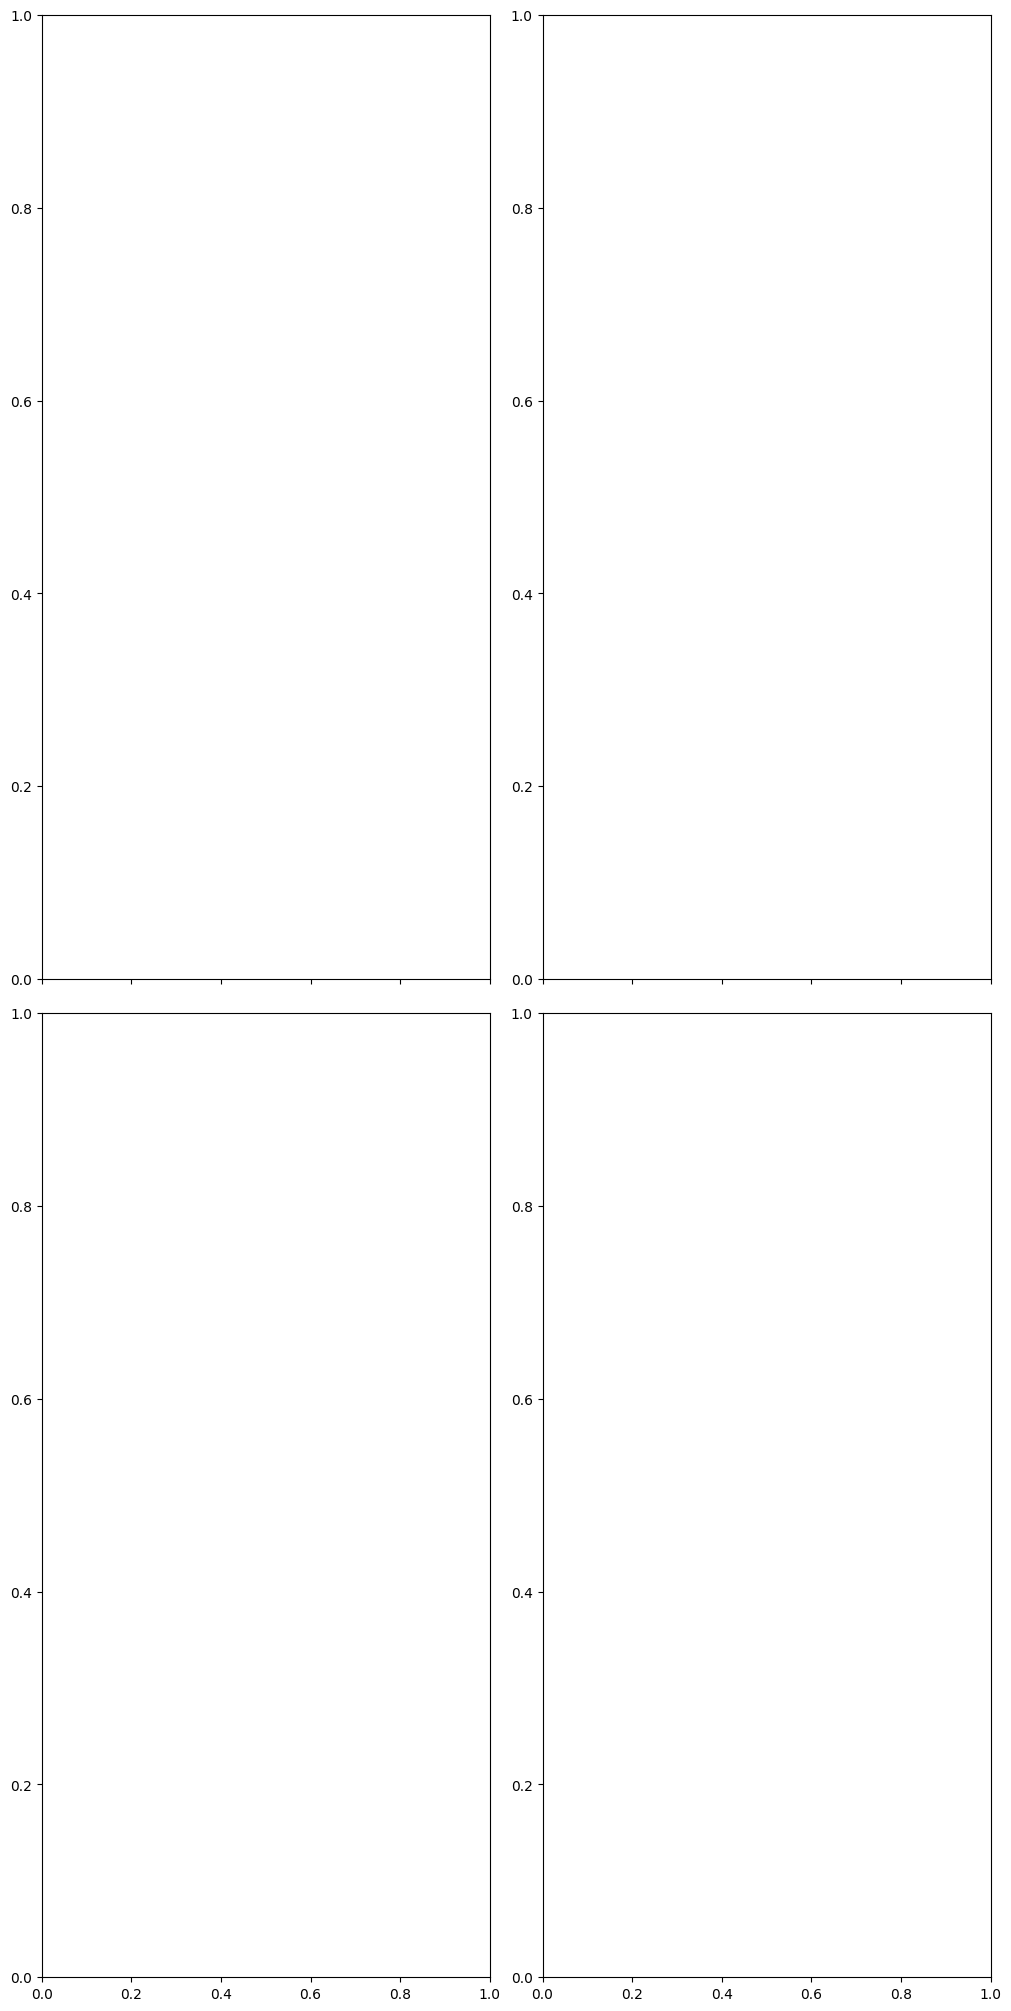

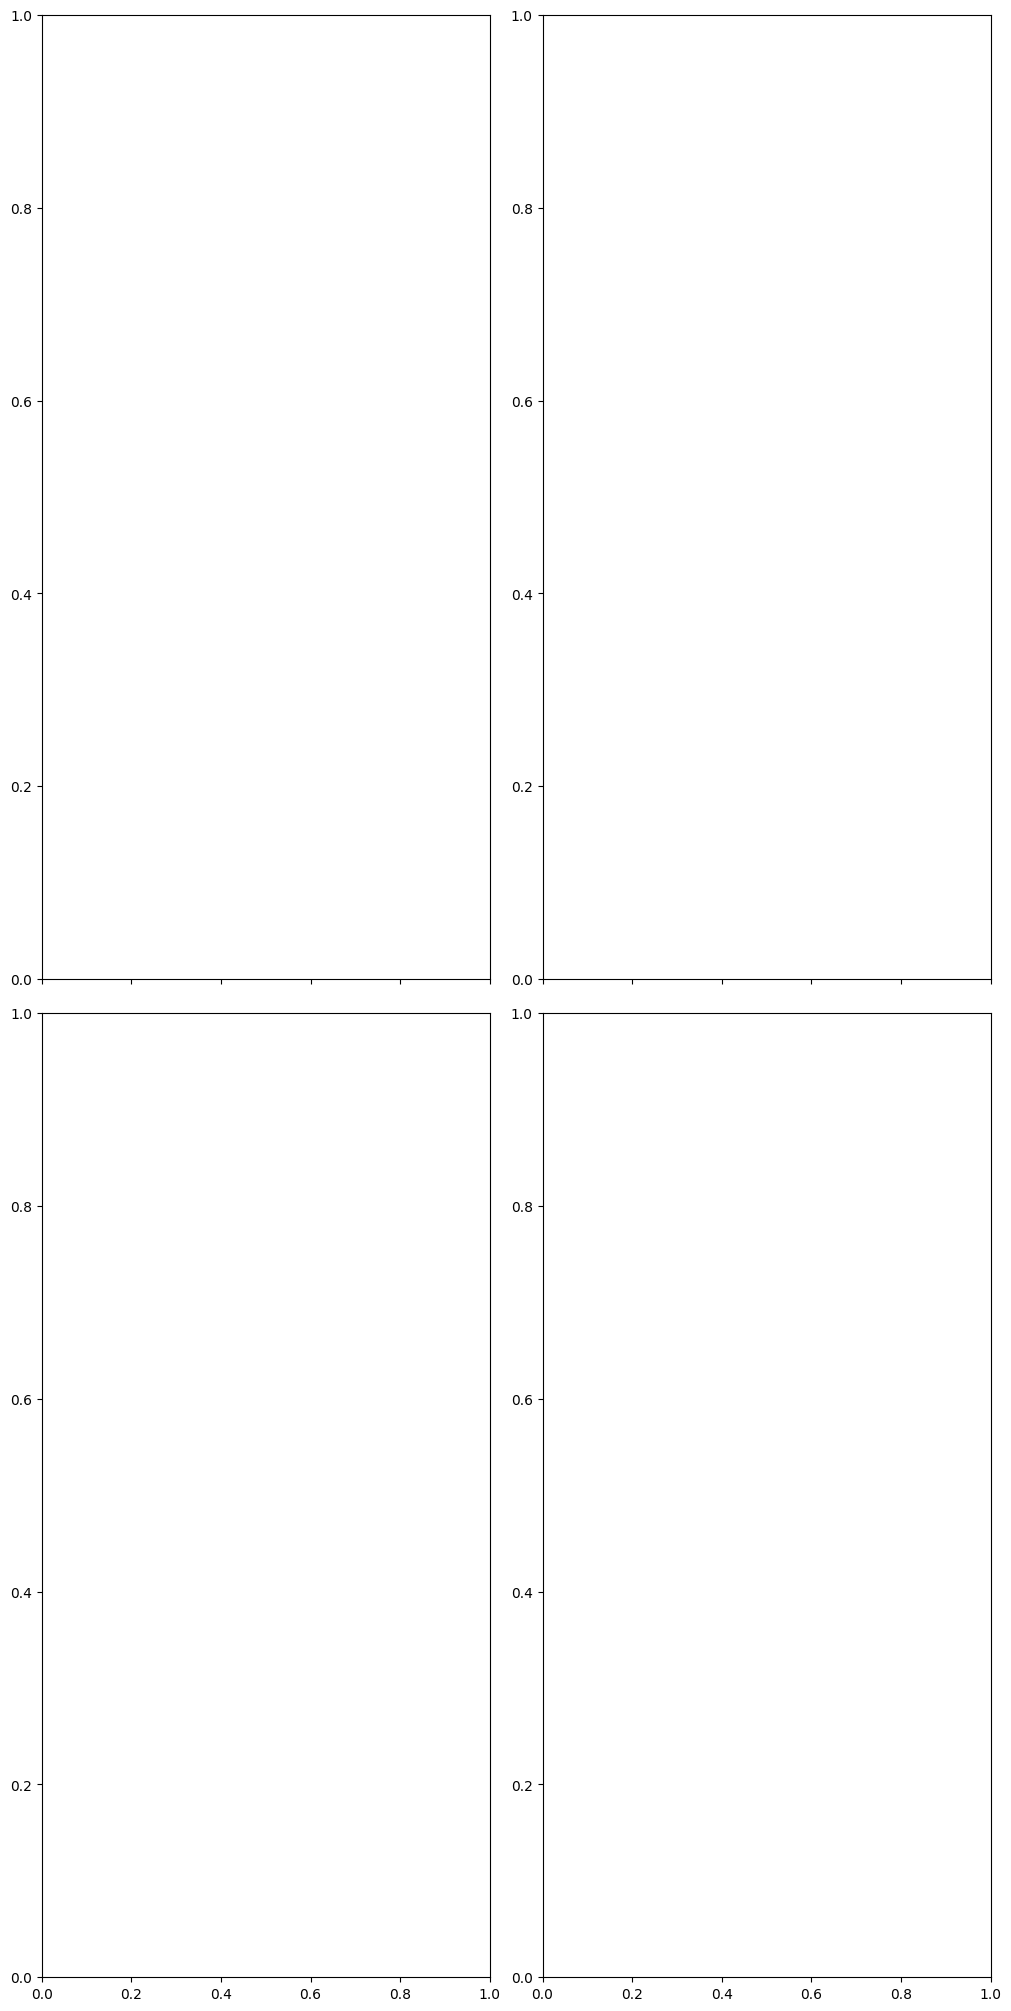

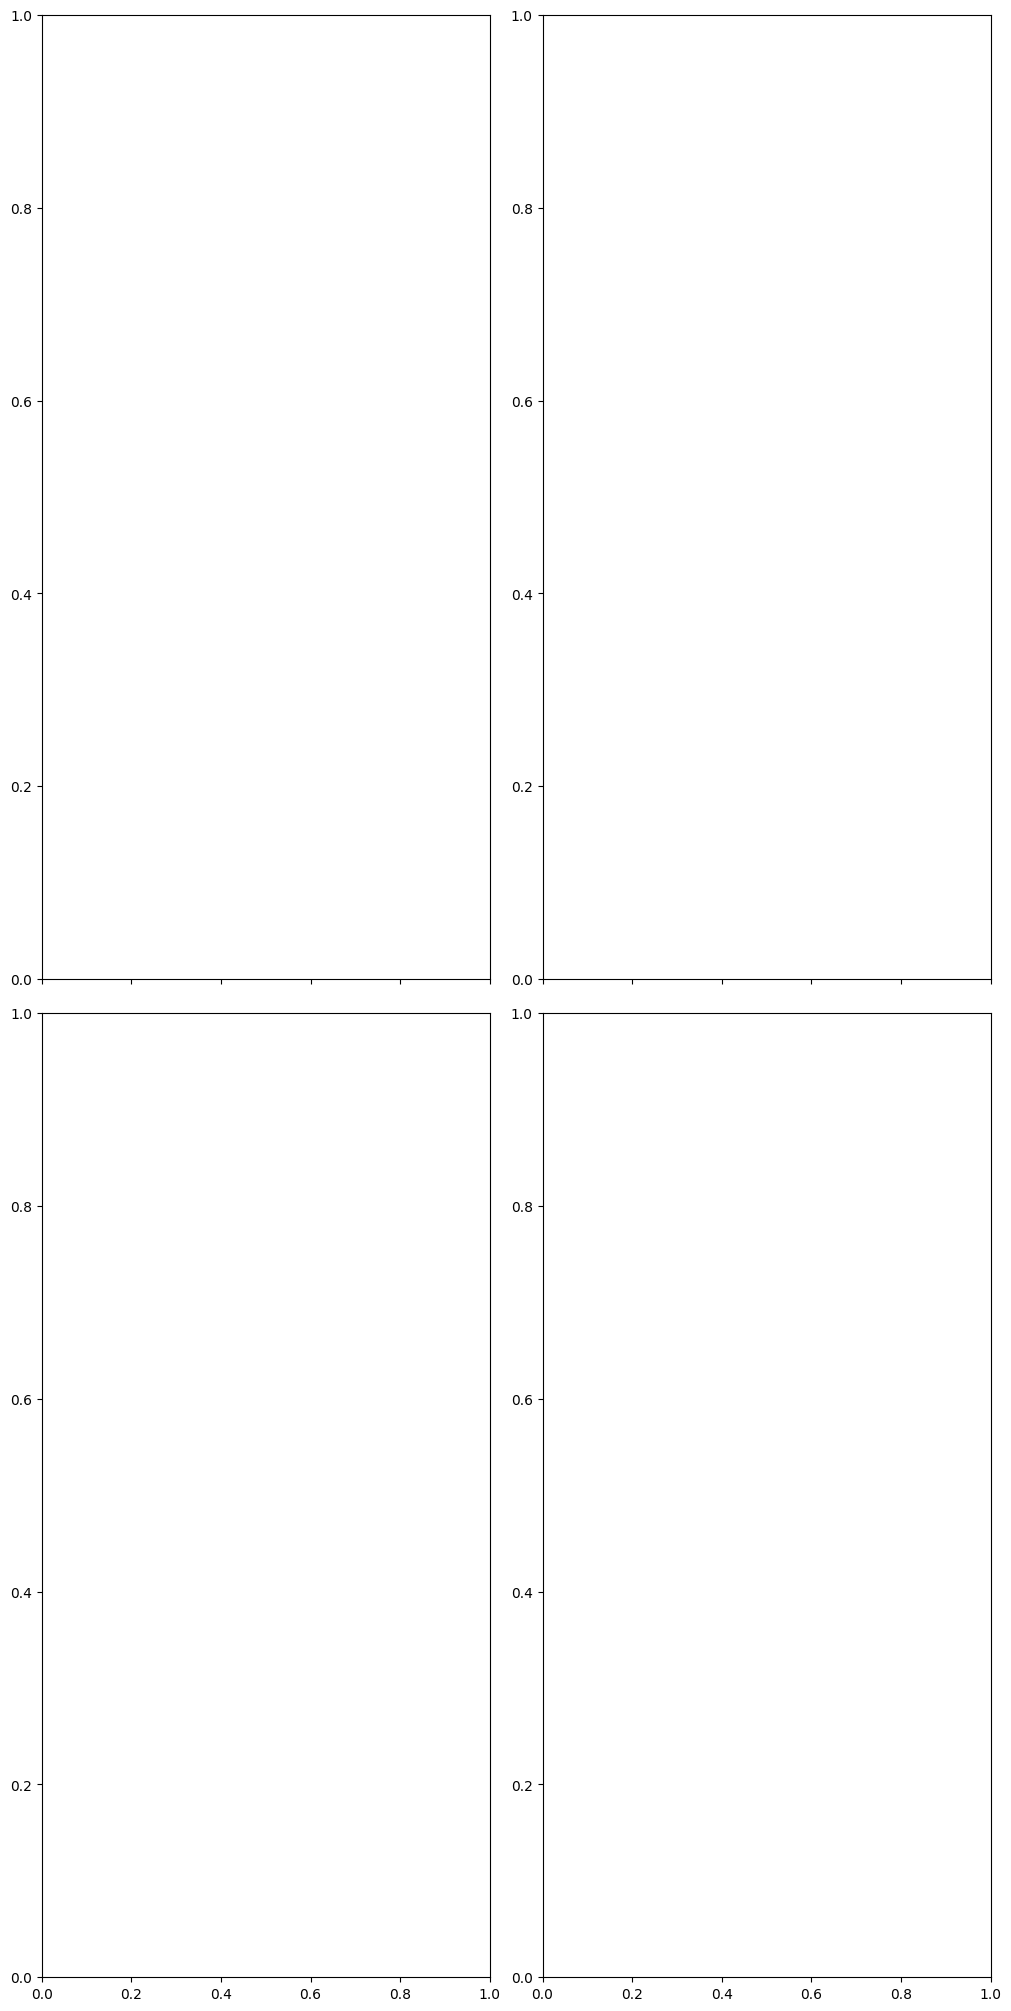

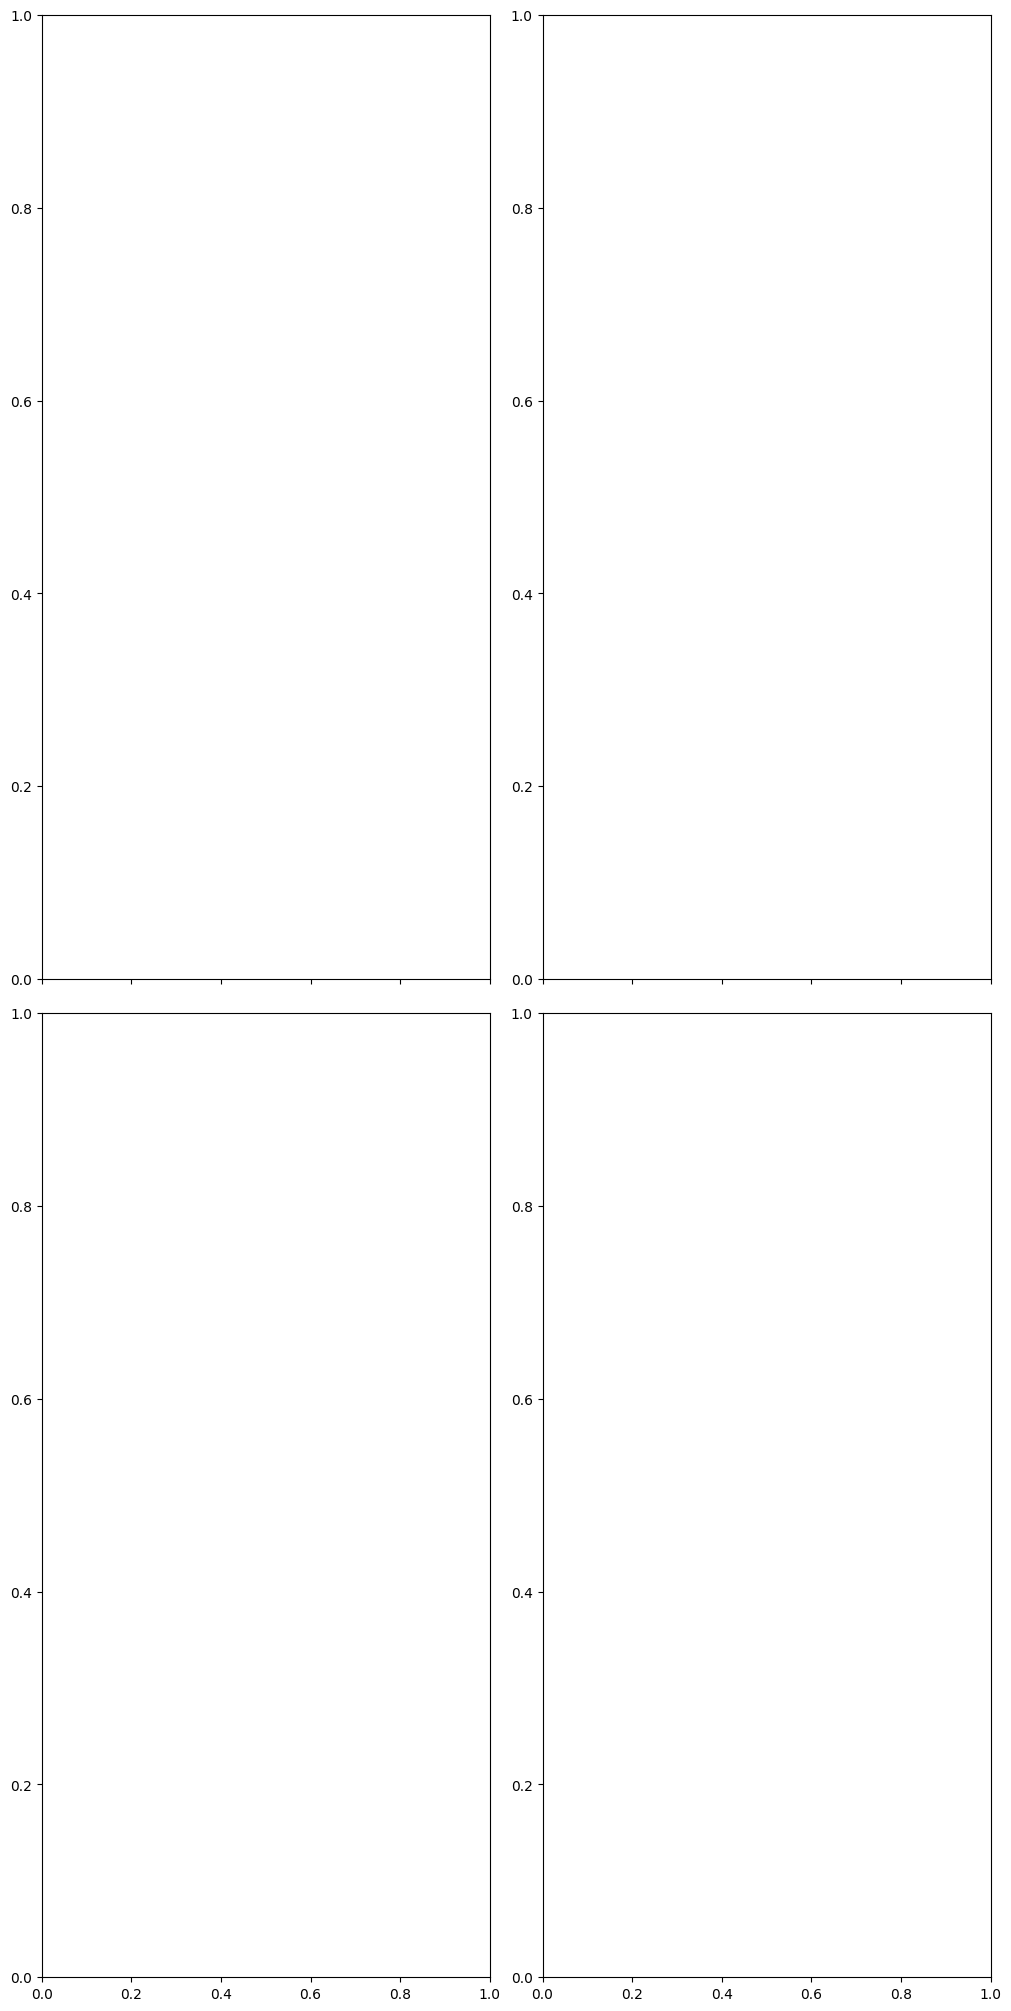

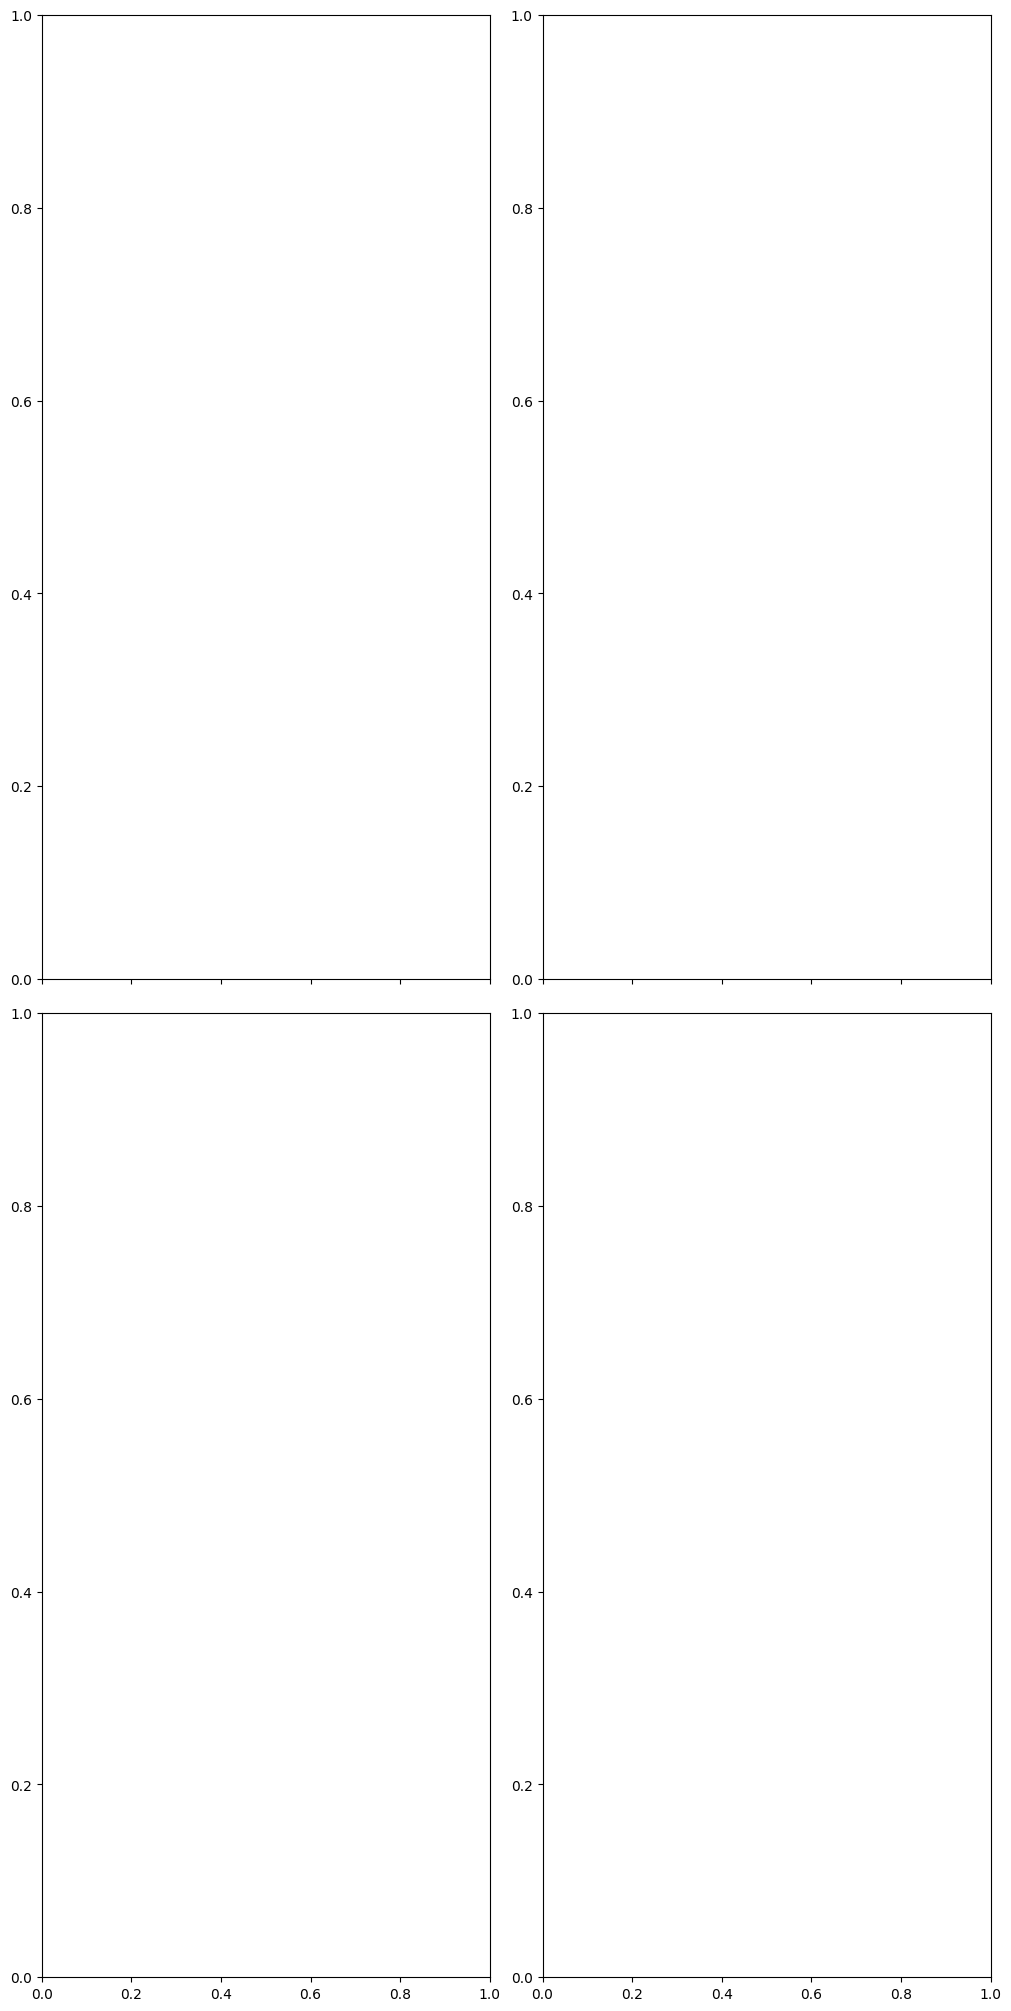

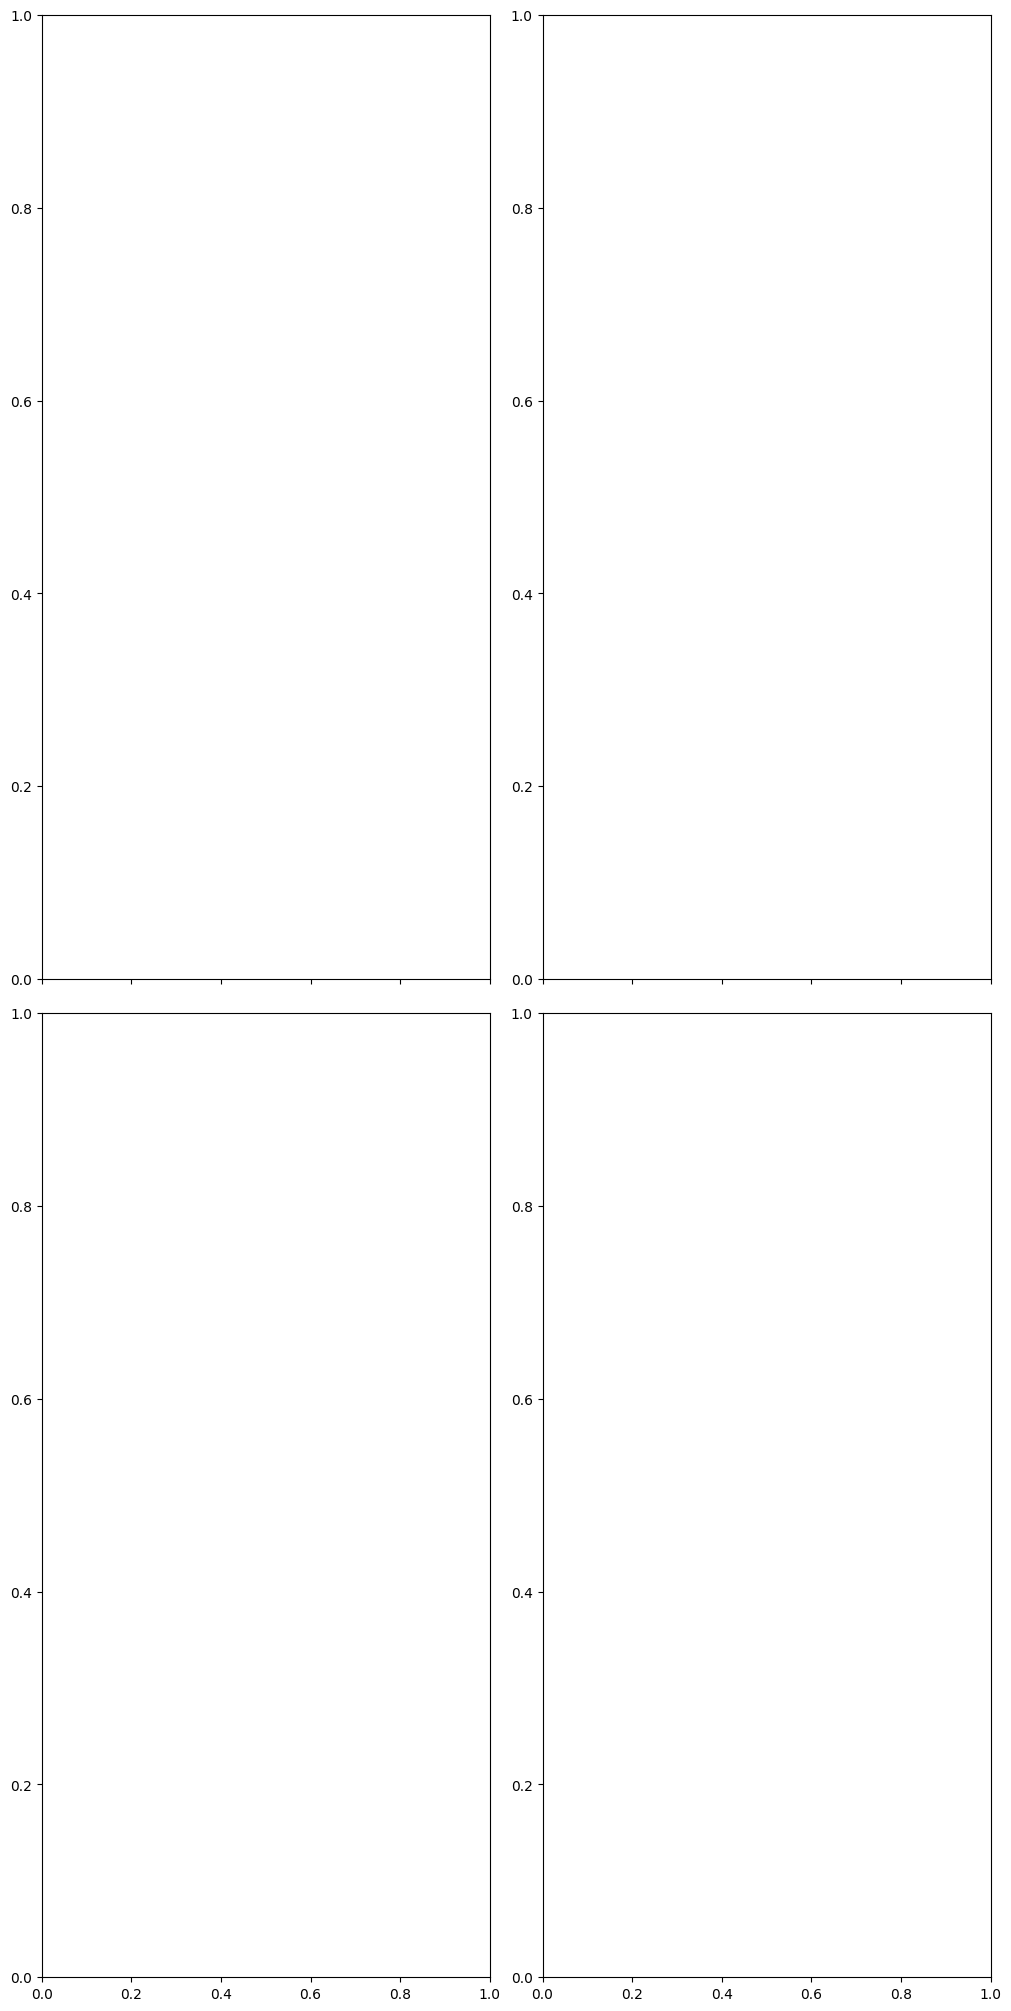

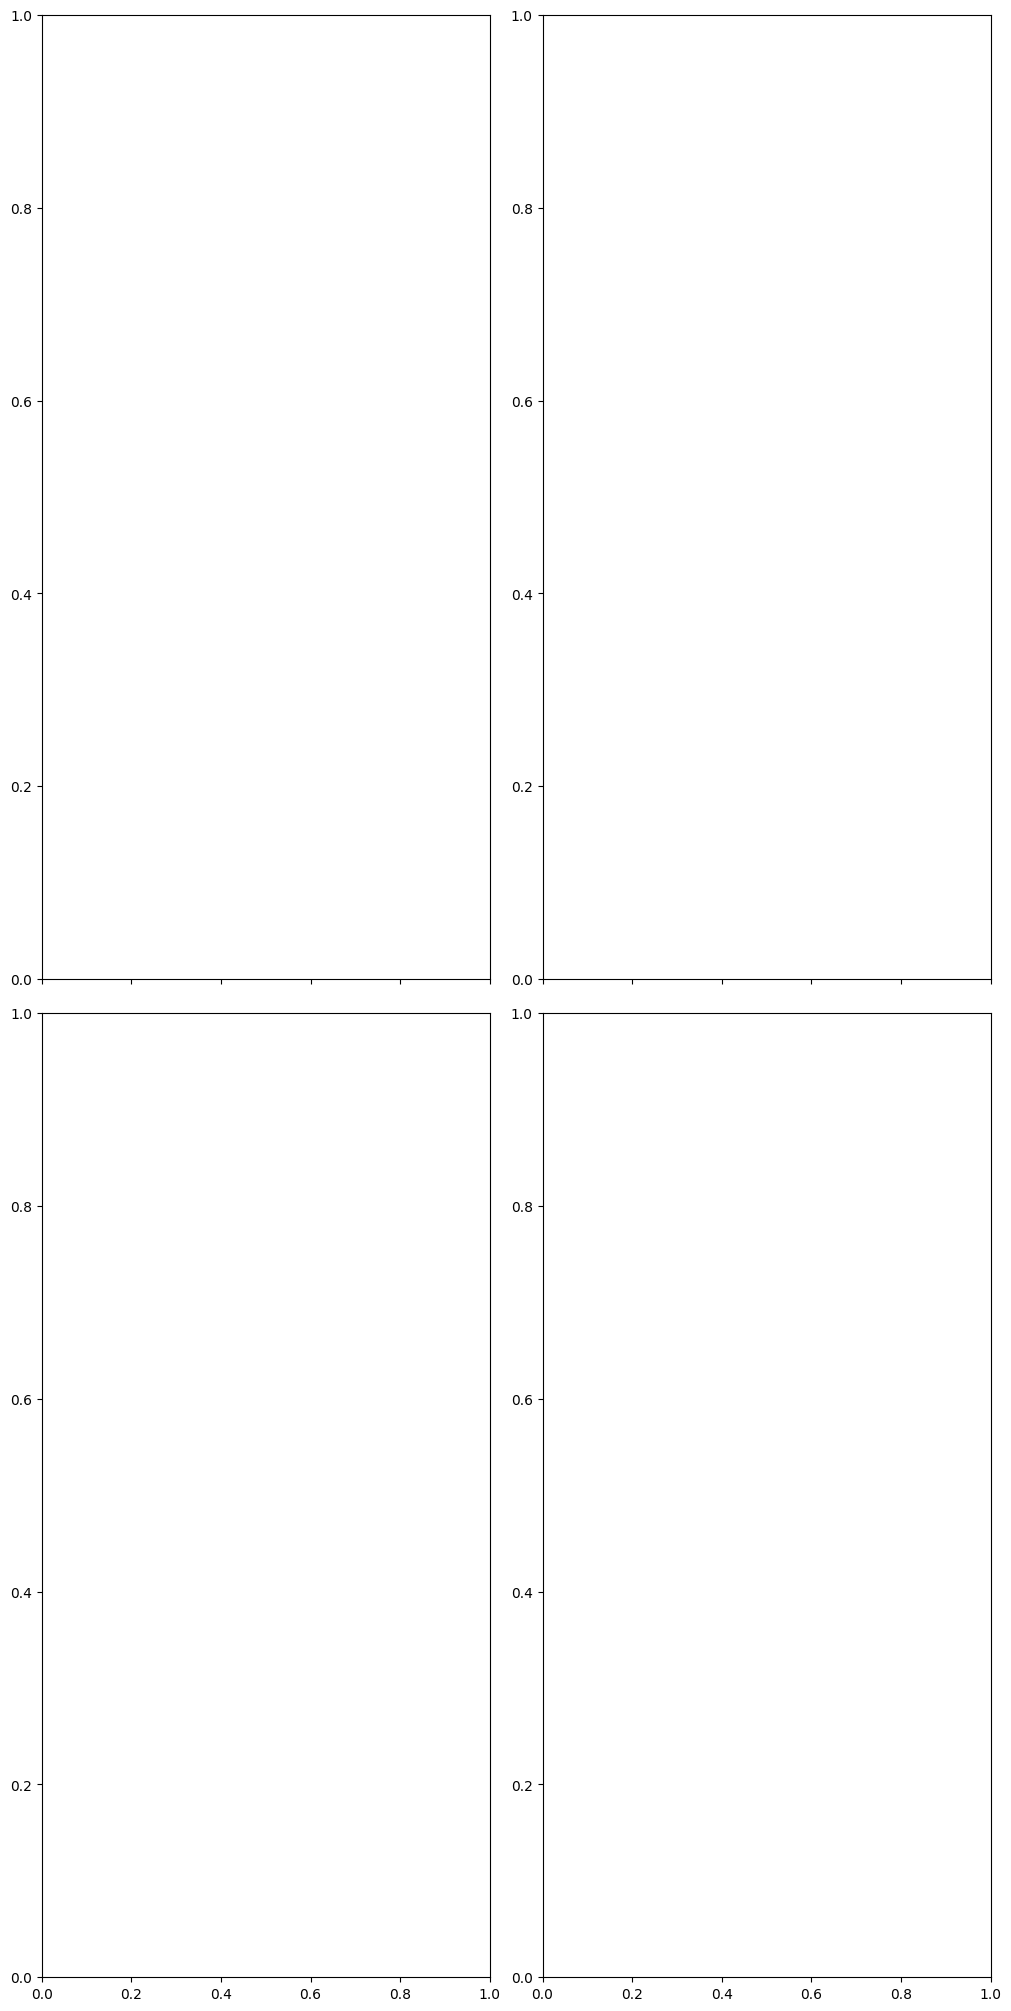

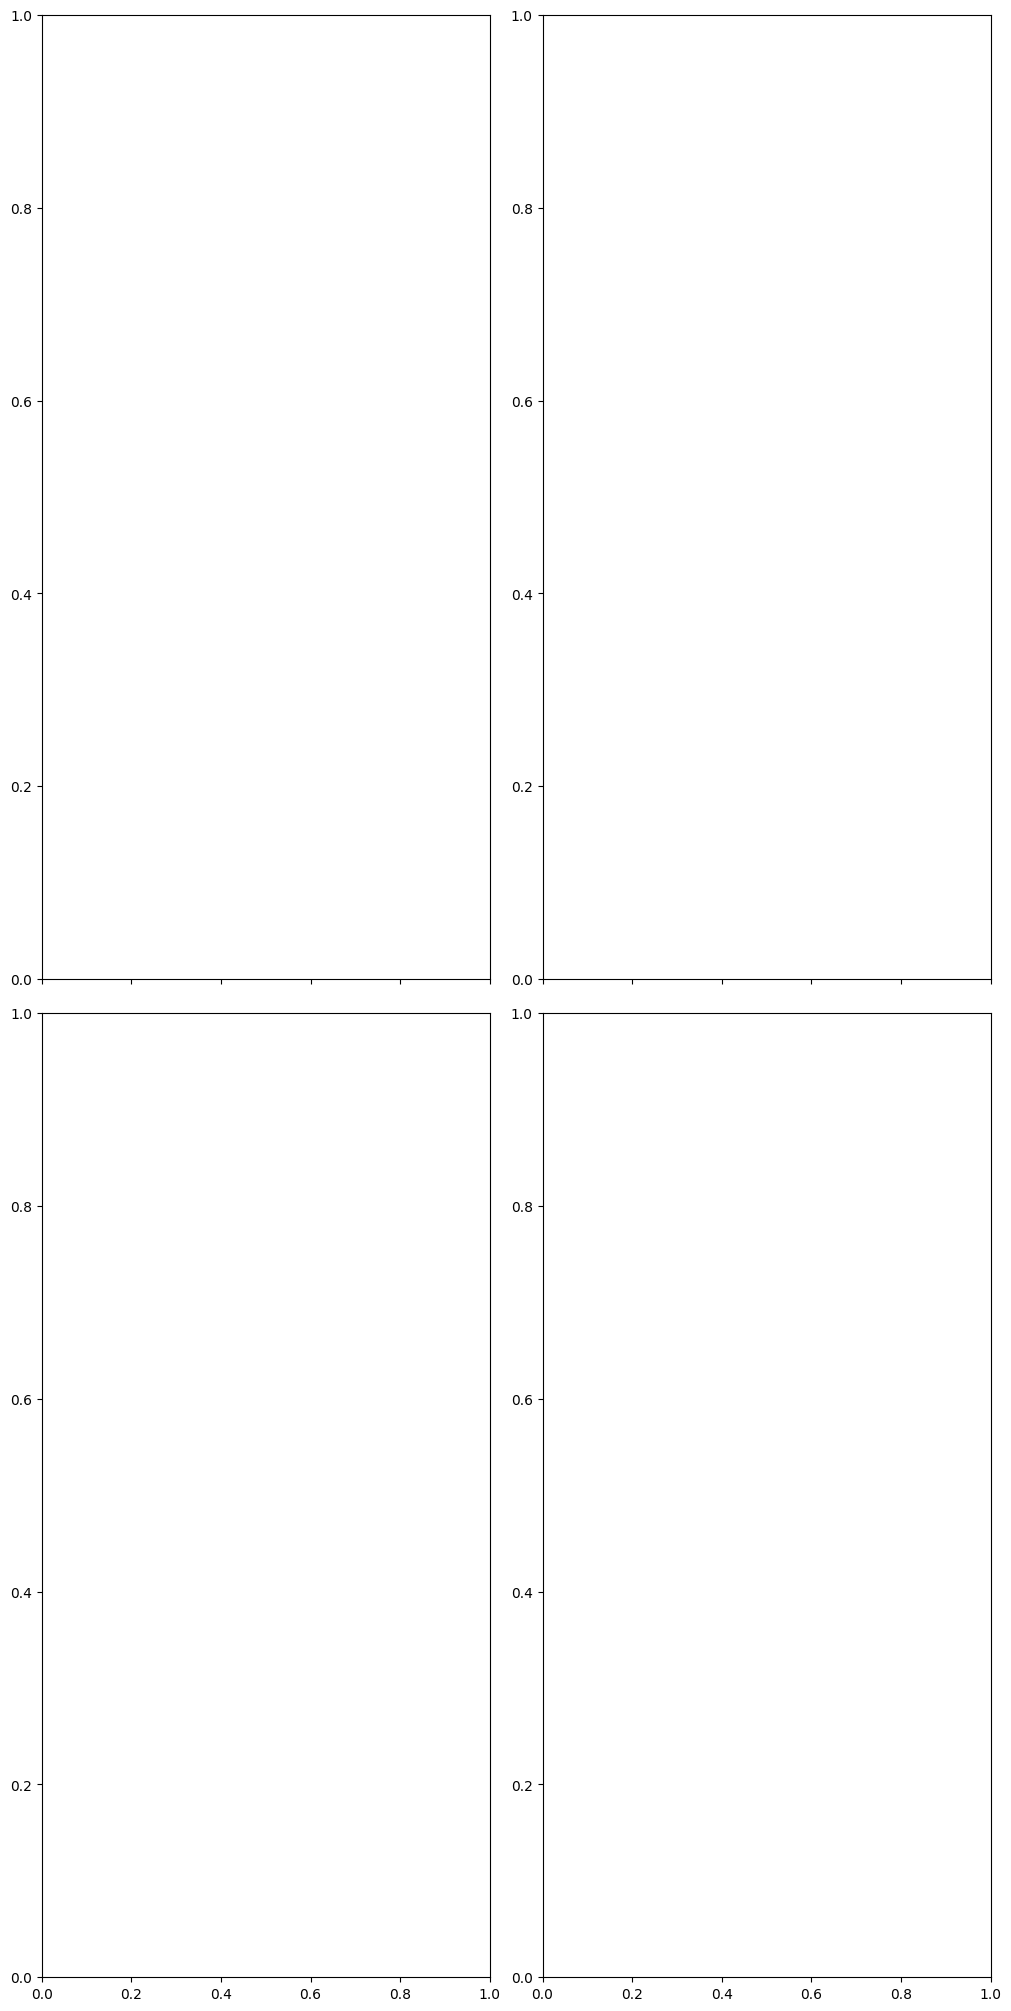

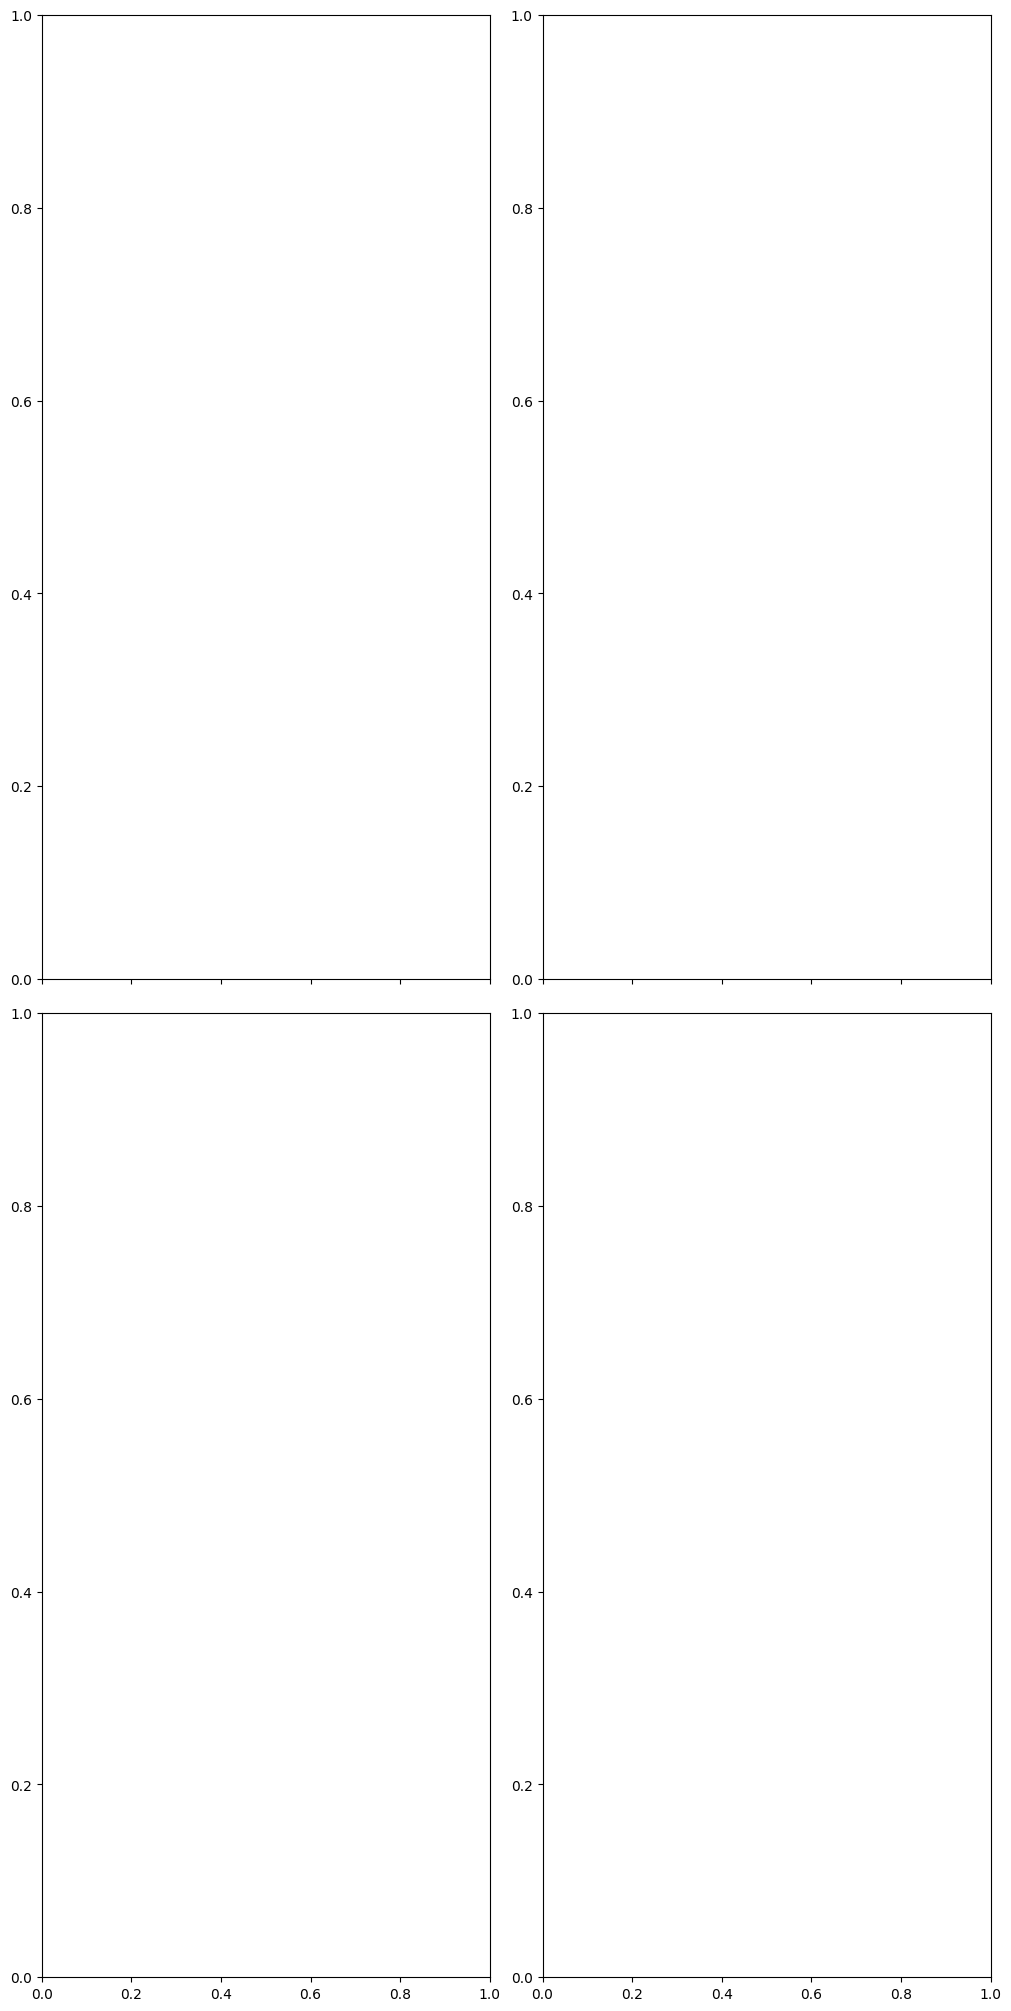

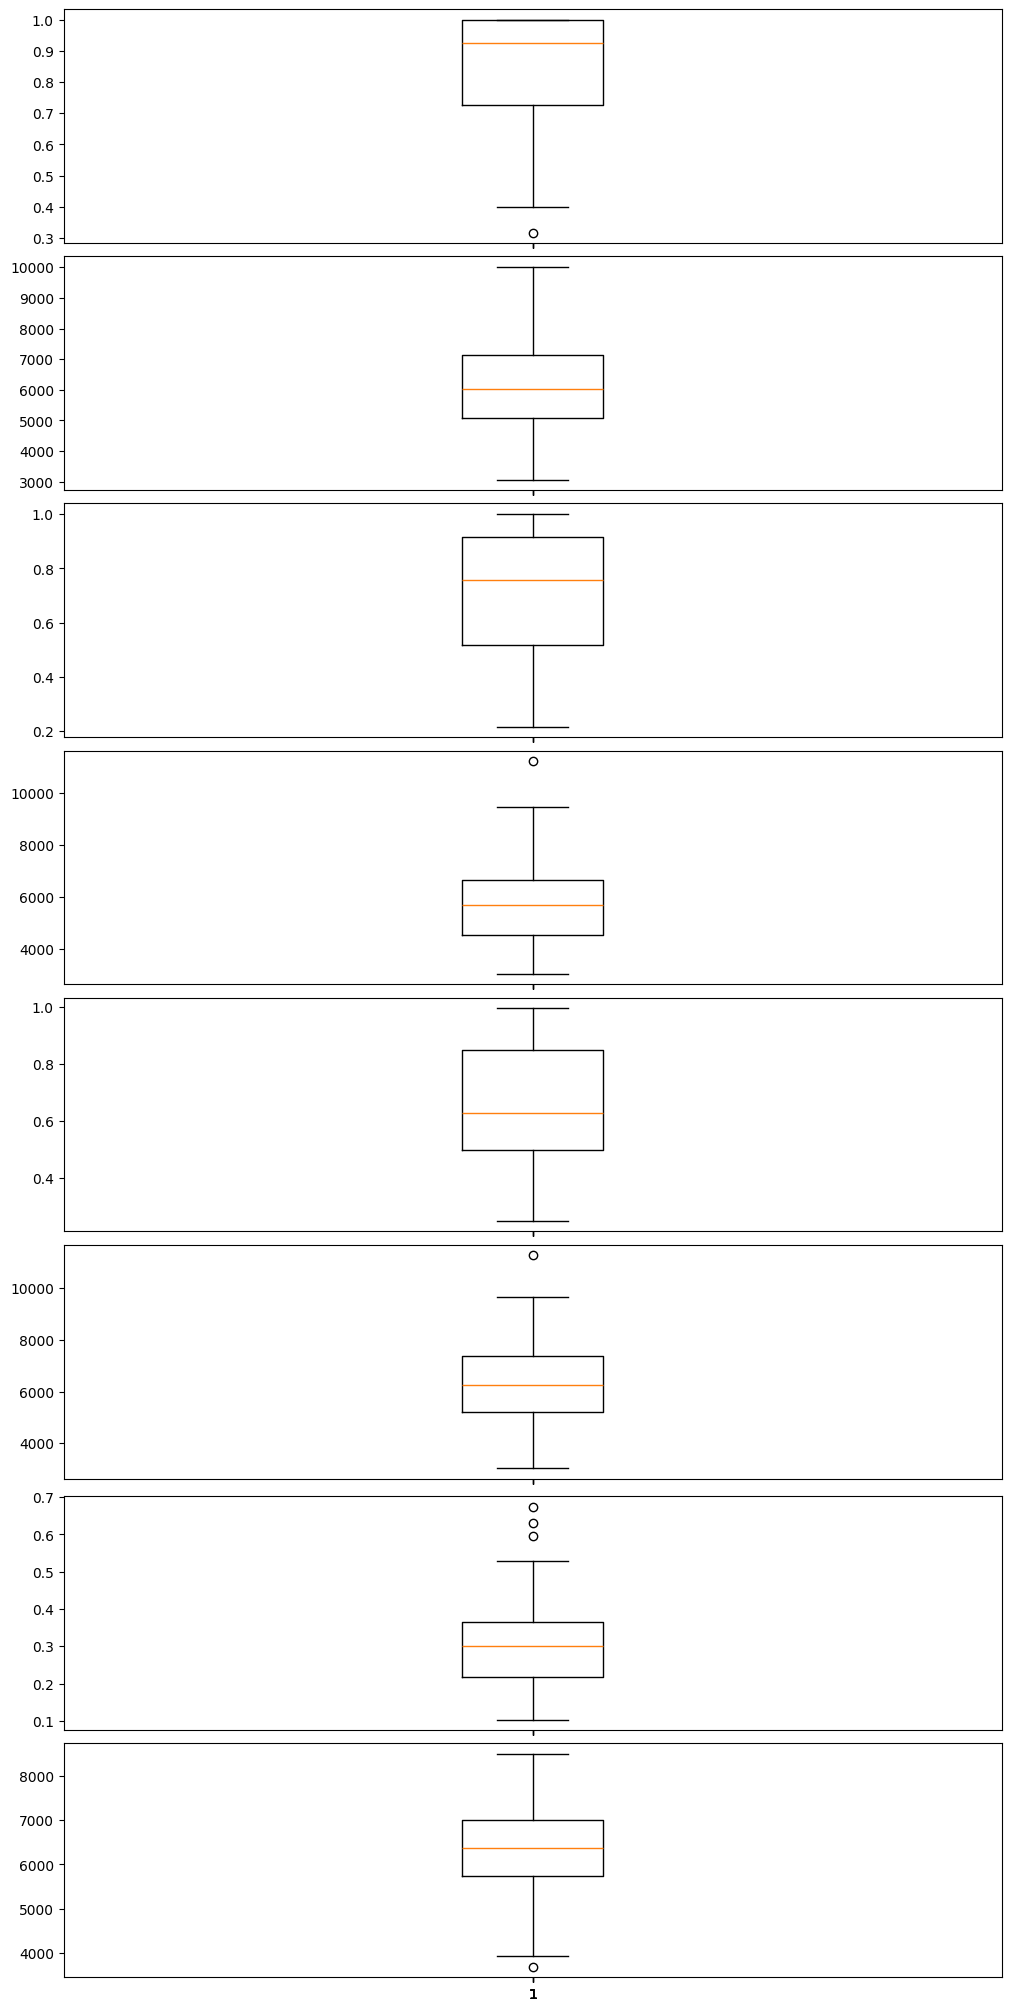

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
dirichlet_parameter_list=[(0.03, 3000),(0.05, 3000),(0.1,3000), (1.0, 10)]


exclusivities = np.zeros((len(seeds),len(dirichlet_parameter_list),10))
subset_sizes = np.zeros((len(seeds),len(dirichlet_parameter_list),10))

proportions= np.zeros((len(seeds), len(dirichlet_parameter_list),10,10))

fig, axes = plt.subplots(2*len(dirichlet_parameter_list), 1, figsize=(10,20), sharex=True, constrained_layout=True)

for i_seed, seed in enumerate(seeds):
    data_splits = data_splits_multiple_seeds[i_seed]
    dist_names = list(data_splits.keys())
    n_dists = len(dist_names)
    
    for i_dist, (ax, dist_name) in enumerate(zip(np.array(axes).reshape(n_dists // 2,2).flatten(order='F'), dist_names)):
        subsets = data_splits[dist_name]
        num_workers = len(subsets)

        # Calcul des proportions par worker
        proportion = []
        for subset in subsets:
            targets = np.array([subset.dataset.targets[idx] for idx in subset.indices])
            counts = Counter(targets)
            total = len(targets)
            prop = [counts.get(c, 0) for c in range(10)]
            proportion.append(prop)
        proportion = np.array(proportion)
        proportions[i_seed,i_dist] = proportion
        
        exclusivity=[]
        for i_subset, subset in enumerate(proportion):
            majority_class= np.argmax(proportion[i_subset]) #nb_honest is the index of the byzantine worker
            exclusivity.append(proportion[i_subset][majority_class]/proportion[:,majority_class].sum())
        
        exclusivities[i_seed,i_dist] = exclusivity

        subset_size=[]
        for i_subset, subset in enumerate(proportion):
            subset_size.append(int(np.sum(proportion[i_subset]))) #nb_honest is the index of the byzantine worker
        
        subset_sizes[i_seed,i_dist] = subset_size



for i_dist, dist_name in enumerate(dirichlet_parameter_list):
    axes[2*i_dist].boxplot(exclusivities[:,i_dist,9])
    axes[2*i_dist+1].boxplot(subset_sizes[:,i_dist,9])


        

        

### On peut maintenant plot les distributions par classe par worker:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

def plot_worker_distributions_compact(data_splits, num_classes=10):
    """
    data_splits: dict
        Clés = noms des distributions (ex: 'Dirichlet α=0.1')
        Valeurs = liste de Subset (un Subset par worker)
    """
    dist_names = list(data_splits.keys())
    n_dists = len(dist_names)
    colors = plt.cm.tab10.colors  

    fig, axes = plt.subplots(n_dists // 2, 2, figsize=(10,20), sharex=True, constrained_layout=True)
    if n_dists == 1:
        axes = [axes]  # pour itérer même s’il y a un seul plot

    for ax, dist_name in zip(np.array(axes).reshape(n_dists // 2,2).flatten(order='F'), dist_names):
        subsets = data_splits[dist_name]
        num_workers = len(subsets)

        # Calcul des proportions par worker
        proportions = []
        for subset in subsets:
            targets = np.array([subset.dataset.targets[idx] for idx in subset.indices])
            counts = Counter(targets)
            total = len(targets)
            prop = [counts.get(c, 0) for c in range(num_classes)]
            proportions.append(prop)
        proportions = np.array(proportions)

        # Plot horizontal empilé
        left = np.zeros(num_workers)
        for c in range(num_classes):
            ax.barh(range(num_workers), proportions[:, c], left=left,
                    color=colors[c], label=f'Classe {c}' if ax == axes[0][0] else None)
            left += proportions[:, c]

        ax.set_yticks(range(num_workers))
        ax.set_yticklabels([f'{i+1}' for i in range(num_workers)])
        ax.set_title(dist_name, fontsize=14, weight='bold')
        ax.invert_yaxis()  # pour que W0 soit en haut

    for i in range((n_dists) // 2):
        axes[i][0].set_ylabel('Workers')
    axes[-1][0].set_xlabel('Number by class')
    axes[-1][1].set_xlabel('Number by class')
    axes[0][0].legend(title='Classes', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.suptitle("Distribution by class per worker (min size = 3000)", fontsize=16, weight='bold')
    plt.savefig("worker_distributions_compact_number.png", dpi=300)
    plt.show()
    
plot_worker_distributions_compact(data_splits)

